# Experiments 46 - 47
### Excess Green: _exGreen / PCA + exGreen_


### Dataset:
- **Dataset:** 3.5m | 90º
    1. exGreen _(gray images)_
    2. 2 PCA + exGreen _(false color images)_
- **Sizes:** small & mid
- **Split:** 640 px
- **Tags:**  `plant-weed`
- **Train/Valid dist:** 66,6% / 33,3%

### Model:
- **Model:** `yolov8m` *(Medium)*
- **Epochs:** ~500
- **Batch:** 64
- **Freeze:** 10

### Experiments:
1. exGreen
2. 2 PCA + exGreen
- **Reference:** 
    1. exGreen masked
    1. 2 PCA + exGreen + BurnBlend

In [1]:
# CONFIG FOLDER PATH

# Get the project root directory (replace with your actual path)
experiment_number = 2
project_root = "../" * 2

# The folder you want to navigate to (relative to the root)
target_folder = f"docs/Experimentos/8 exGreen/{experiment_number} set/runs/detect/"

### Init

In [2]:
scale: int = 500 # size for graphs (in pixels)

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D

In [4]:
def update_project_root(path = ''):
    global project_root
    if not path:
        path = os.getcwd()
    folder_depth = len([i for i in path.split("/") if i != ''])
    project_root = "../" * folder_depth

In [5]:
def change_directory(target_folder):
    """
    Change the current working directory to the target folder.
    Args:
        target_folder (str): The target folder path relative to the project root.
    """ 
    global project_root
    # Construct the full path
    target_path = os.path.join(project_root, target_folder)

    # Change the current working directory
    try:
        os.chdir(target_path)
        print(f"Current working directory: {os.getcwd()}")  # Verify

        folder_depth = len([i for i in target_folder.split("/") if i != ''])
        project_root = "../" * folder_depth
        print(f"Project root updated to: {project_root}")  # Verify

    except FileNotFoundError:
        print(f"Error: Folder '{target_path}' not found. Check the path.")
    except NotADirectoryError:
        print(f"Error: '{target_path}' is not a directory.")
    except Exception as e:
        print(f"An error occurred: {e}")

In [6]:
change_directory(target_folder)

Current working directory: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Trabajo Final/Desarrollo/docs/Experimentos/8 exGreen/2 set/runs/detect
Project root updated to: ../../../../../../


In [7]:
# Reset to the root path
# os.chdir(project_root)
# print(f"Current working directory: {os.getcwd()}") #Verify

In [8]:
best_models = pd.DataFrame(
    columns=['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2', 'train_time'],
       data = None
       )

#### Functions

In [1]:
def show_cm(TP, FP, FN):
    matrix = [[TP, FP], [FN, 0]]
    total_det = sum(sum(value) for value in matrix)
    percentages = []
    for row in matrix:
        values_percentages = []
        for value in row:
            if total_det != 0:
                percentage = (value / total_det) * 100
            else:
                percentage = 0.0
            values_percentages.append(f"{percentage:.2f}%")
        percentages.append(values_percentages)
    
    print("Total objects detected:", total_det)
    print("\nConfusion matrix:")
    for row in percentages:
        a, b = row
        print(f"[ {a} , {b} ]")

In [2]:
def show_metrics(TP, FP, FN):
    show_cm(TP, FP, FN)
    accuracy = TP/(TP+FP+FN)
    precision = TP/(TP+FP)
    recall = TP/(TP+FN)
    f1 = 2 * (precision * recall) / (precision + recall)
    f2 = 1.25 * (precision * recall) / (0.25 * precision + recall)
    fm = (precision * recall) ** 0.5
    print("\nMetrics:")
    print(f"- Accuracy: {accuracy:.3f}")
    print(f"- Precision: {precision:.3f}")
    print(f"- Recall: {recall:.3f}")
    print(f"- F1 Score: {f1:.3f}")
    print(f"- F½ Score: {f2:.3f}")
    print(f"- G-mean: {fm:.3f}")

In [9]:
def graph_training_metrics(df: pd.DataFrame, epoch: np.int64, graph: str="tight"):
    """
    Plots training and validation metrics from a training log DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing training metrics, including columns
                           'epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
                           'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
                           'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
                           'metrics/mAP50-95(B)', and optionally 'lr/pg0' for the 'lr' graph.
        graph (str, optional): Type of graph to display. Options are:
            - "tight": Displays loss and metrics in a single row.
            - "full": Displays loss and metrics in two rows.
            - "lr": Displays loss, metrics, and learning rate in three rows.
            Defaults to "tight".

    Raises:
        ValueError: If the 'graph' parameter is not one of "tight", "full", or "lr".
    """
    graph = graph.lower()

    # Tight view (one row)
    if graph == "tight":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 6))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(1, 2, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')

        # Graficar métricas de validación
        plt.subplot(1, 2, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X


    # Full view (two rows)
    elif graph == "full":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 12))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(2, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')

        # Graficar métricas de validación
        plt.subplot(2, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X

    # Shows also Lr graph (three rows)
    elif graph == "lr":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 15))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(3, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')

        # Graficar métricas de validación
        plt.subplot(3, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X

        # Gráfico de evolución del learning rate
        plt.subplot(3, 1, 3)
        plt.plot(df["epoch"], df["lr/pg0"], label="Learning Rate (pg0)", color="cadetblue", marker='.', linestyle='-')
        plt.xlabel("Epoch")
        plt.ylabel("Learning Rate")
        plt.title("Learning Rate Evolution")
        plt.grid(True)

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')

    else:
        raise ValueError(f"Invalid graph parameter: '{graph}'. Must be one of 'tight', 'full', or 'lr'.")

    plt.tight_layout()
    plt.show()

In [10]:
def graph_LrLoss(df):
    """Generates a 3D plot of Learning Rate vs. Loss vs. Epoch."""

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Data
    epochs = df['epoch']
    losses = df['val/cls_loss']  # or df['train/cls_loss'], or combined as needed.
    lrs = df['lr/pg0']

    # Scatter plot
    ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis', marker='o')

    # Labels
    ax.set_xlabel('Learning Rate (lr/pg0)')
    ax.set_ylabel('Classification Loss (val/cls_loss)')
    ax.set_zlabel('Epoch')
    ax.set_title('3D Plot: Learning Rate vs. Loss vs. Epoch')

    # Color bar
    fig.colorbar(ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis'), label='Loss Value')

    plt.show()

In [11]:
def graph_LrLoss_3D(df, set: str='val'):
    """Generates an interactive 3D plot of Learning Rate vs. Loss vs. Epoch."""

    if set.lower() == 'val':
        print("Validation set")
        loss_set = 'val/cls_loss'
        title_set = 'Validation'
    elif set.lower() == 'train':
        print("Training set")
        loss_set = 'train/cls_loss'
        title_set = 'Train'
    else:
        print("Debe indicarse el set de entrenamiento: set debe ser igual 'val' o 'train'")
        return  

    fig = go.Figure(data=[go.Scatter3d(
        x=df['lr/pg0'],
        y=df[loss_set],
        z=df['epoch'],
        mode='markers',
        marker=dict(
            size=5,
            color=df[loss_set], # color based on loss value
            colorscale='Viridis',
            opacity=0.8,
            colorbar=dict(title='Loss Value')  # Add colorbar
        )
    )])

    fig.update_layout(
        margin=dict(l=0, r=0, b=0, t=0),
        scene=dict(
            xaxis=dict(title='Learning Rate (lr/pg0)'),
            yaxis=dict(title=f'Classification Loss ({loss_set})'),
            zaxis=dict(title='Epoch'),
        ),
        title=f'Learning Rate vs. {title_set} Loss vs. Epoch'
    )

    fig.show()

----

# Experimentos

## Experiment 46
### *YOLOv8 Mid | exGreen images*
Images created by applying exGreen

In [12]:
folder = "train/"

In [13]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df1 = pd.read_csv(file_path)
df = df1.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
237,238,1639.21,1.15209,0.63462,1.01336,0.47678,0.38190,0.35041,0.09933,2.82963,1.48564,1.98647,0.001061,0.001061,0.001061
238,239,1646.72,1.11347,0.61684,1.00676,0.48116,0.38273,0.34225,0.09775,2.82388,1.47716,1.96775,0.001058,0.001058,0.001058
239,240,1653.23,1.11175,0.61808,1.01893,0.48244,0.36281,0.32363,0.09201,2.85187,1.48348,1.98703,0.001054,0.001054,0.001054
240,241,1660.21,1.12082,0.61666,0.99886,0.47420,0.36389,0.33503,0.09481,2.84240,1.43825,1.99507,0.001050,0.001050,0.001050
241,242,1666.64,1.13708,0.62153,1.00746,0.48075,0.38273,0.34871,0.09774,2.84333,1.45802,1.97648,0.001046,0.001046,0.001046


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [14]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 27.777 min


#### Best epoch

In [15]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
99,100,690.225,1.58127,0.89252,1.20808,0.4781,0.42059,0.37555,0.10552,2.67065,1.40114,1.79053,0.001608,0.001608,0.001608,27.777333


In [16]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 100 con mAP50 de 0.376


In [17]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [15]:
# Setting values from CM graph
TP = 1166
FP = 1126
FN = 1243

In [4]:
# Confusion matrix
show_metrics(TP, FP, FN)

Total objects detected: 3535

Confusion matrix:
[ 32.98% , 31.85% ]
[ 35.16% , 0.00% ]

Metrics:
- Accuracy: 0.330
- Precision: 0.509
- Recall: 0.484
- F1 Score: 0.496
- F½ Score: 0.504
- G-mean: 0.496


### Graphs

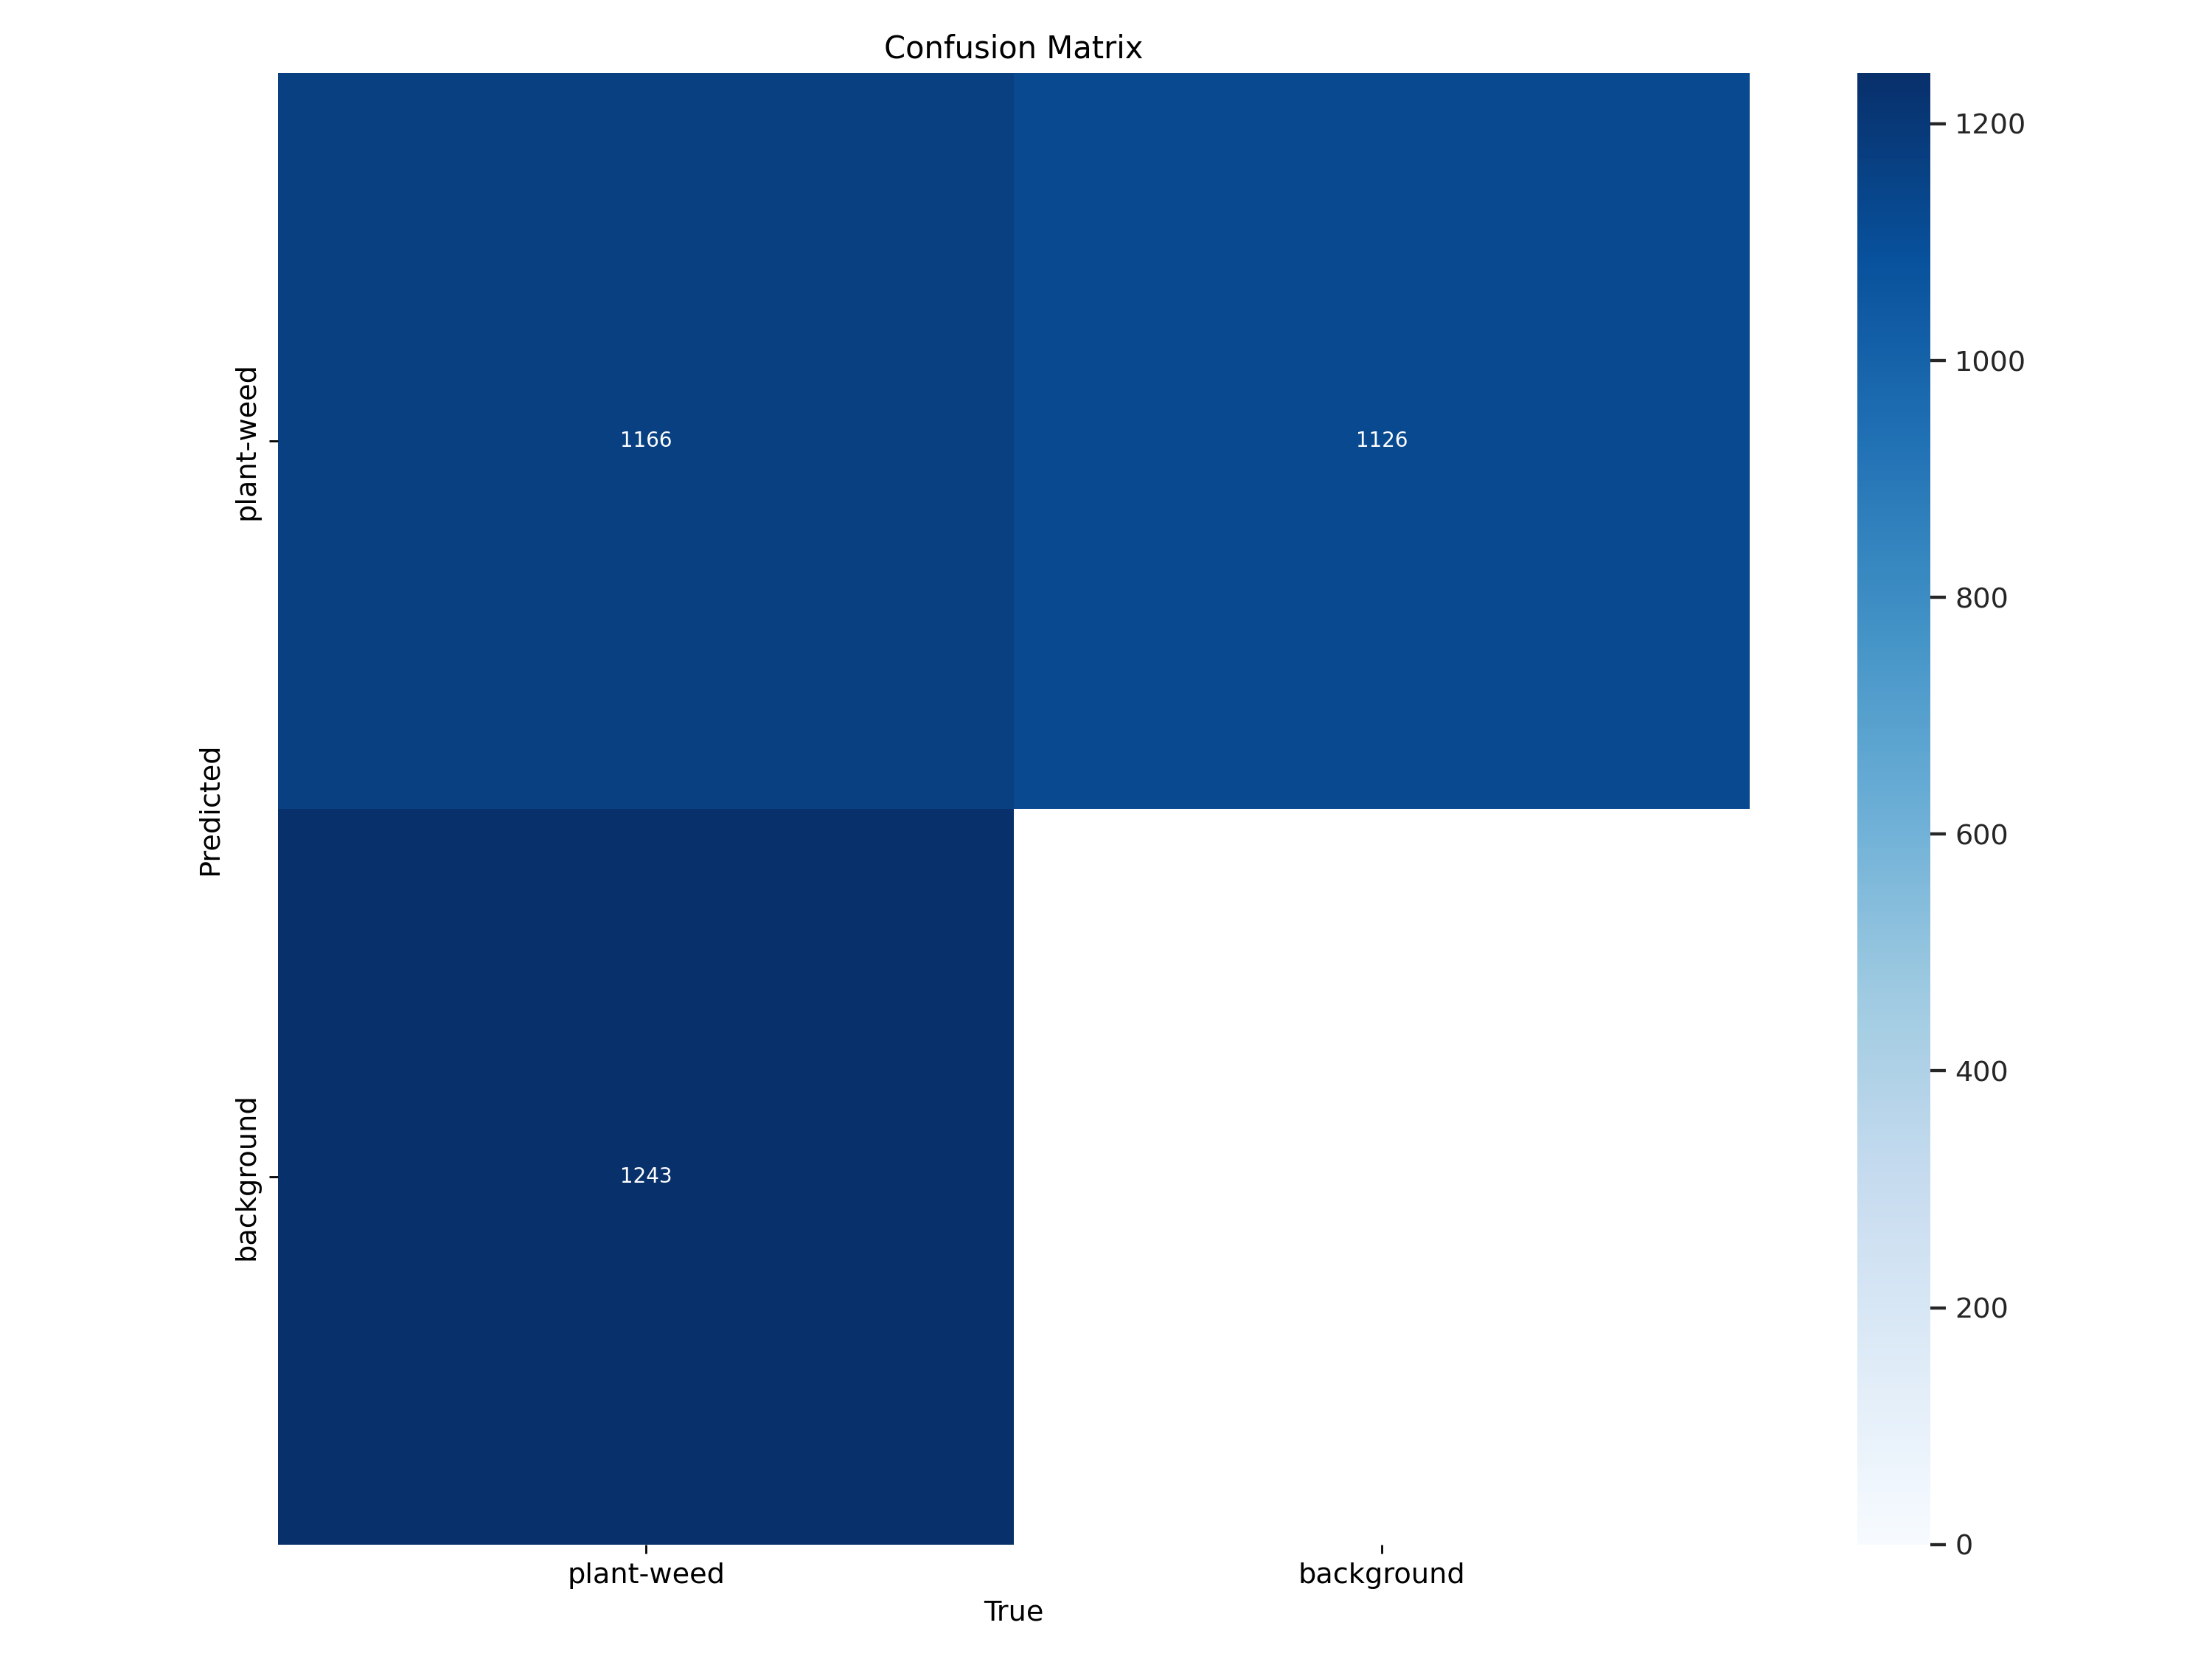

In [21]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

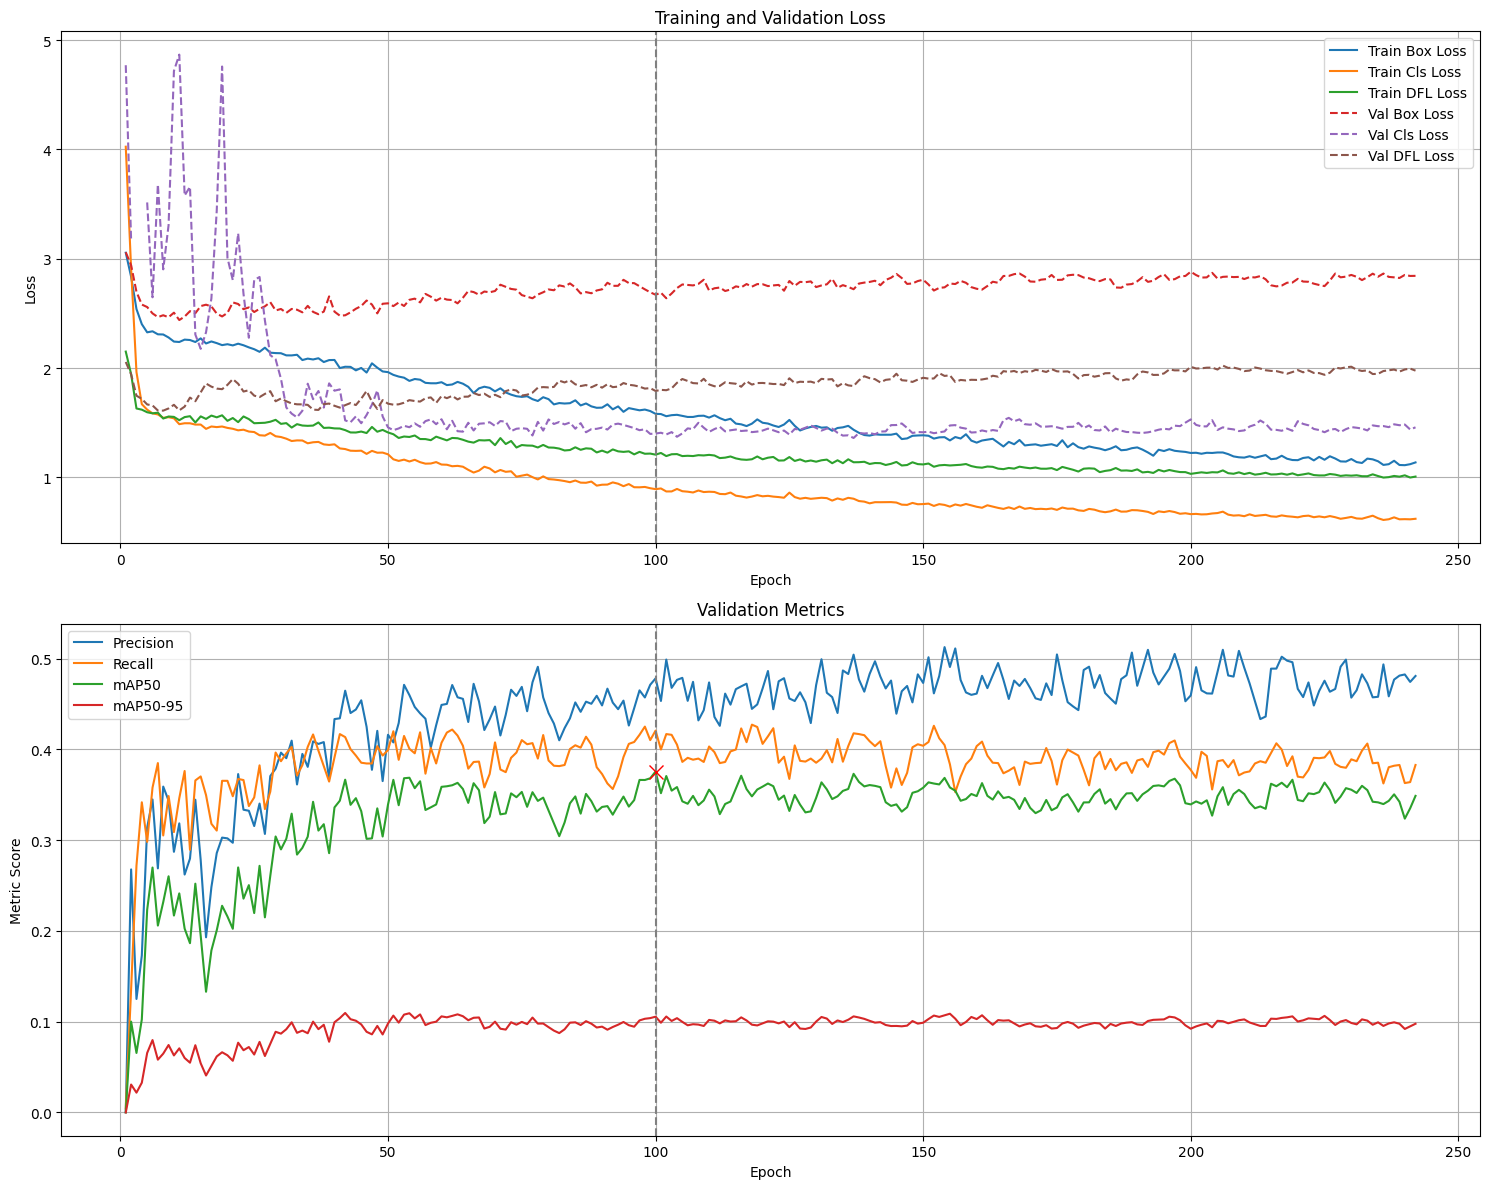

In [22]:
graph_training_metrics(df, epoch, graph="full")

In [23]:
graph_LrLoss_3D(df)

Validation set


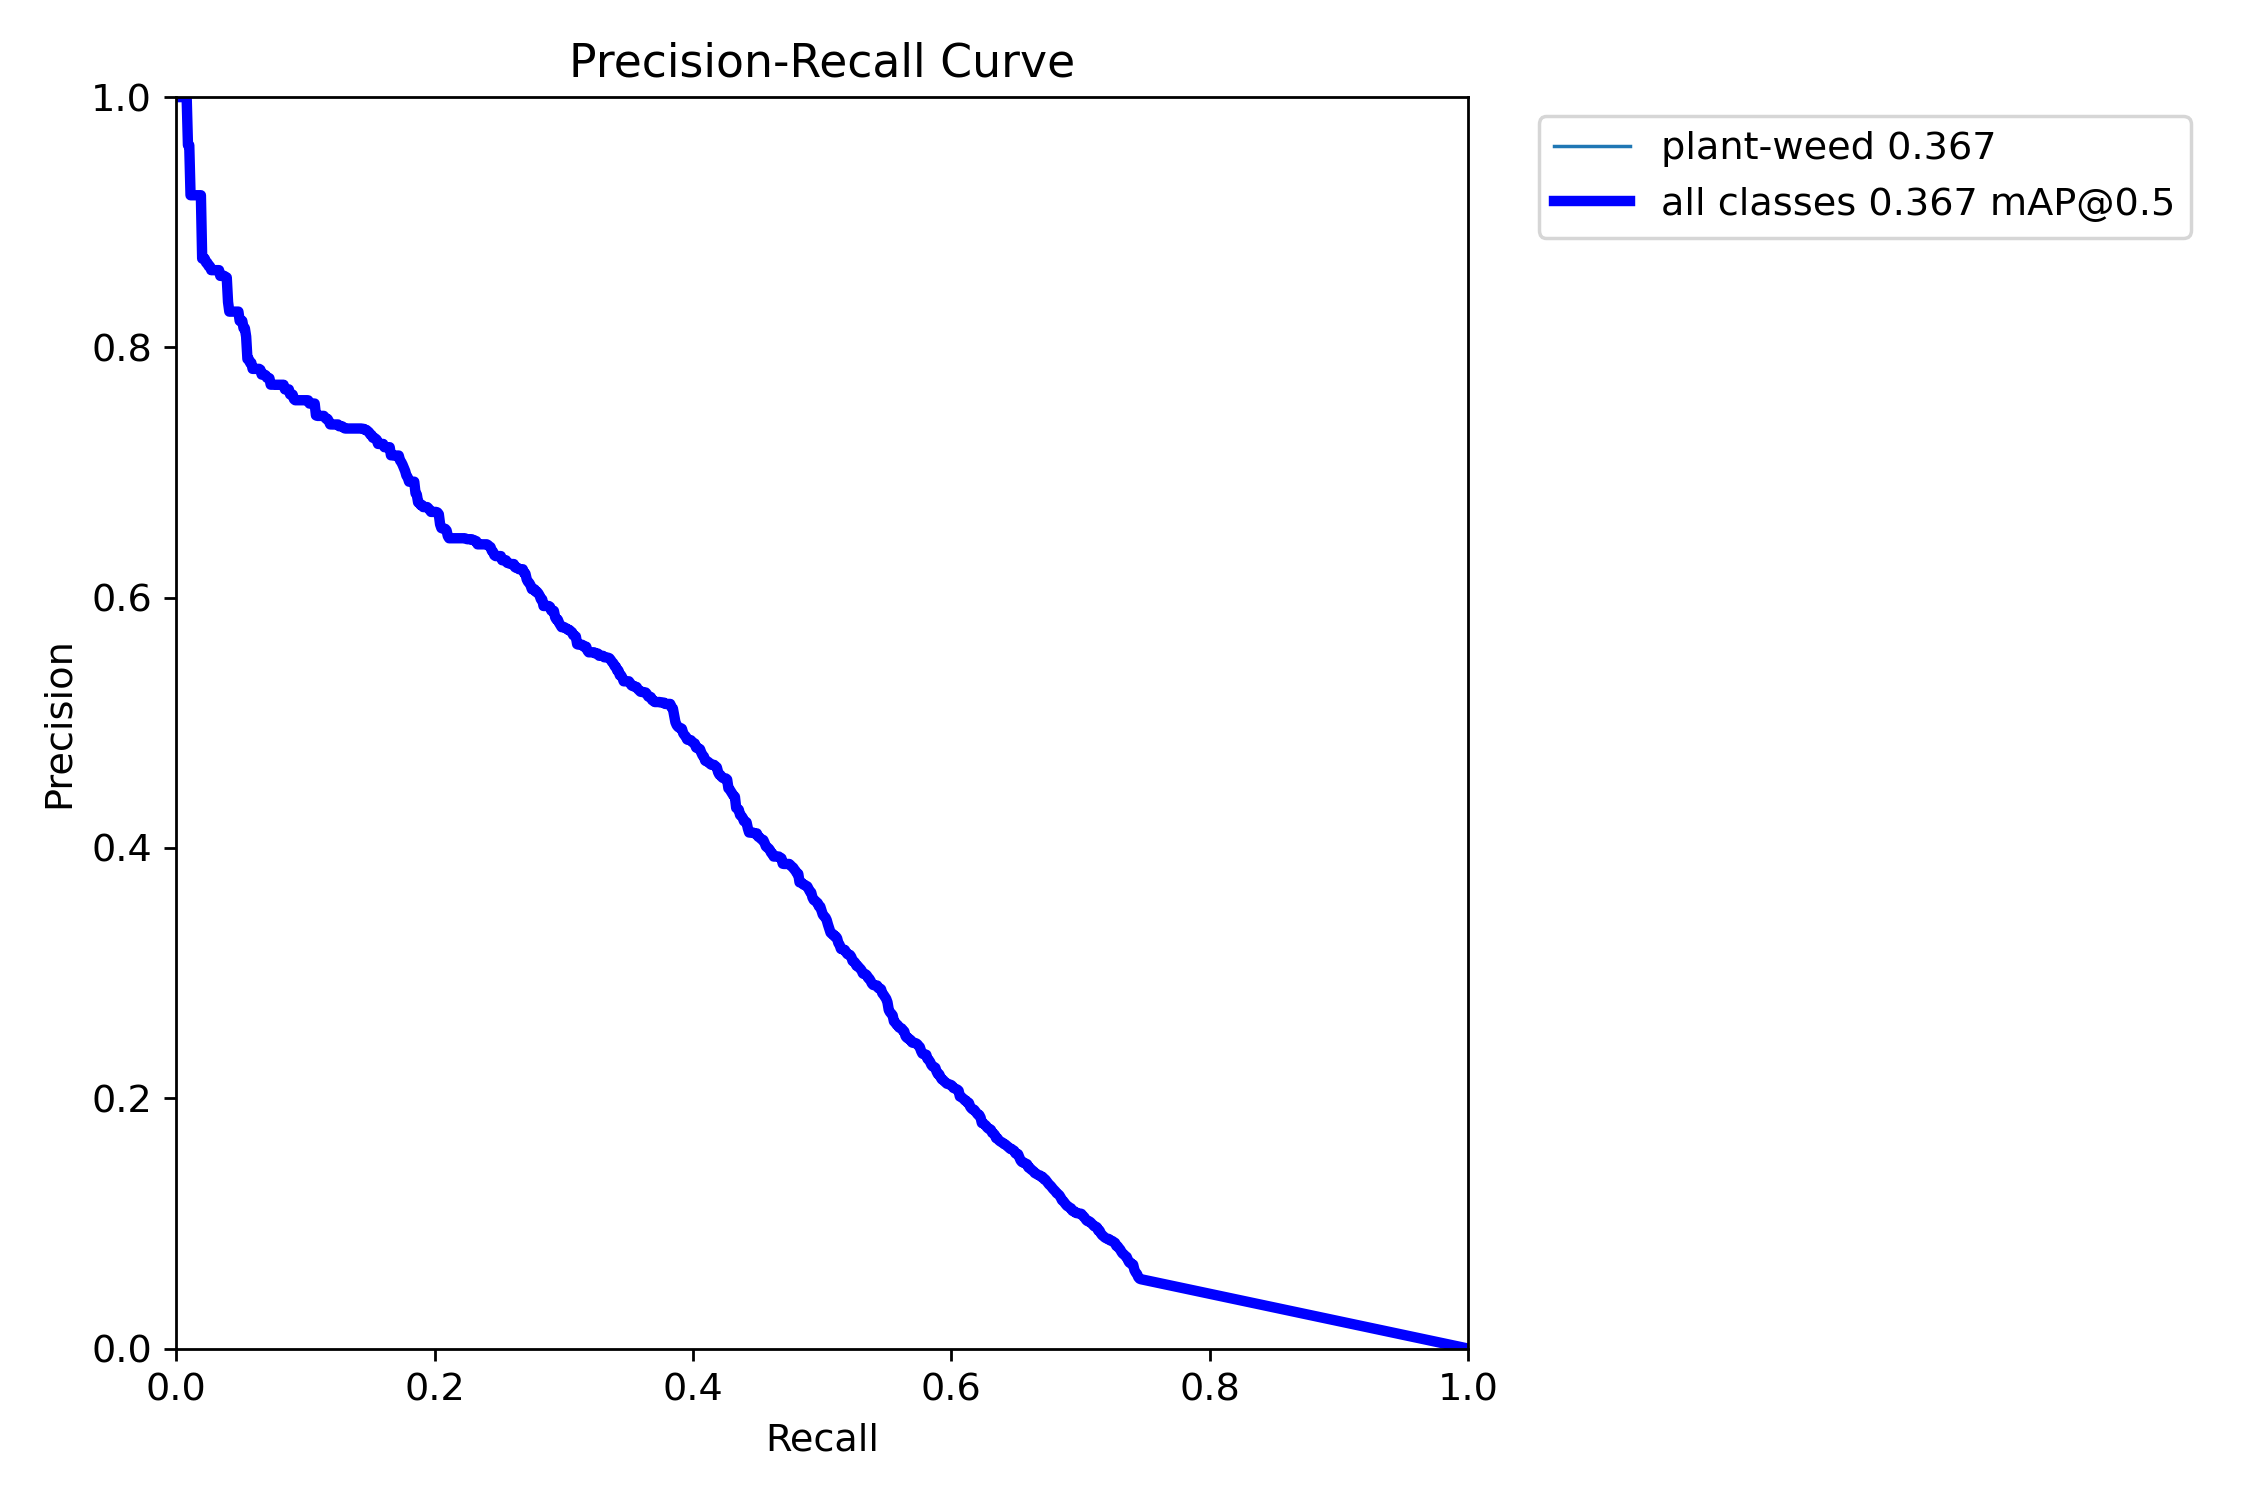

In [24]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

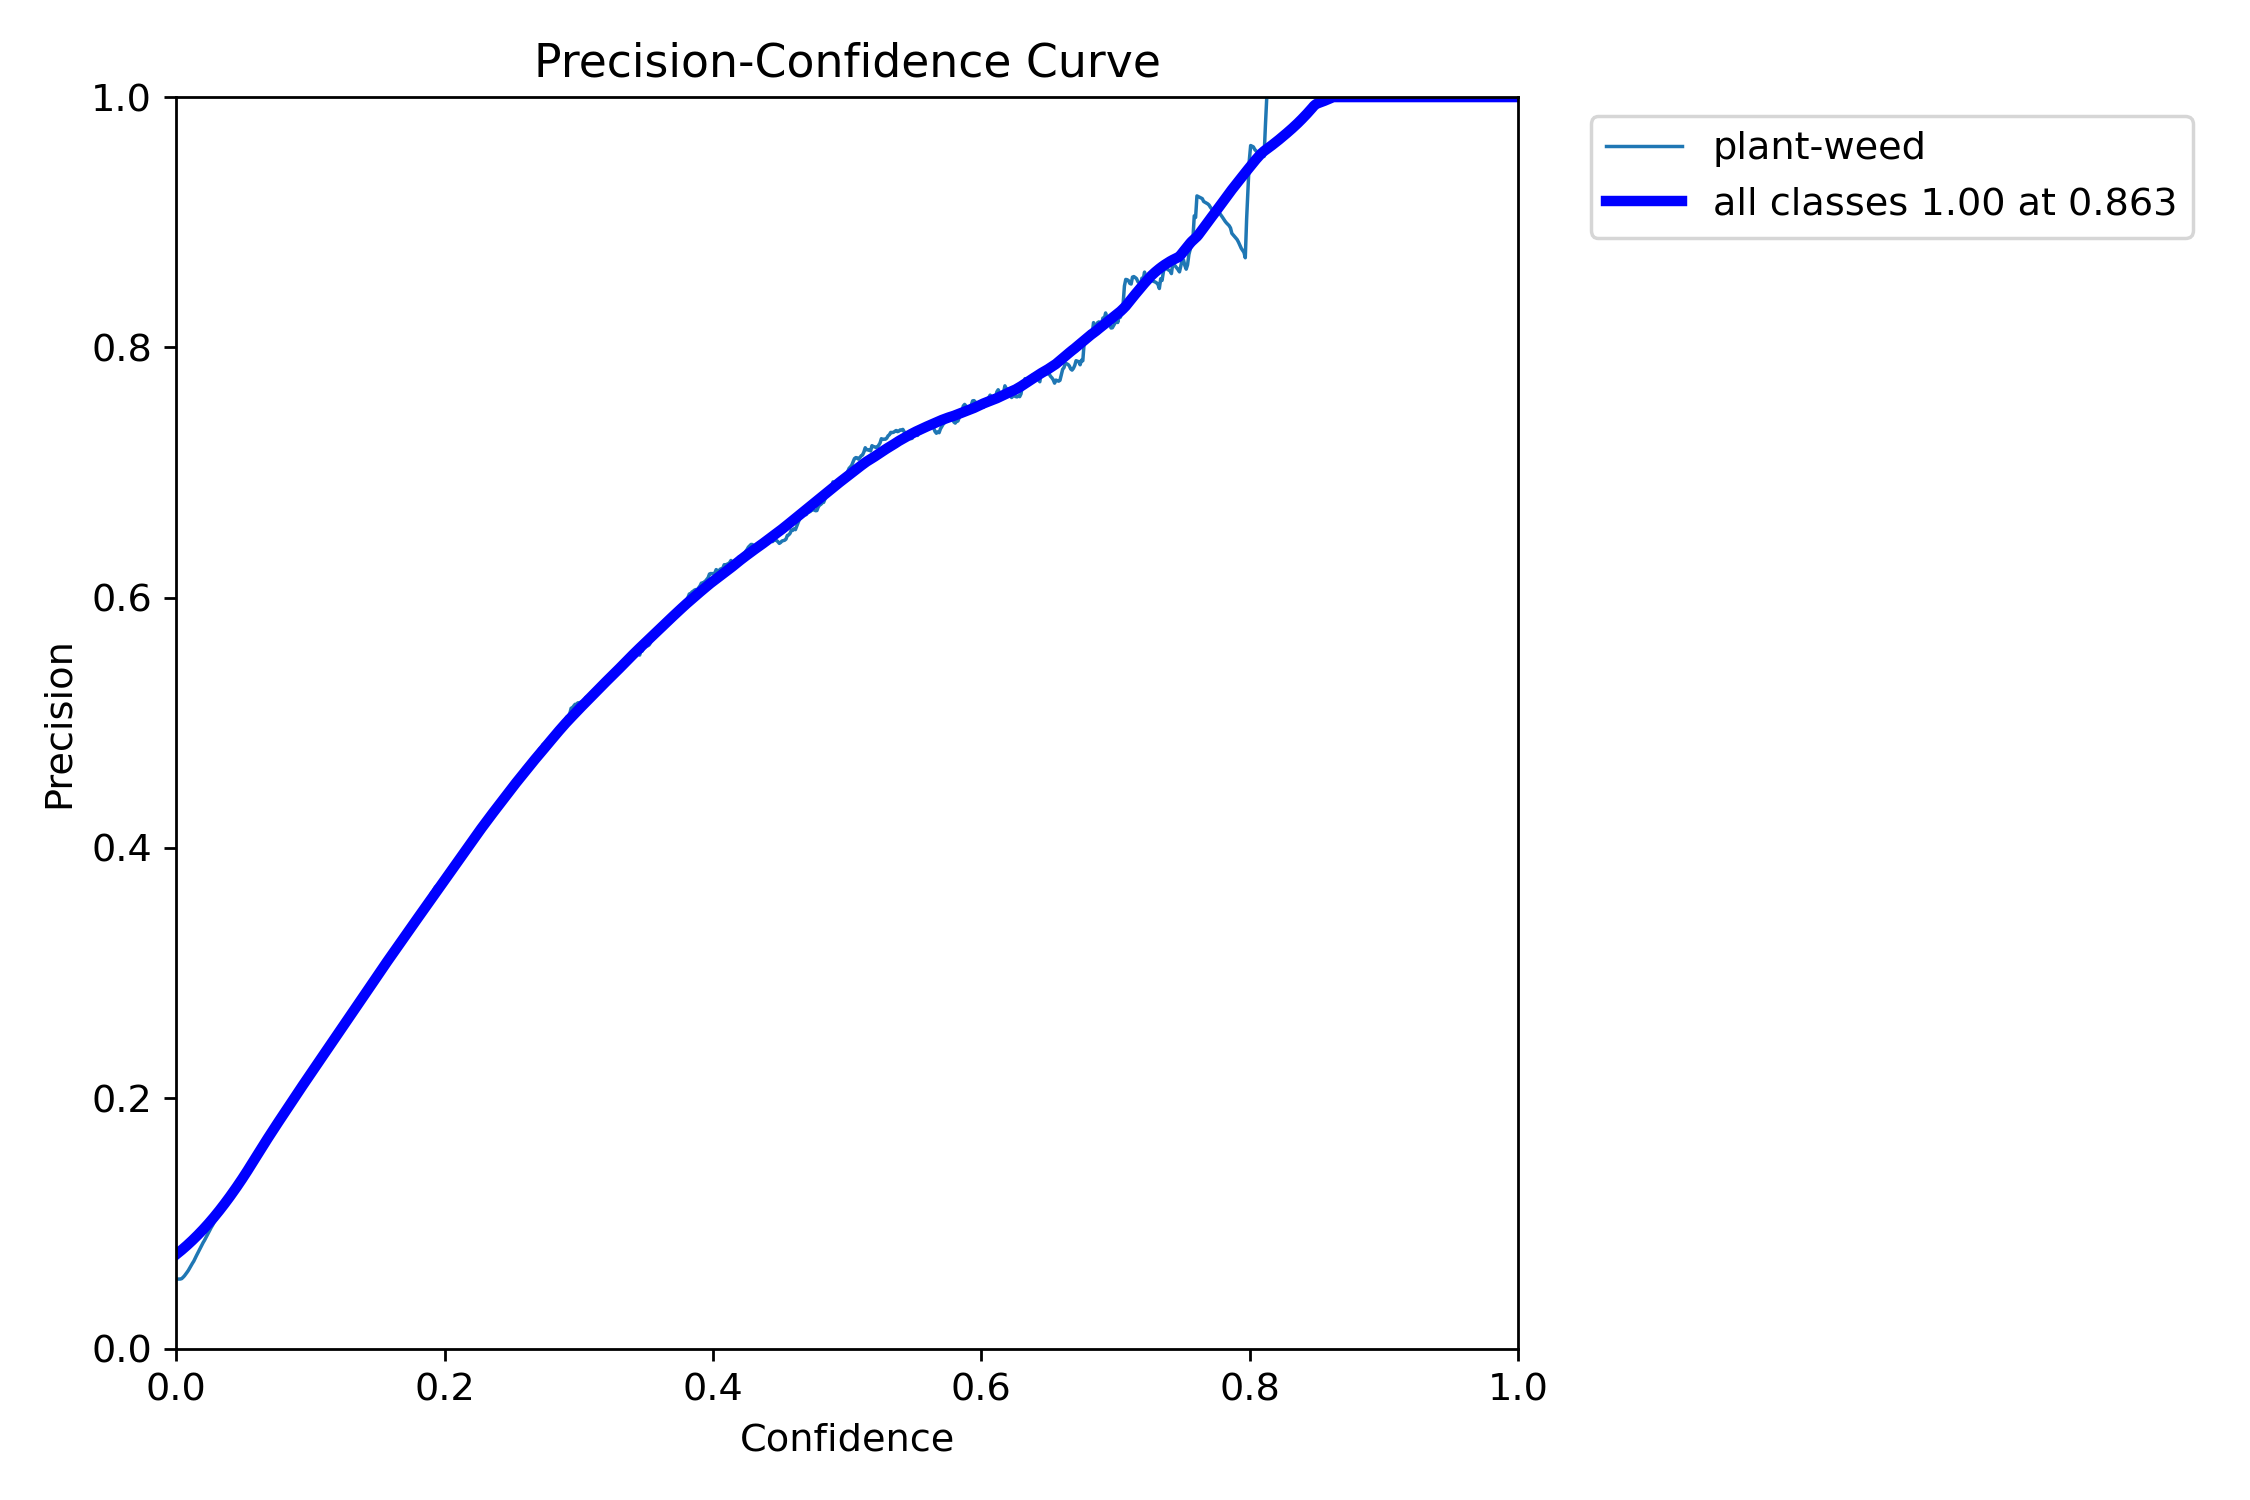

In [25]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

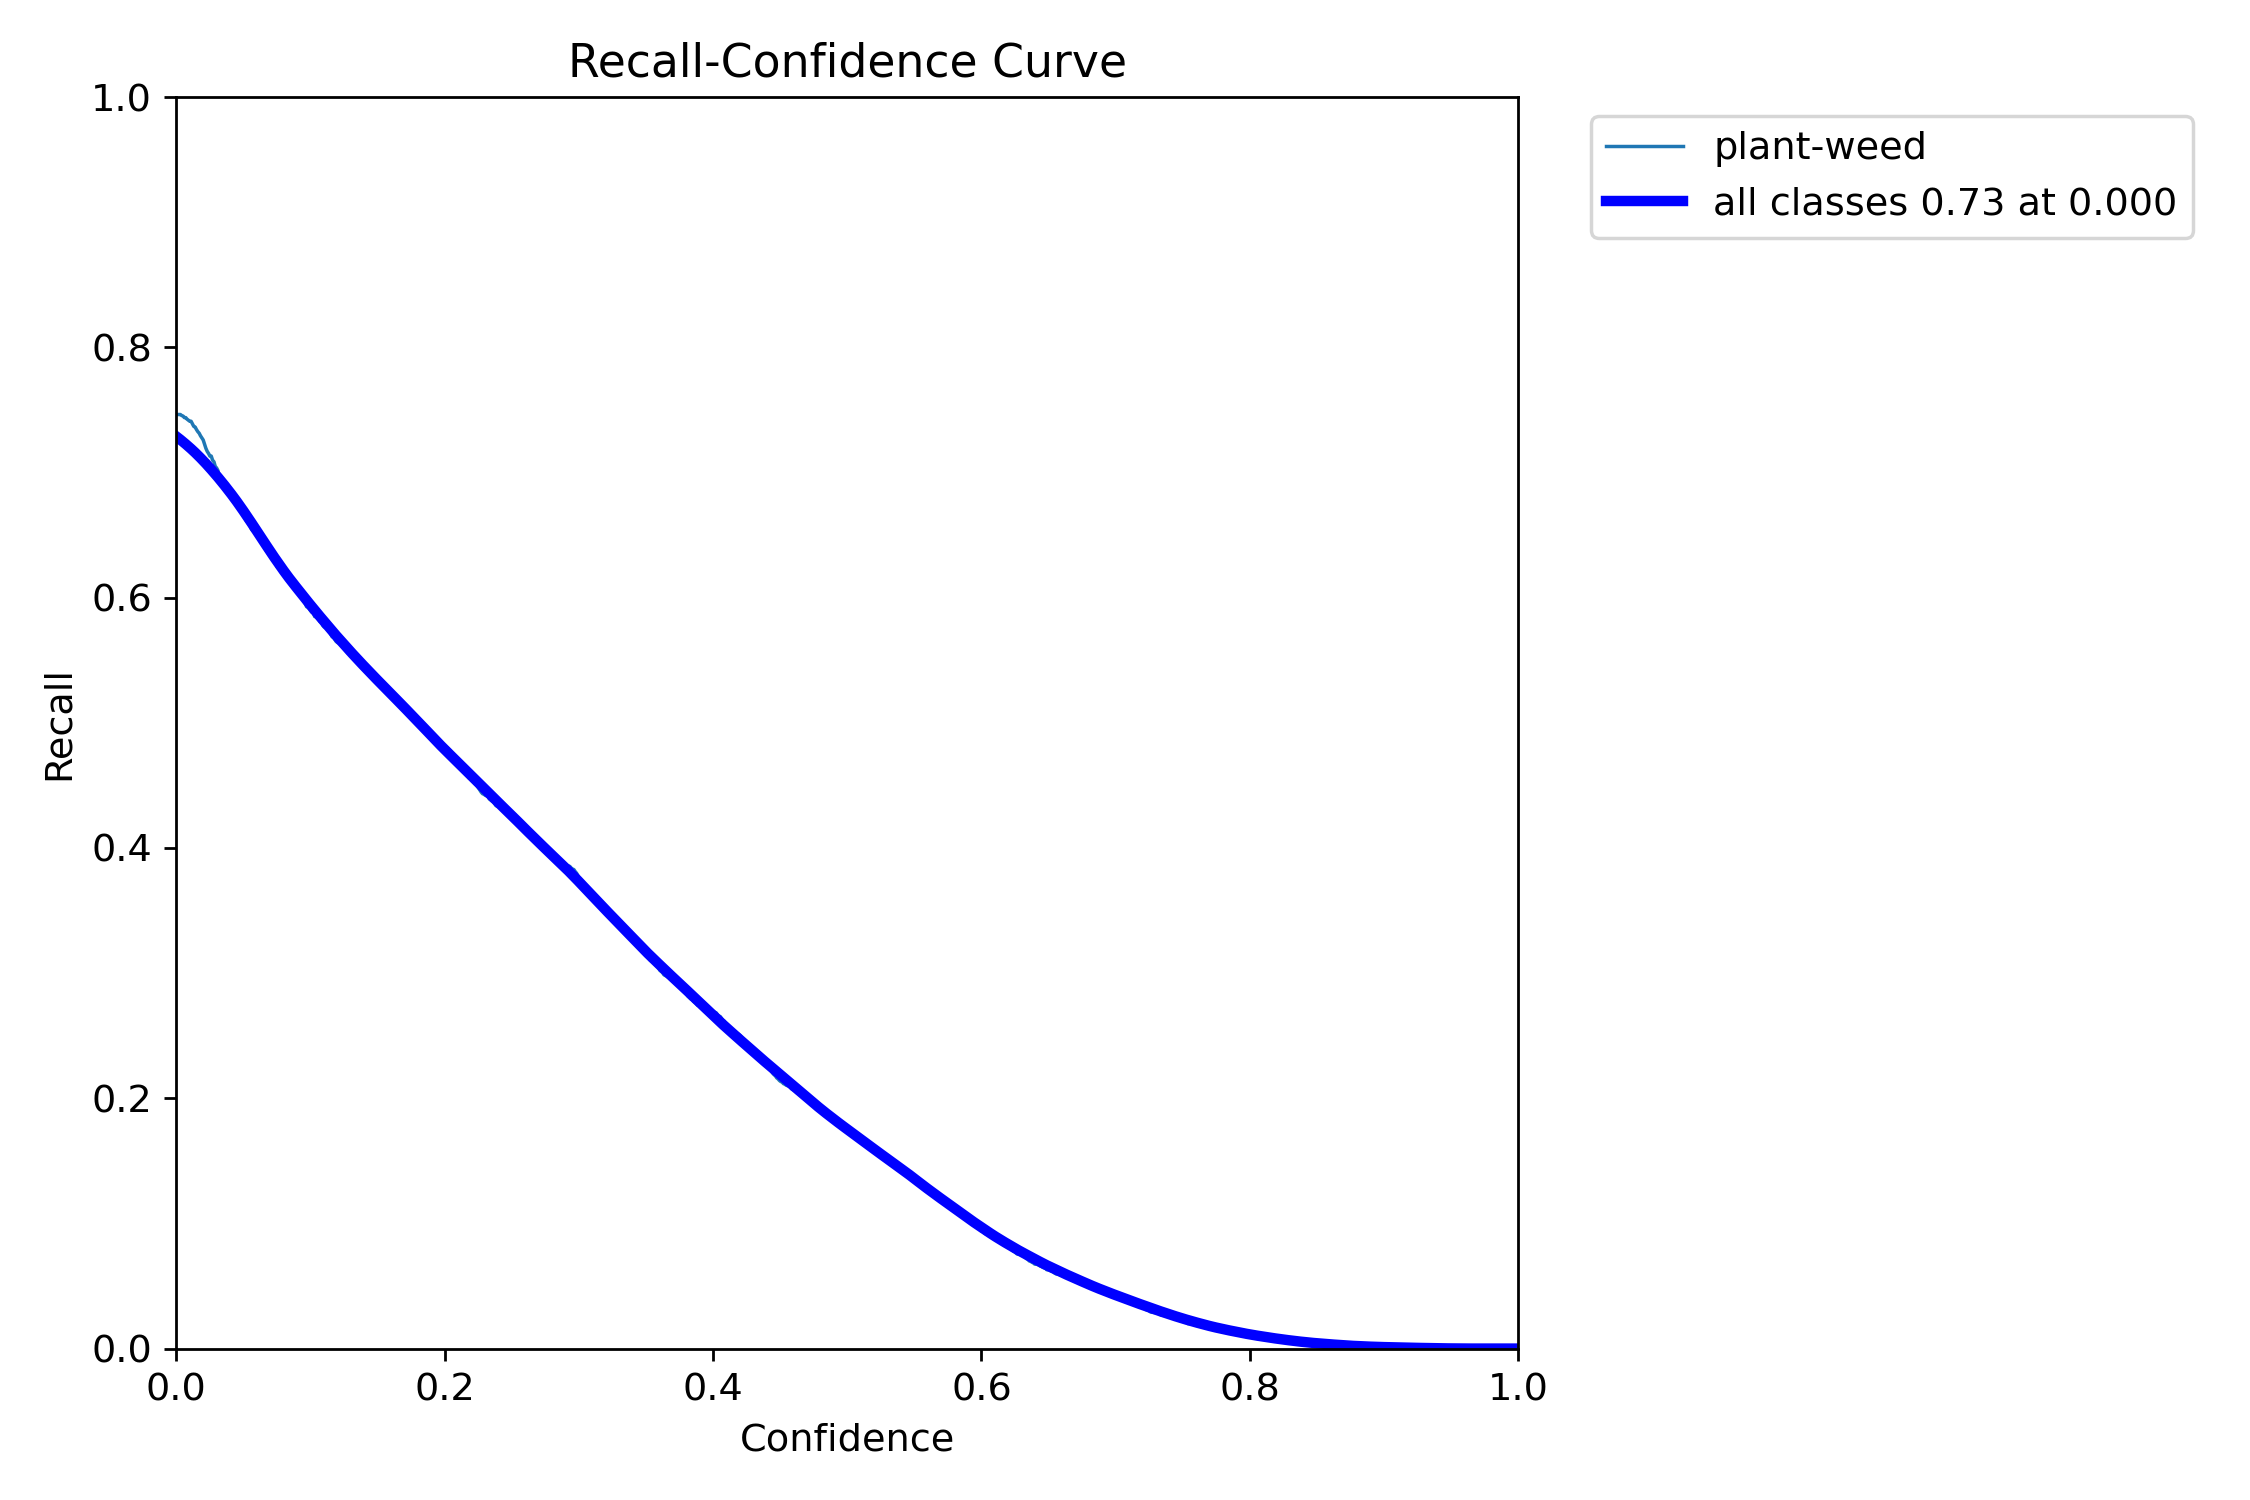

In [26]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

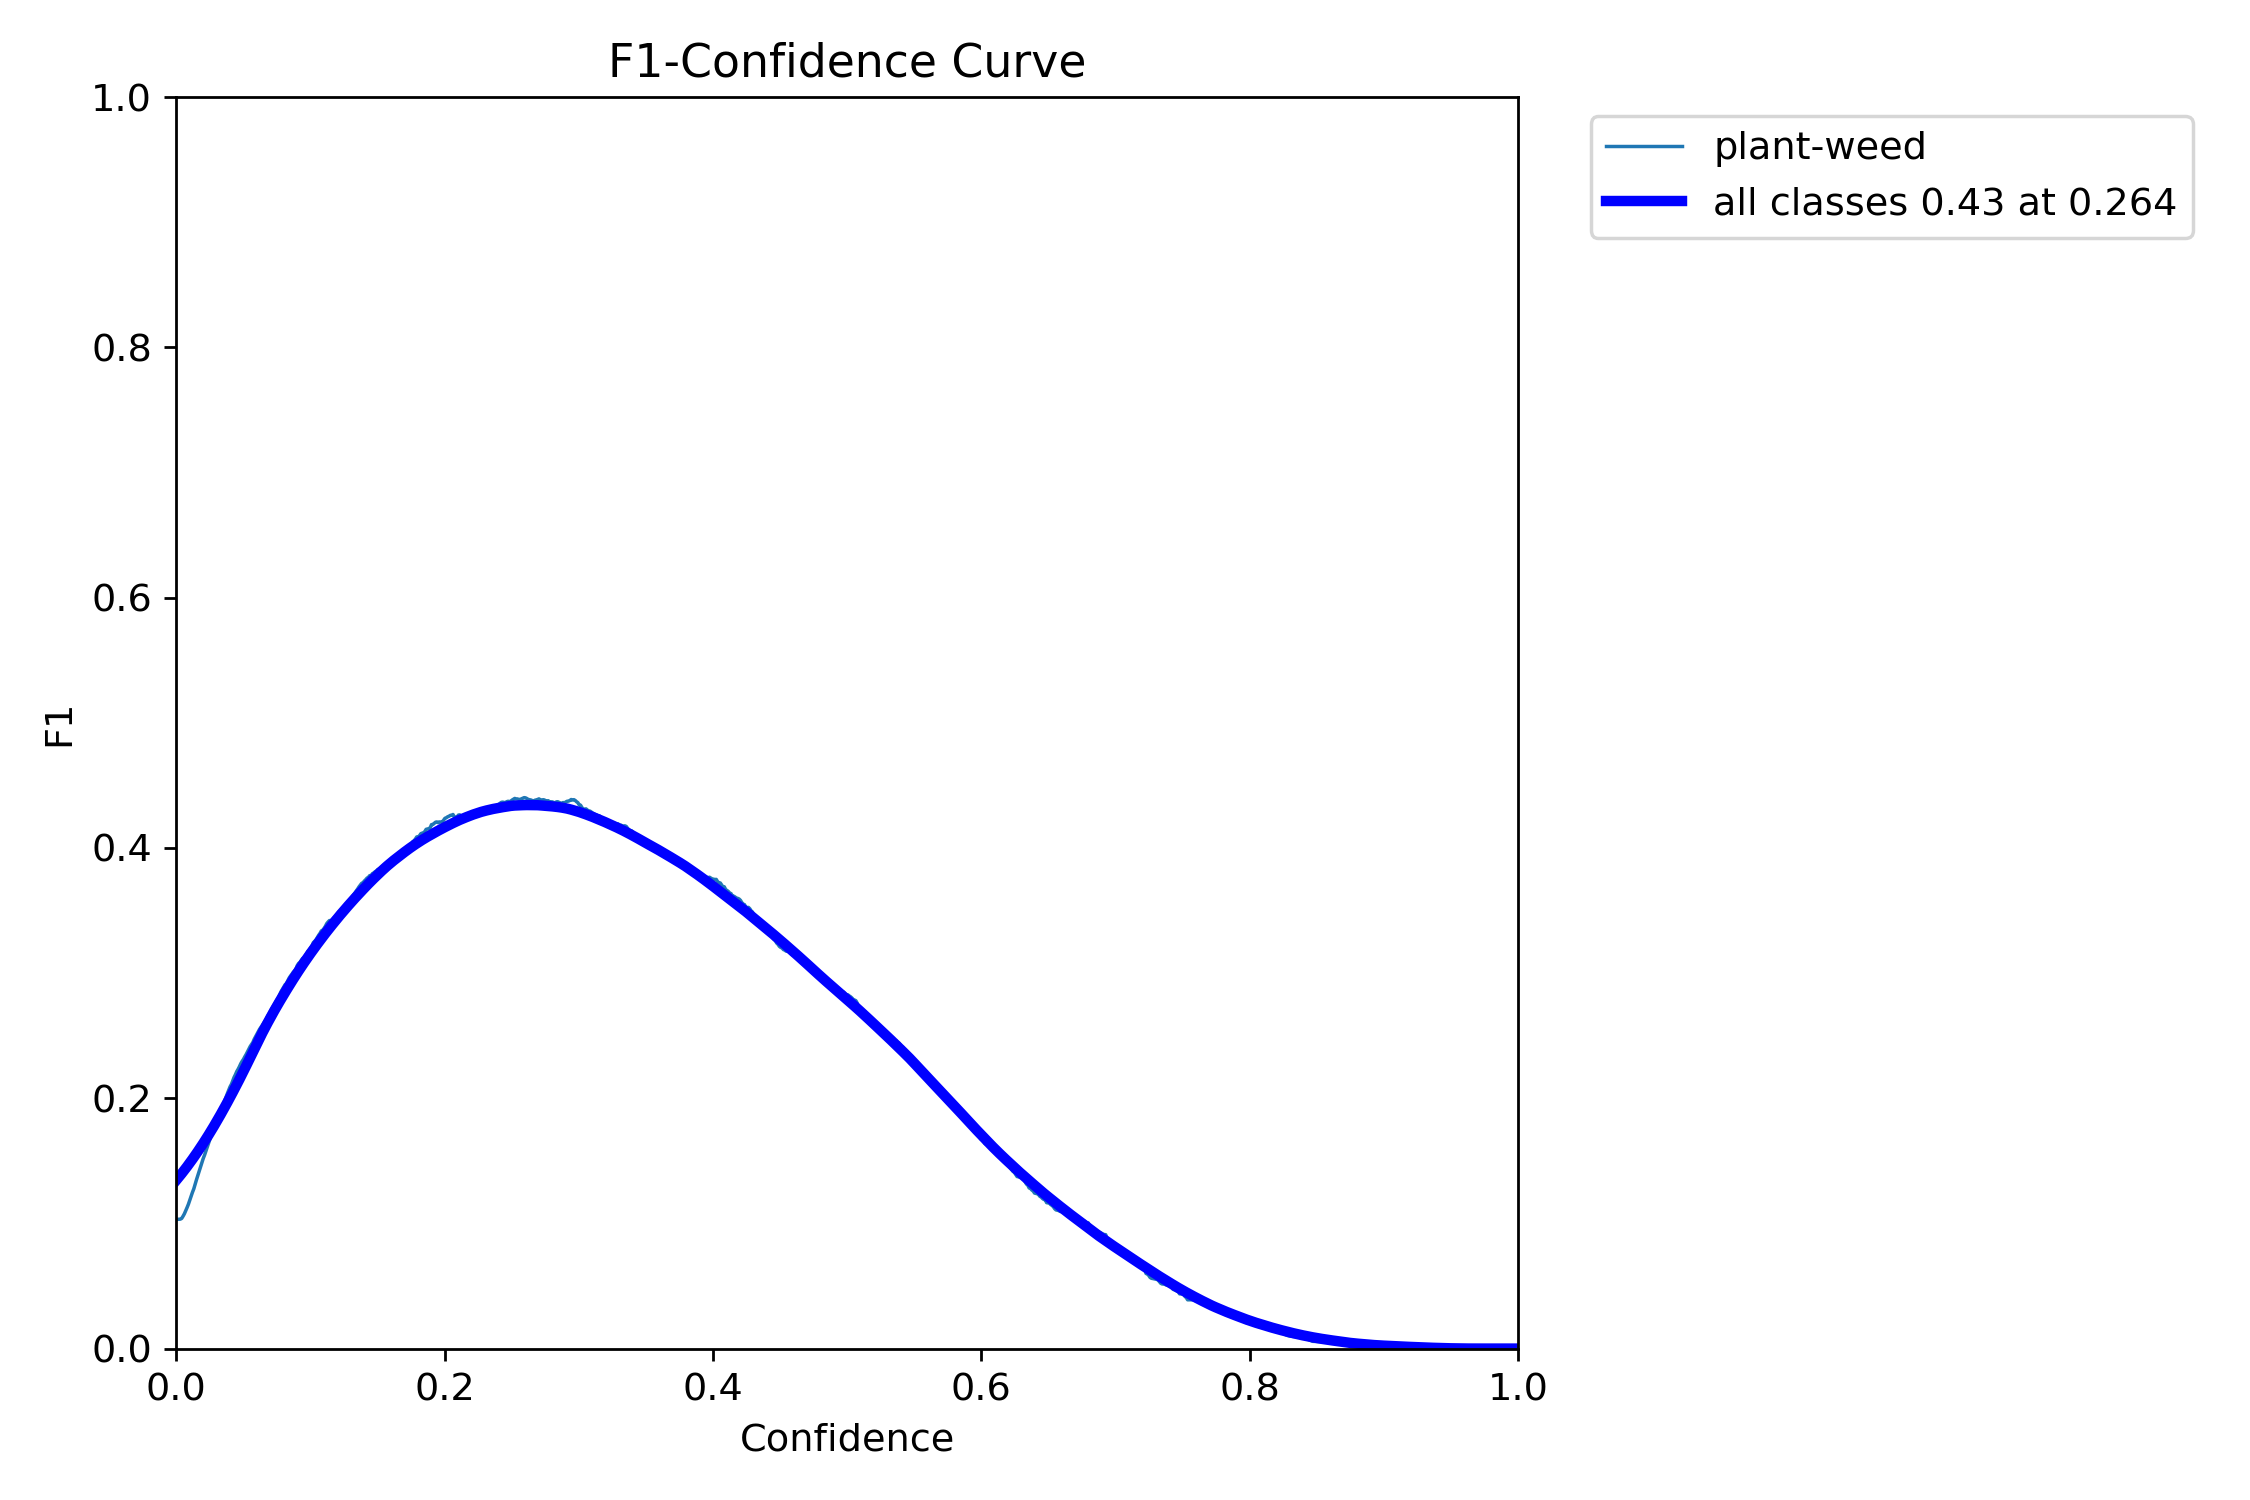

In [27]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

El valor de confianza que optimiza la precisión y recall es 0.231. En la mayoría de los casos, una mayor confianza es deseable.

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

----

## Experiment 47
### *YOLOv8 Mid | False color images*
False color images are created by applying:
1. Excess Green to a grayscale image.
1. A 2-component PCA (to reduce dimensionality).
1. Combining these images as RGB channels.

In [28]:
folder = "train2/"

In [29]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df2 = pd.read_csv(file_path)
df = df2.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
335,336,2389.36,1.26013,0.71550,1.06332,0.47657,0.47206,0.40515,0.12581,2.58282,1.32436,1.73063,0.000673,0.000673,0.000673
336,337,2396.48,1.39598,0.76426,1.17448,0.46460,0.46866,0.39916,0.12003,2.59778,1.32431,1.73276,0.000669,0.000669,0.000669
337,338,2403.88,1.23152,0.68281,1.04752,0.48637,0.45558,0.40223,0.12348,2.60646,1.33516,1.74401,0.000665,0.000665,0.000665
338,339,2410.56,1.28102,0.72490,1.11682,0.48696,0.46492,0.40513,0.12534,2.61280,1.30639,1.76458,0.000662,0.000662,0.000662
339,340,2418.15,1.23602,0.69021,1.08044,0.47288,0.47198,0.40708,0.12369,2.62610,1.32355,1.76676,0.000658,0.000658,0.000658


In [30]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 40.303 min


In [31]:
df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
39,40,291.001,2.1025,1.58523,1.51643,0.51472,0.47323,0.44668,0.1479,2.27246,1.6696,1.50983,0.001846,0.001846,0.001846


#### Best epoch

In [32]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
39,40,291.001,2.1025,1.58523,1.51643,0.51472,0.47323,0.44668,0.1479,2.27246,1.6696,1.50983,0.001846,0.001846,0.001846,40.3025


In [33]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 40 con mAP50 de 0.447


In [34]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [14]:
# Setting values from CM graph
TP = 1631
FP = 3165
FN = 768

In [6]:
# Confusion matrix
show_metrics(TP, FP, FN)

Total objects detected: 5564

Confusion matrix:
[ 29.31% , 56.88% ]
[ 13.80% , 0.00% ]

Metrics:
- Accuracy: 0.293
- Precision: 0.340
- Recall: 0.680
- F1 Score: 0.453
- F½ Score: 0.378
- G-mean: 0.481


### Graphs

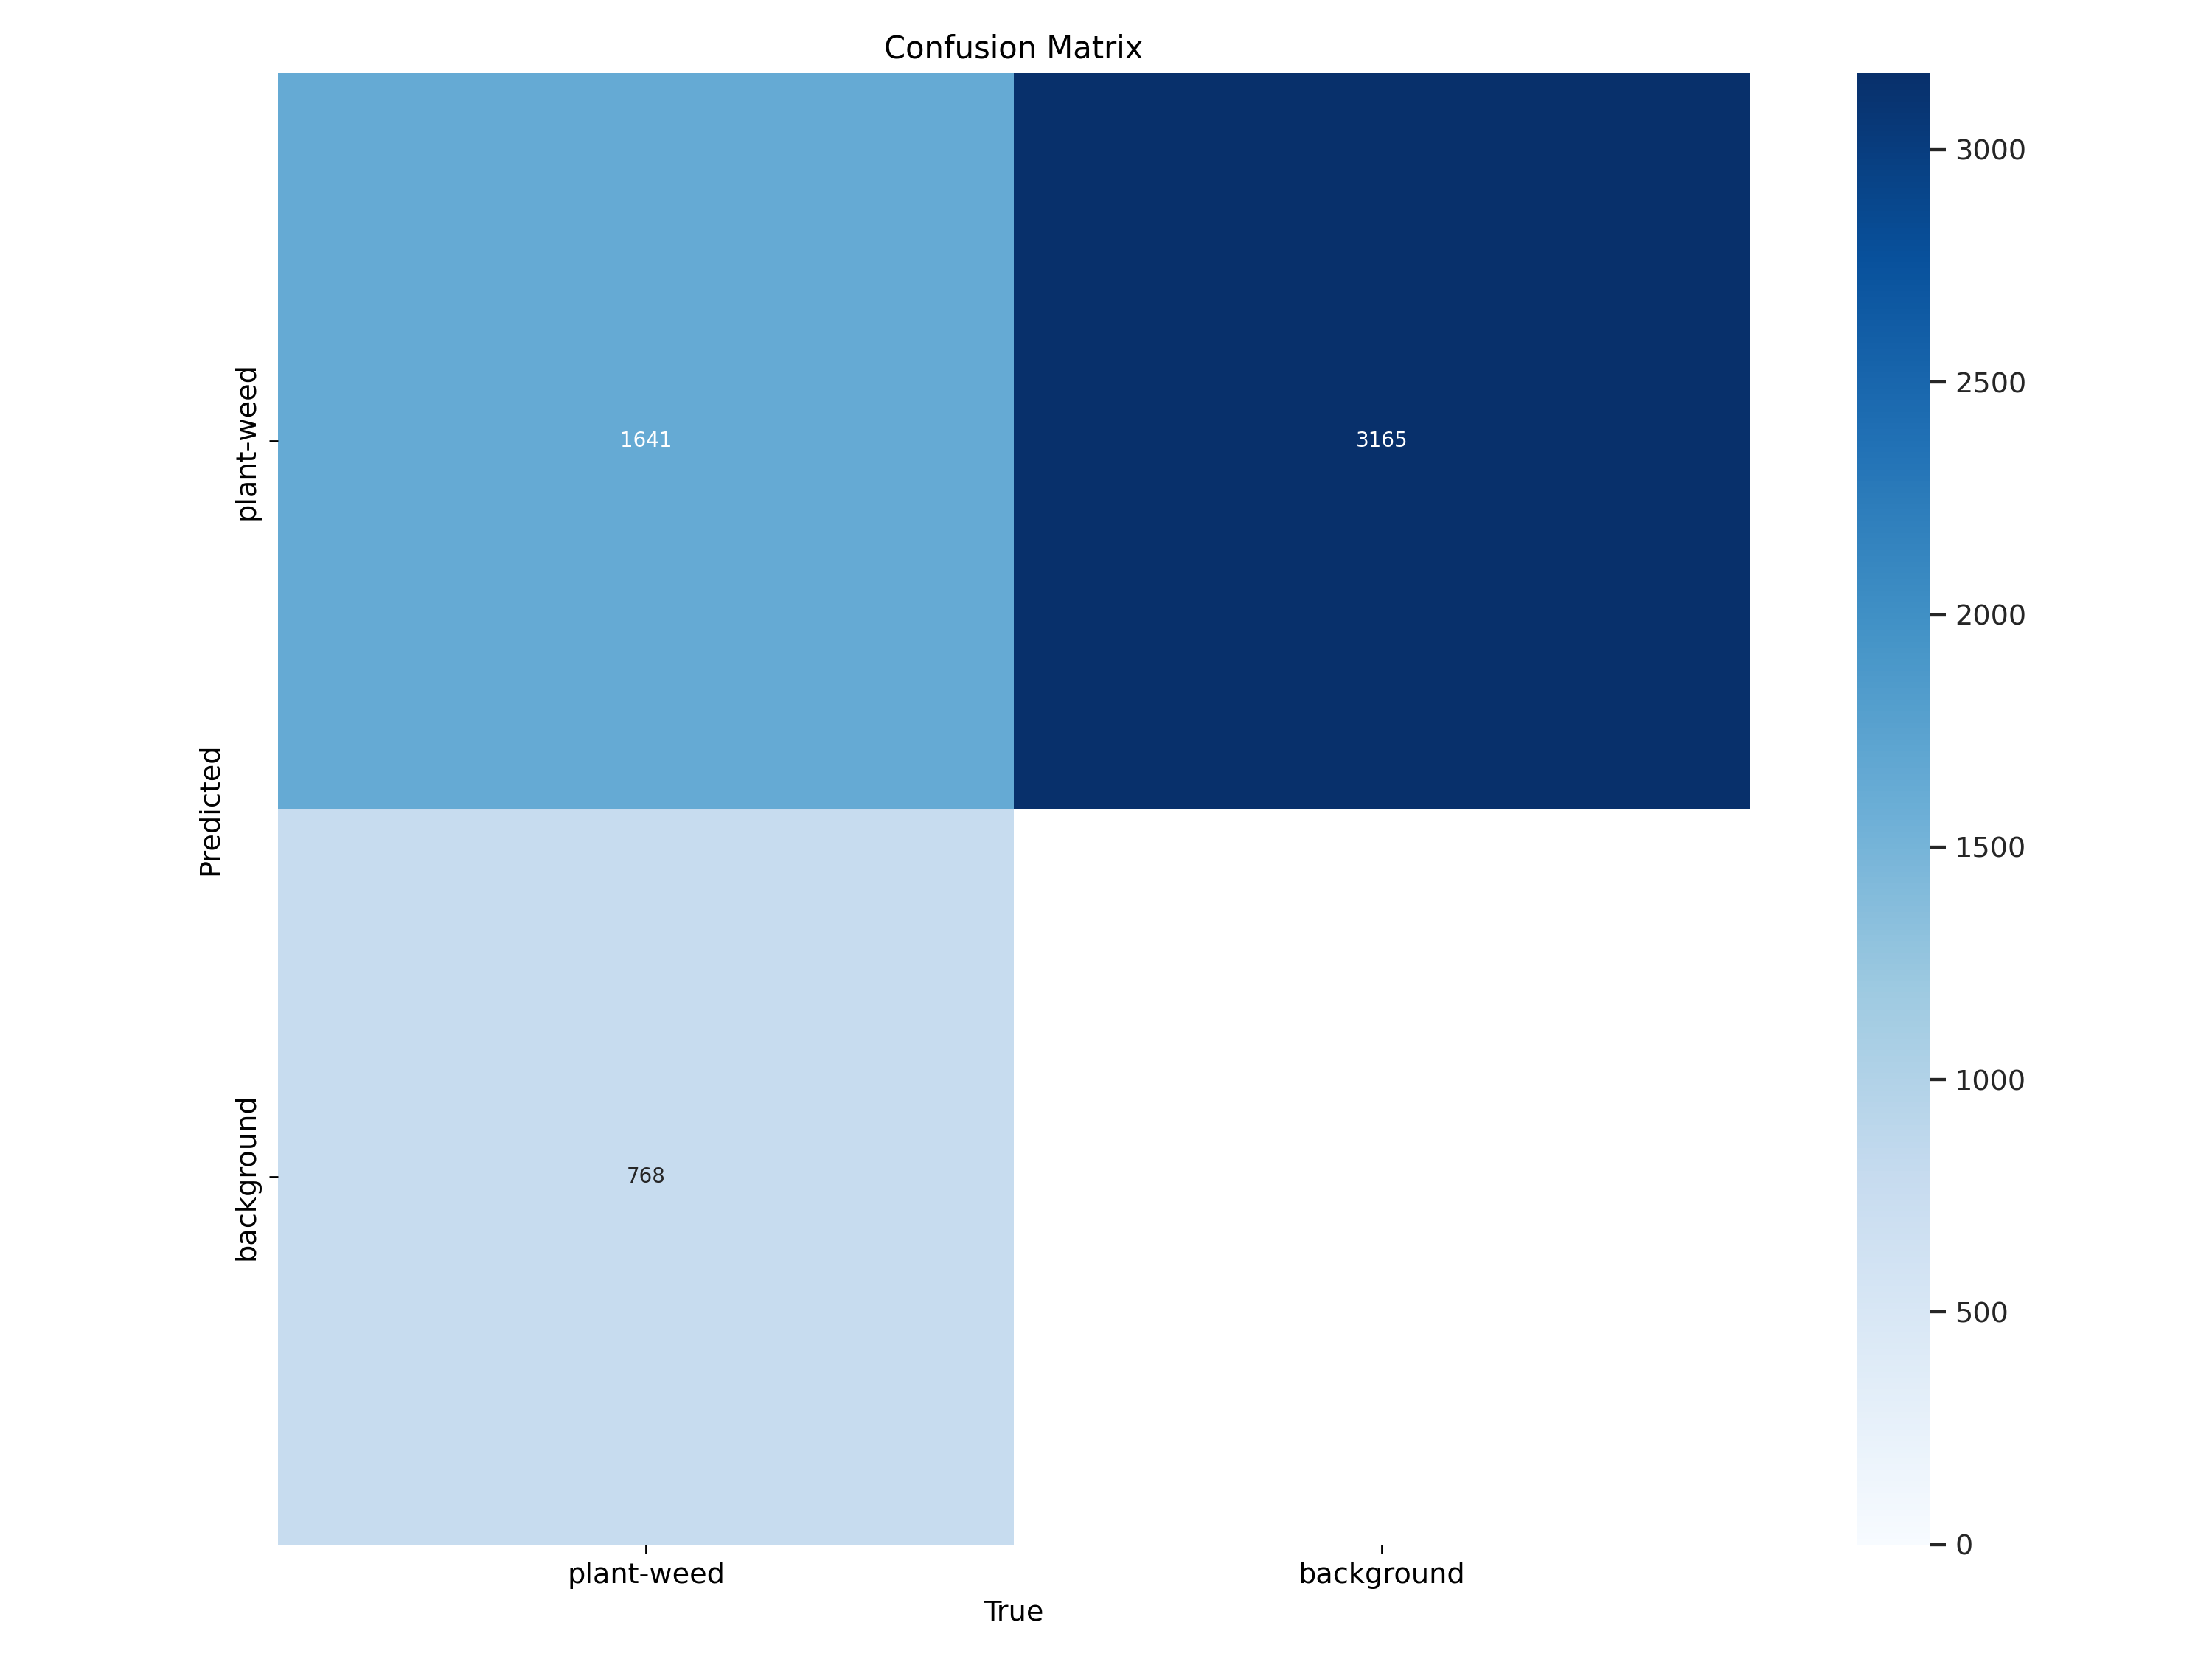

In [38]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

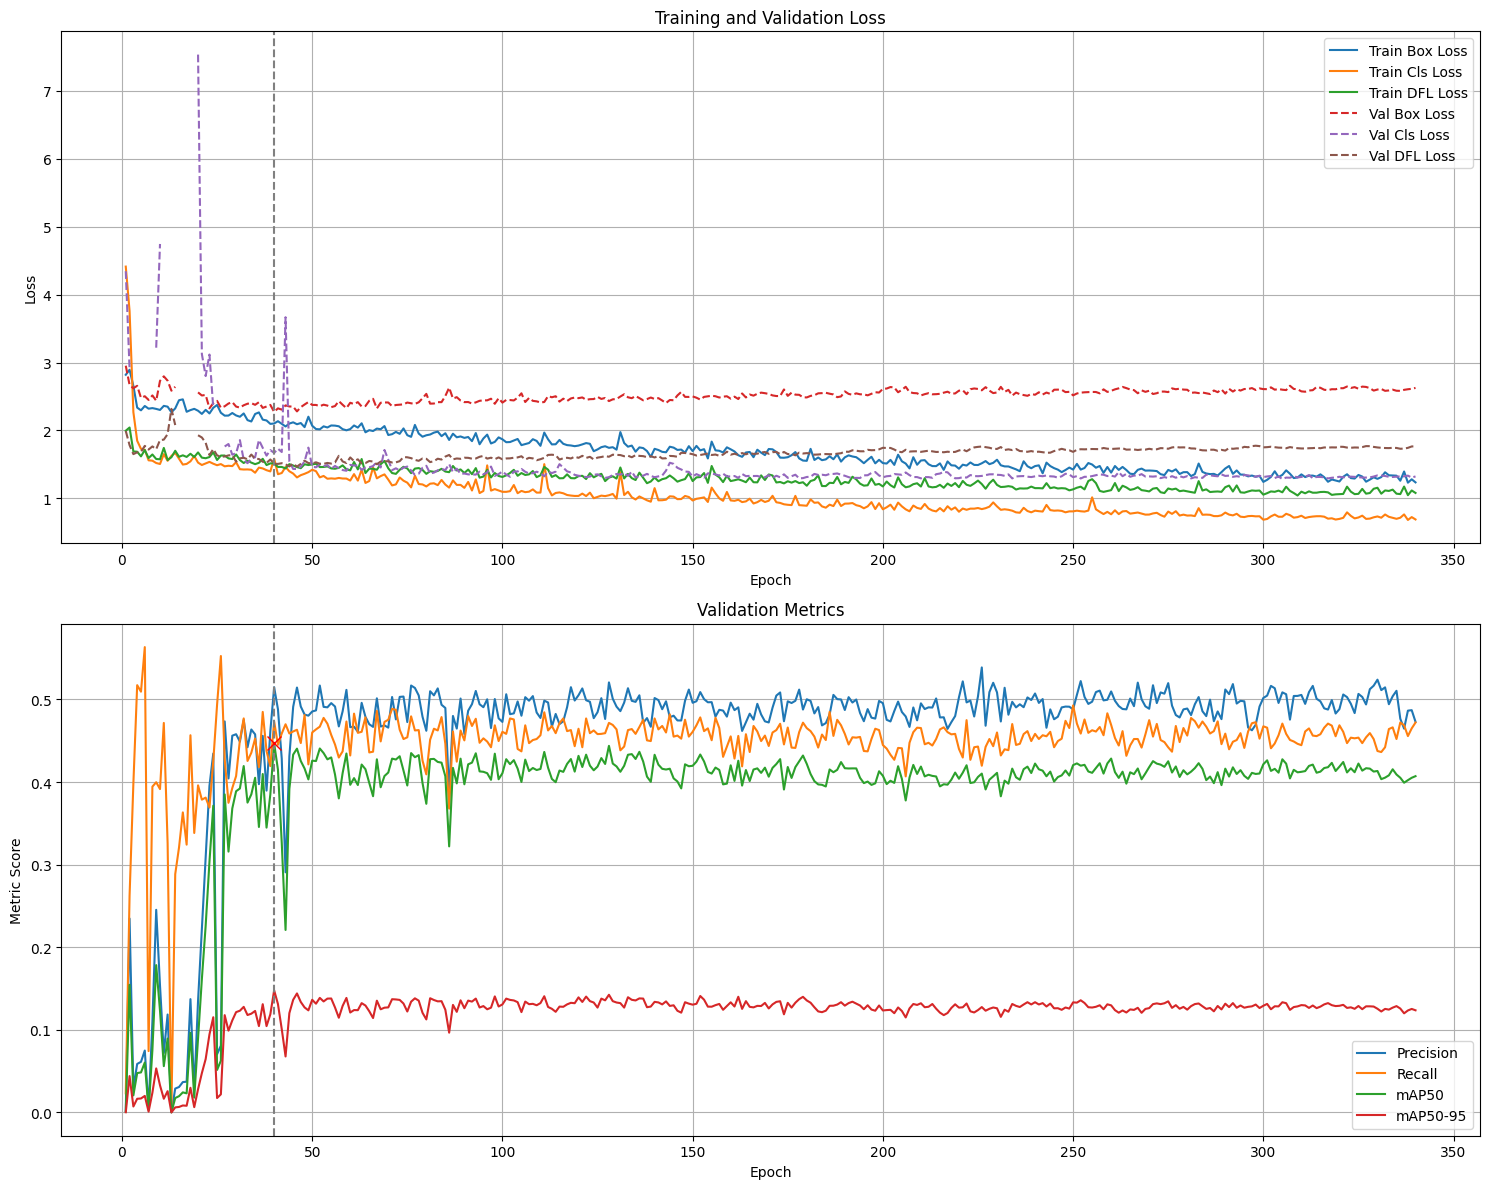

In [39]:
graph_training_metrics(df, epoch, graph="full")

In [40]:
graph_LrLoss_3D(df)

Validation set


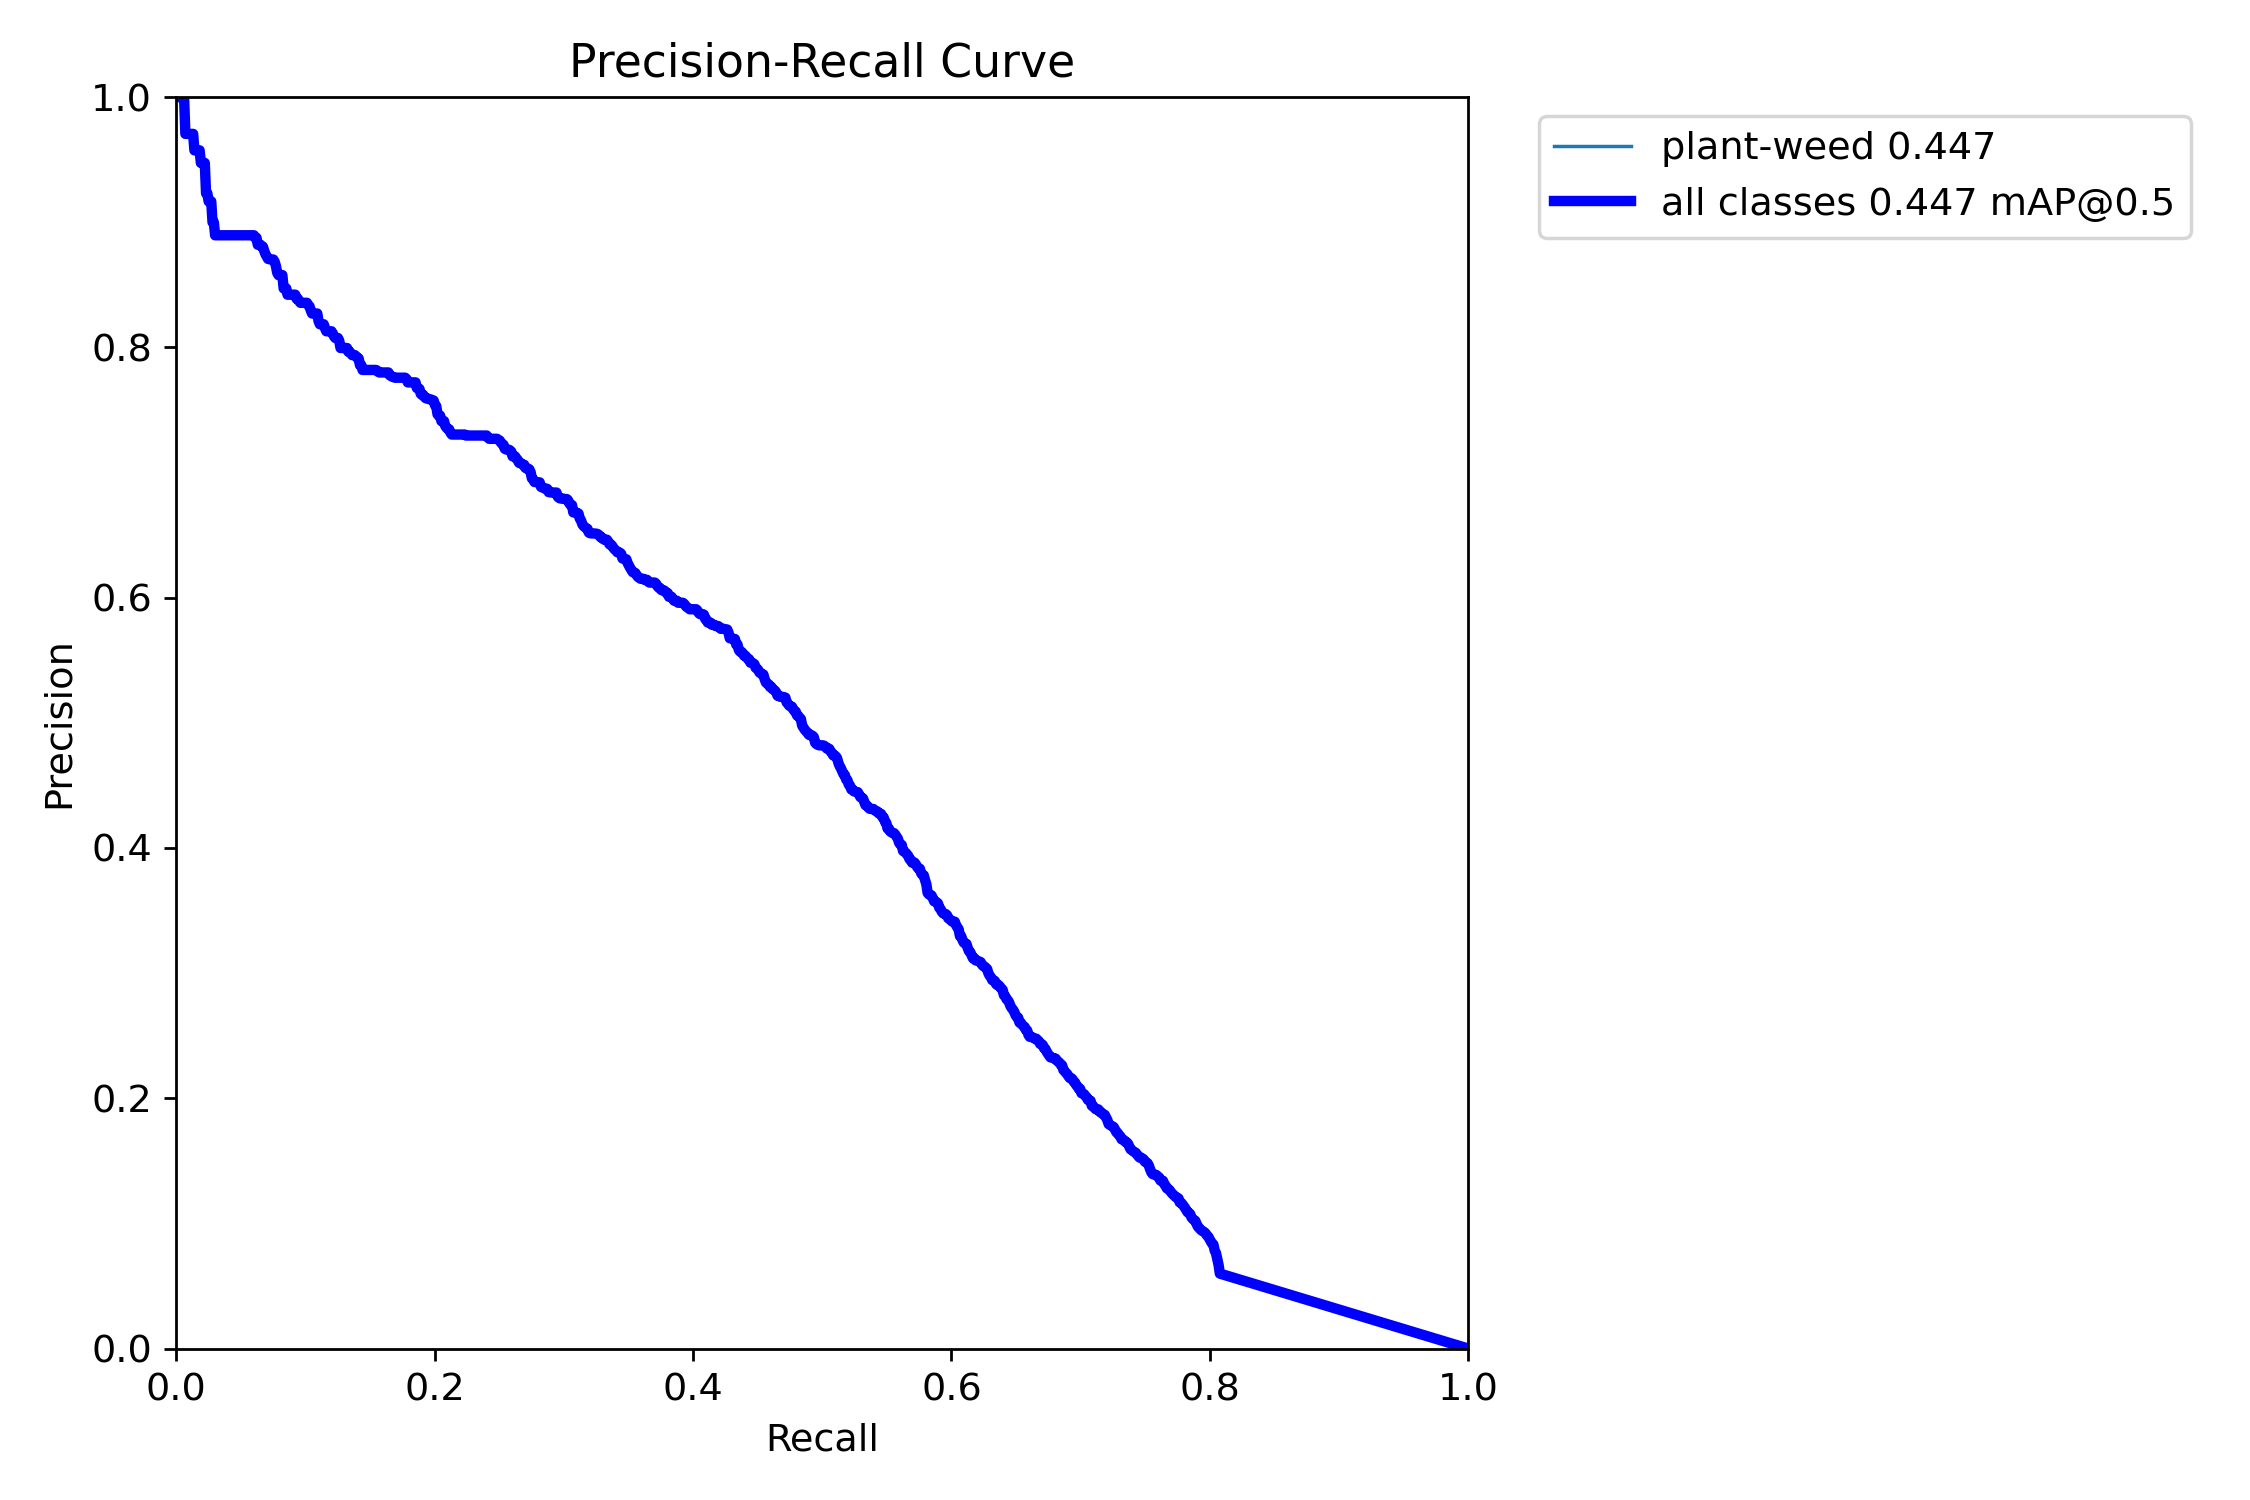

In [41]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

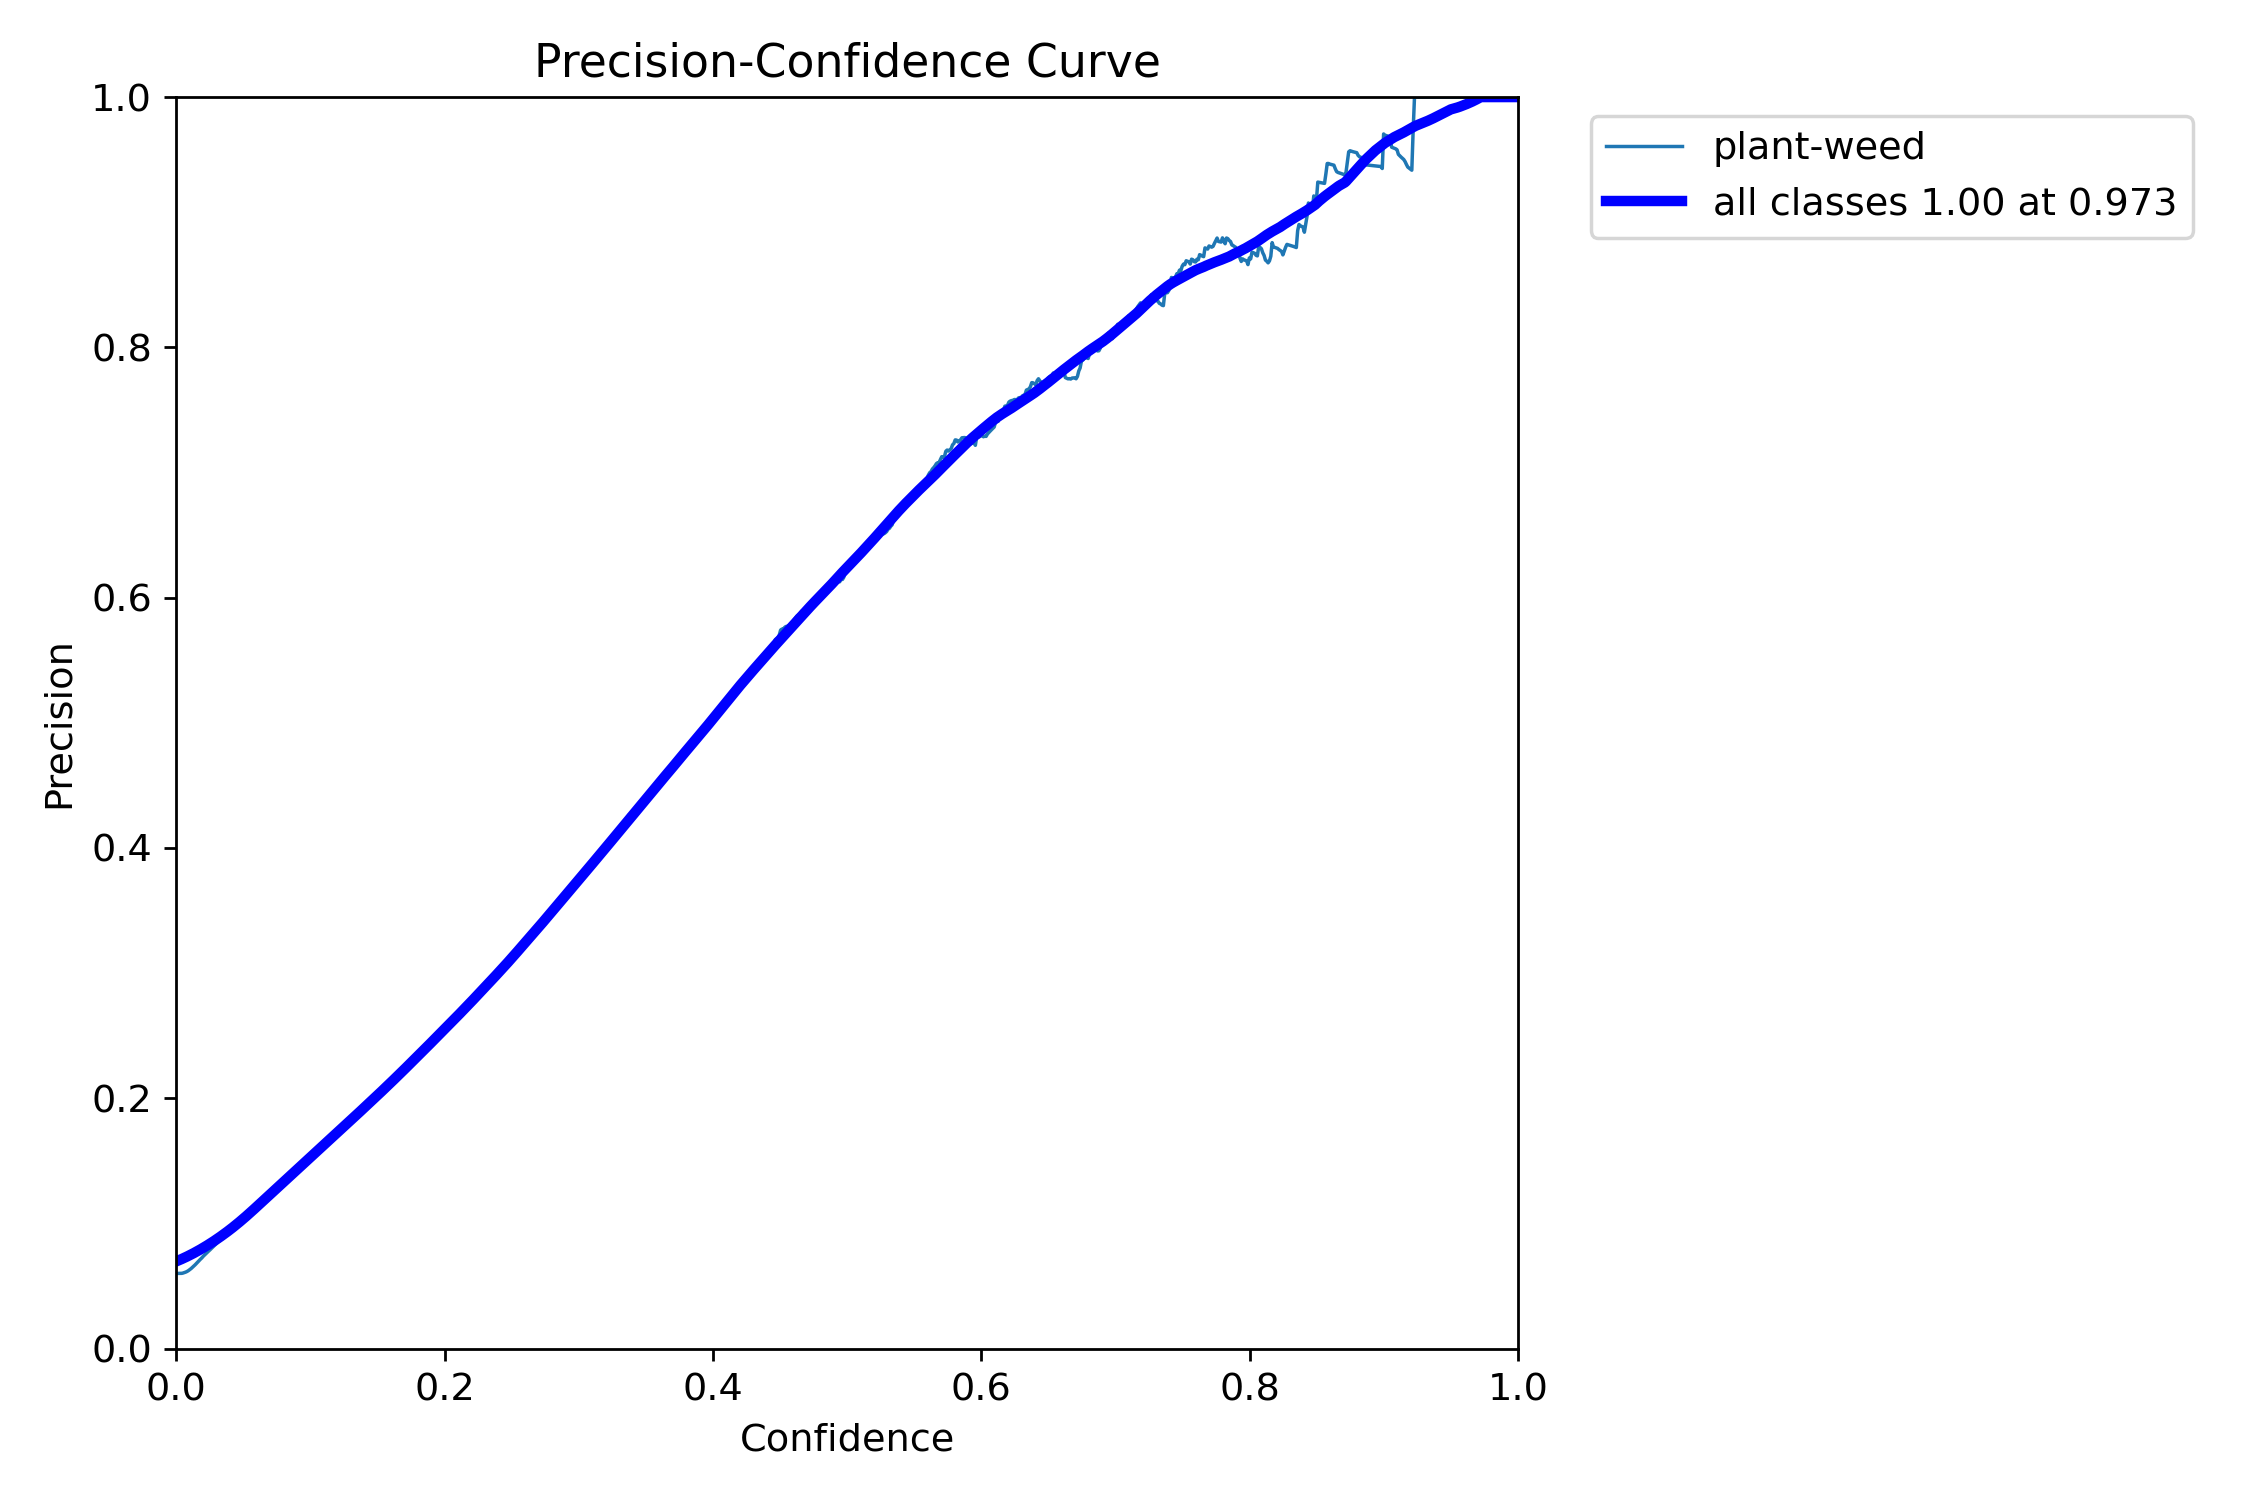

In [42]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

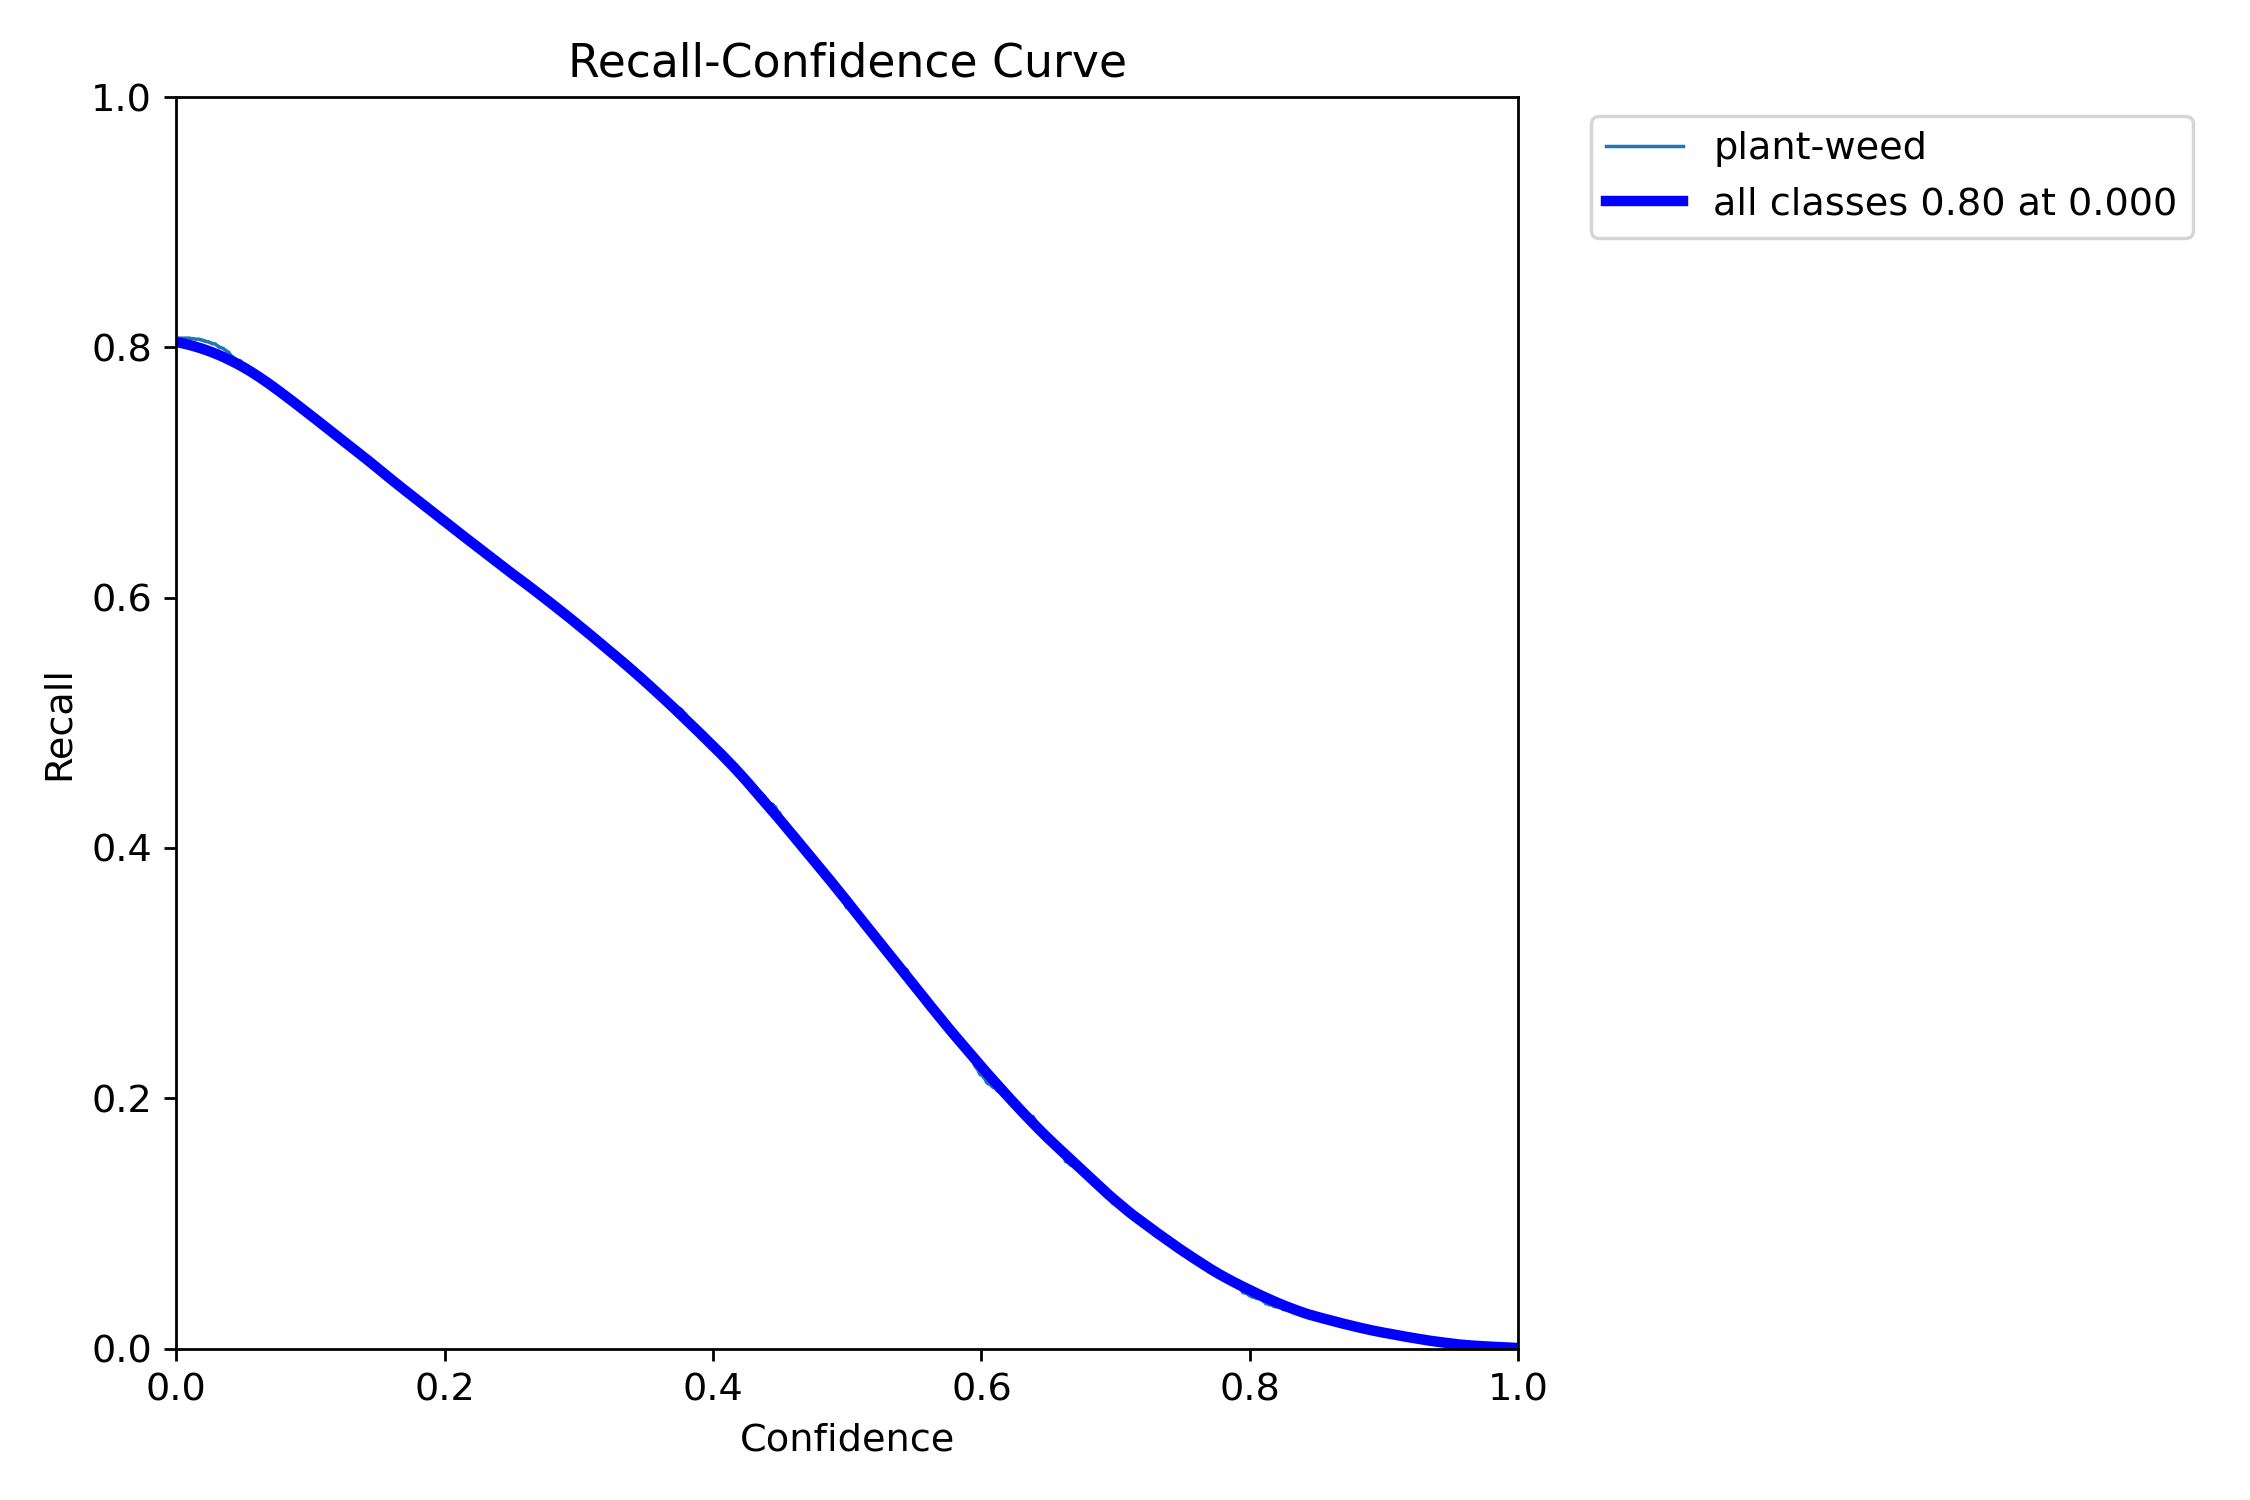

In [43]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

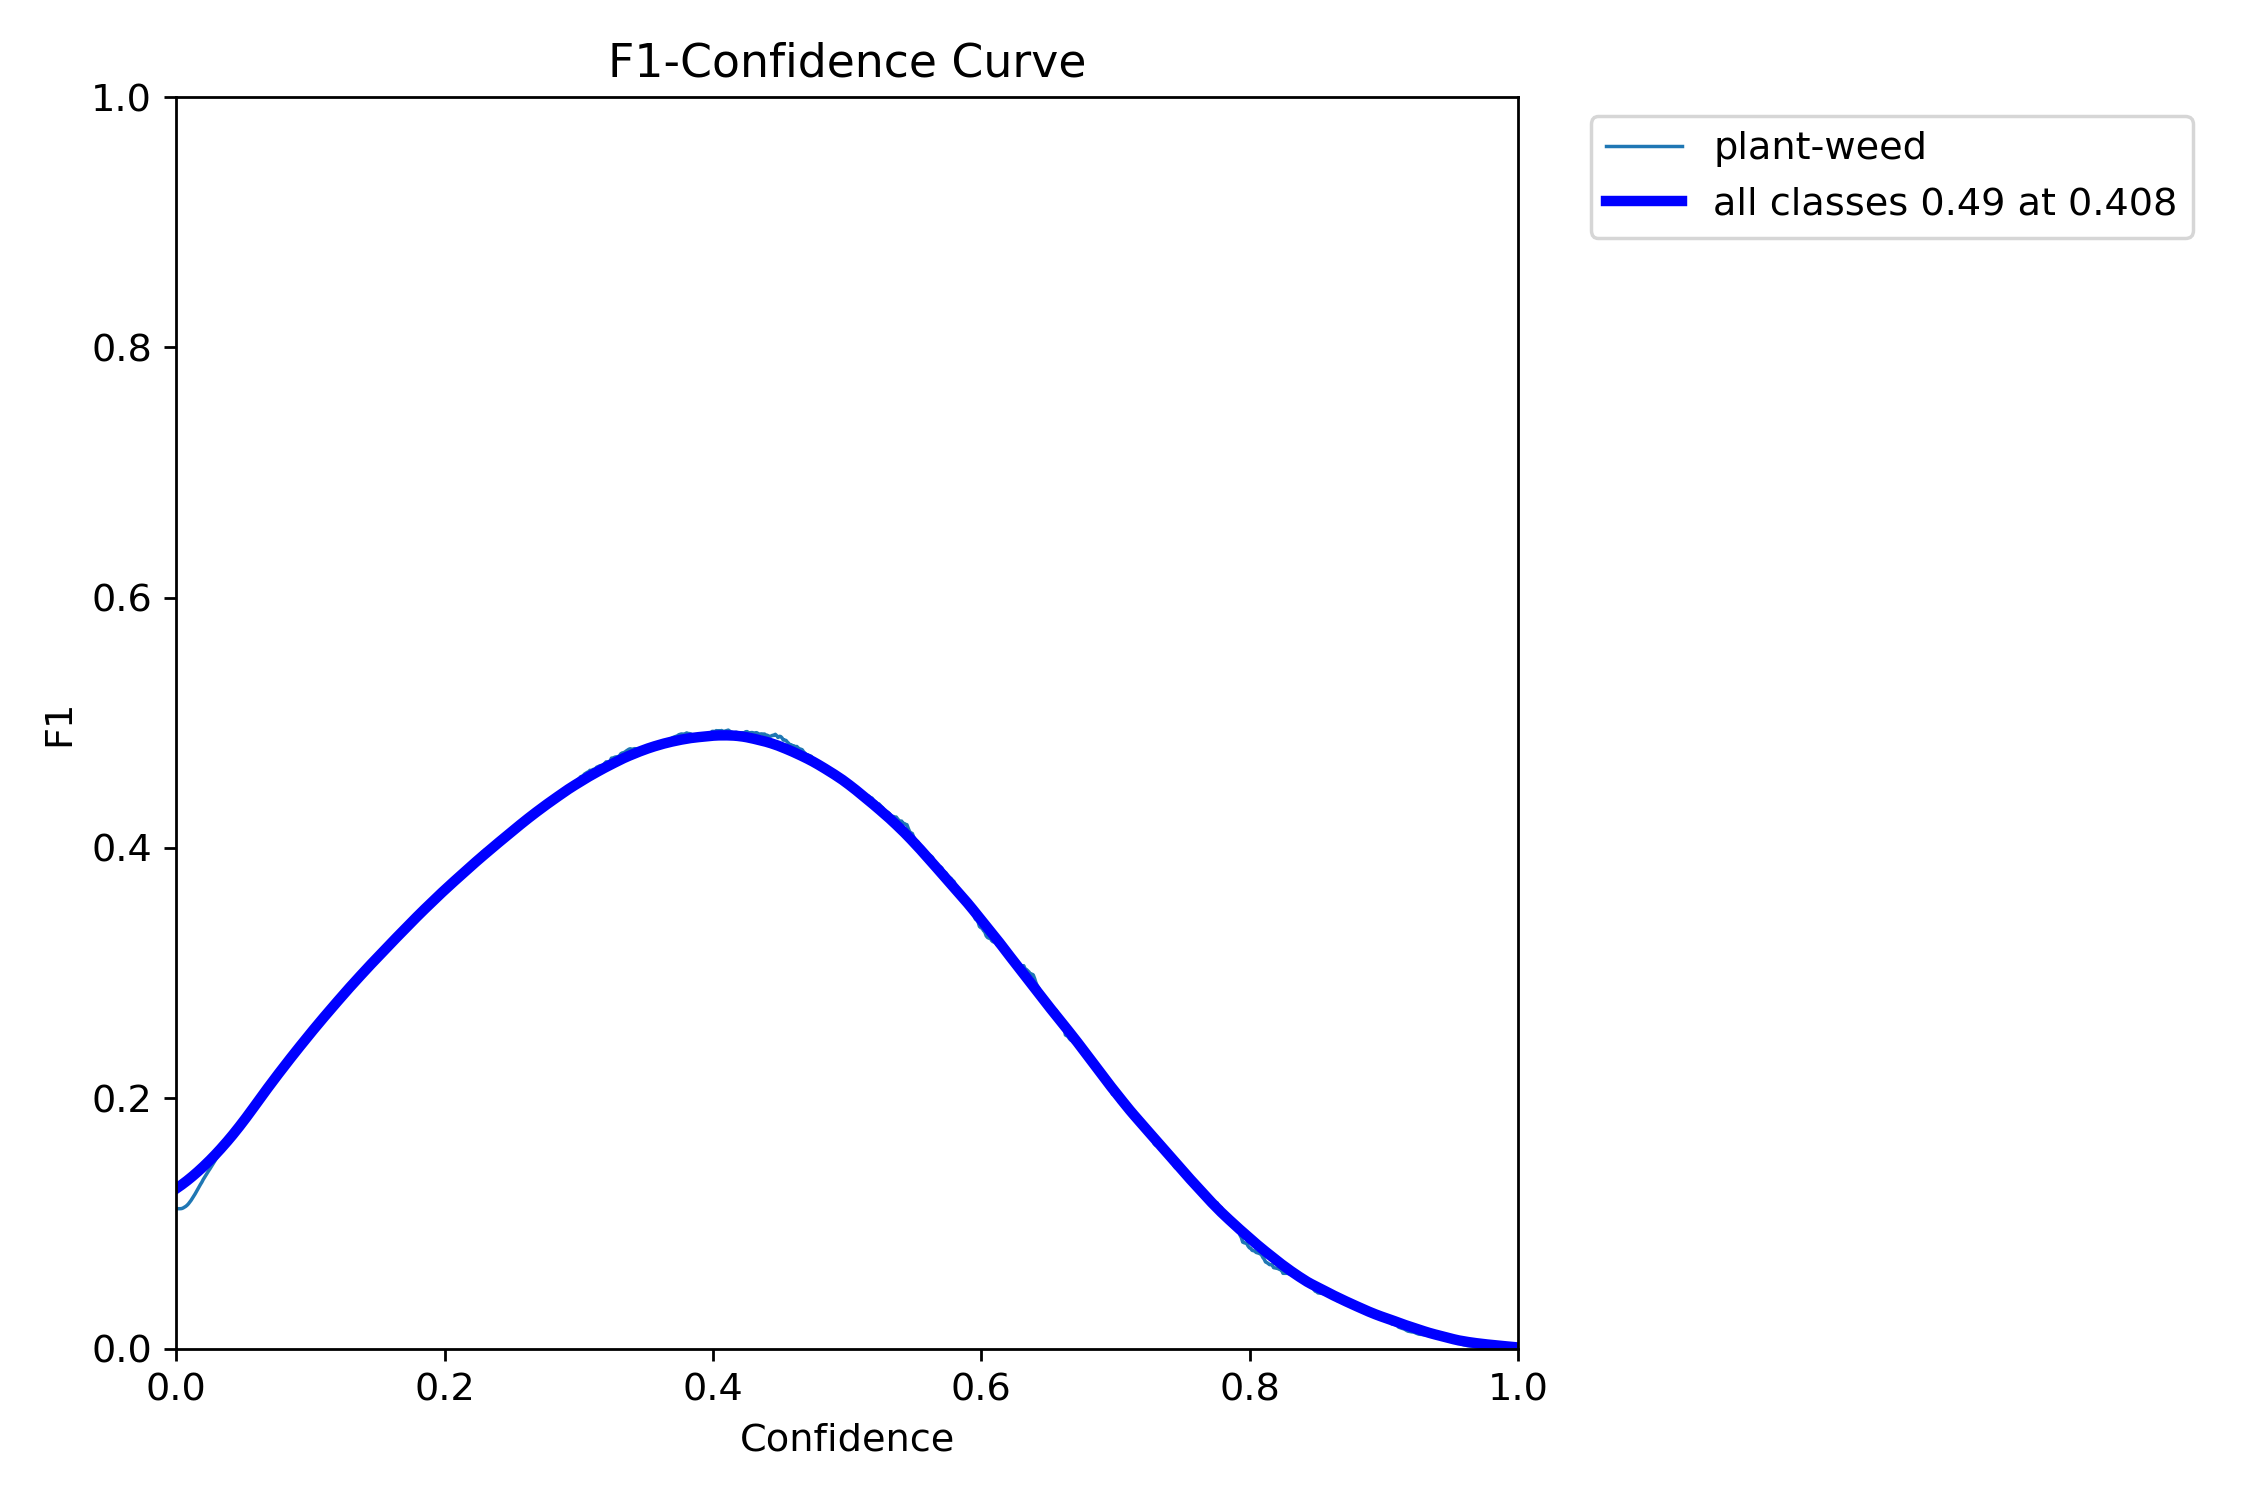

In [44]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

----

# References

## Experiment 42
### *YOLOv8 Mid | exGreen masked images*
Images created by applying exGreen mask

In [45]:
target_folder = f"docs/Experimentos/8 exGreen/1 set/"
change_directory(target_folder)

Current working directory: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Trabajo Final/Desarrollo/docs/Experimentos/8 exGreen/1 set
Project root updated to: ../../../../


In [46]:
folder = "runs/detect/train/"

In [47]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df3 = pd.read_csv(file_path)
df = df3.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
495,496,3676.77,1.31495,0.87788,1.17994,0.42951,0.32972,0.28148,0.07456,2.85499,1.59474,2.02232,0.000040,0.000040,0.000040
496,497,3683.95,1.25421,0.78826,1.14751,0.43930,0.32794,0.27890,0.07439,2.85892,1.59499,2.03044,0.000036,0.000036,0.000036
497,498,3690.87,1.21434,0.76537,1.11140,0.43709,0.32669,0.27692,0.07385,2.86392,1.59955,2.03596,0.000032,0.000032,0.000032
498,499,3698.09,1.31397,0.80350,1.17075,0.42931,0.32503,0.27524,0.07346,2.87043,1.60492,2.03819,0.000028,0.000028,0.000028
499,500,3704.97,1.31067,0.86389,1.21345,0.42797,0.32628,0.27380,0.07315,2.87260,1.60697,2.04185,0.000024,0.000024,0.000024


In [48]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 61.749 min


#### Best epoch

In [49]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
60,61,456.64,2.45698,1.89124,1.77849,0.41957,0.40722,0.35821,0.10947,2.38044,1.66311,1.55345,0.001762,0.001762,0.001762,61.7495


In [50]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print("Proceso de entrenamiento:")
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Proceso de entrenamiento:
Mejor época de entrenamiento 61 con mAP50 de 0.358


In [51]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [13]:
# Setting values from CM graph
TP = 1034
FP = 945
FN = 1375

In [8]:
# Confusion matrix
show_metrics(TP, FP, FN)

Total objects detected: 3354

Confusion matrix:
[ 30.83% , 28.18% ]
[ 41.00% , 0.00% ]

Metrics:
- Accuracy: 0.308
- Precision: 0.522
- Recall: 0.429
- F1 Score: 0.471
- F½ Score: 0.501
- G-mean: 0.474


### Graphs

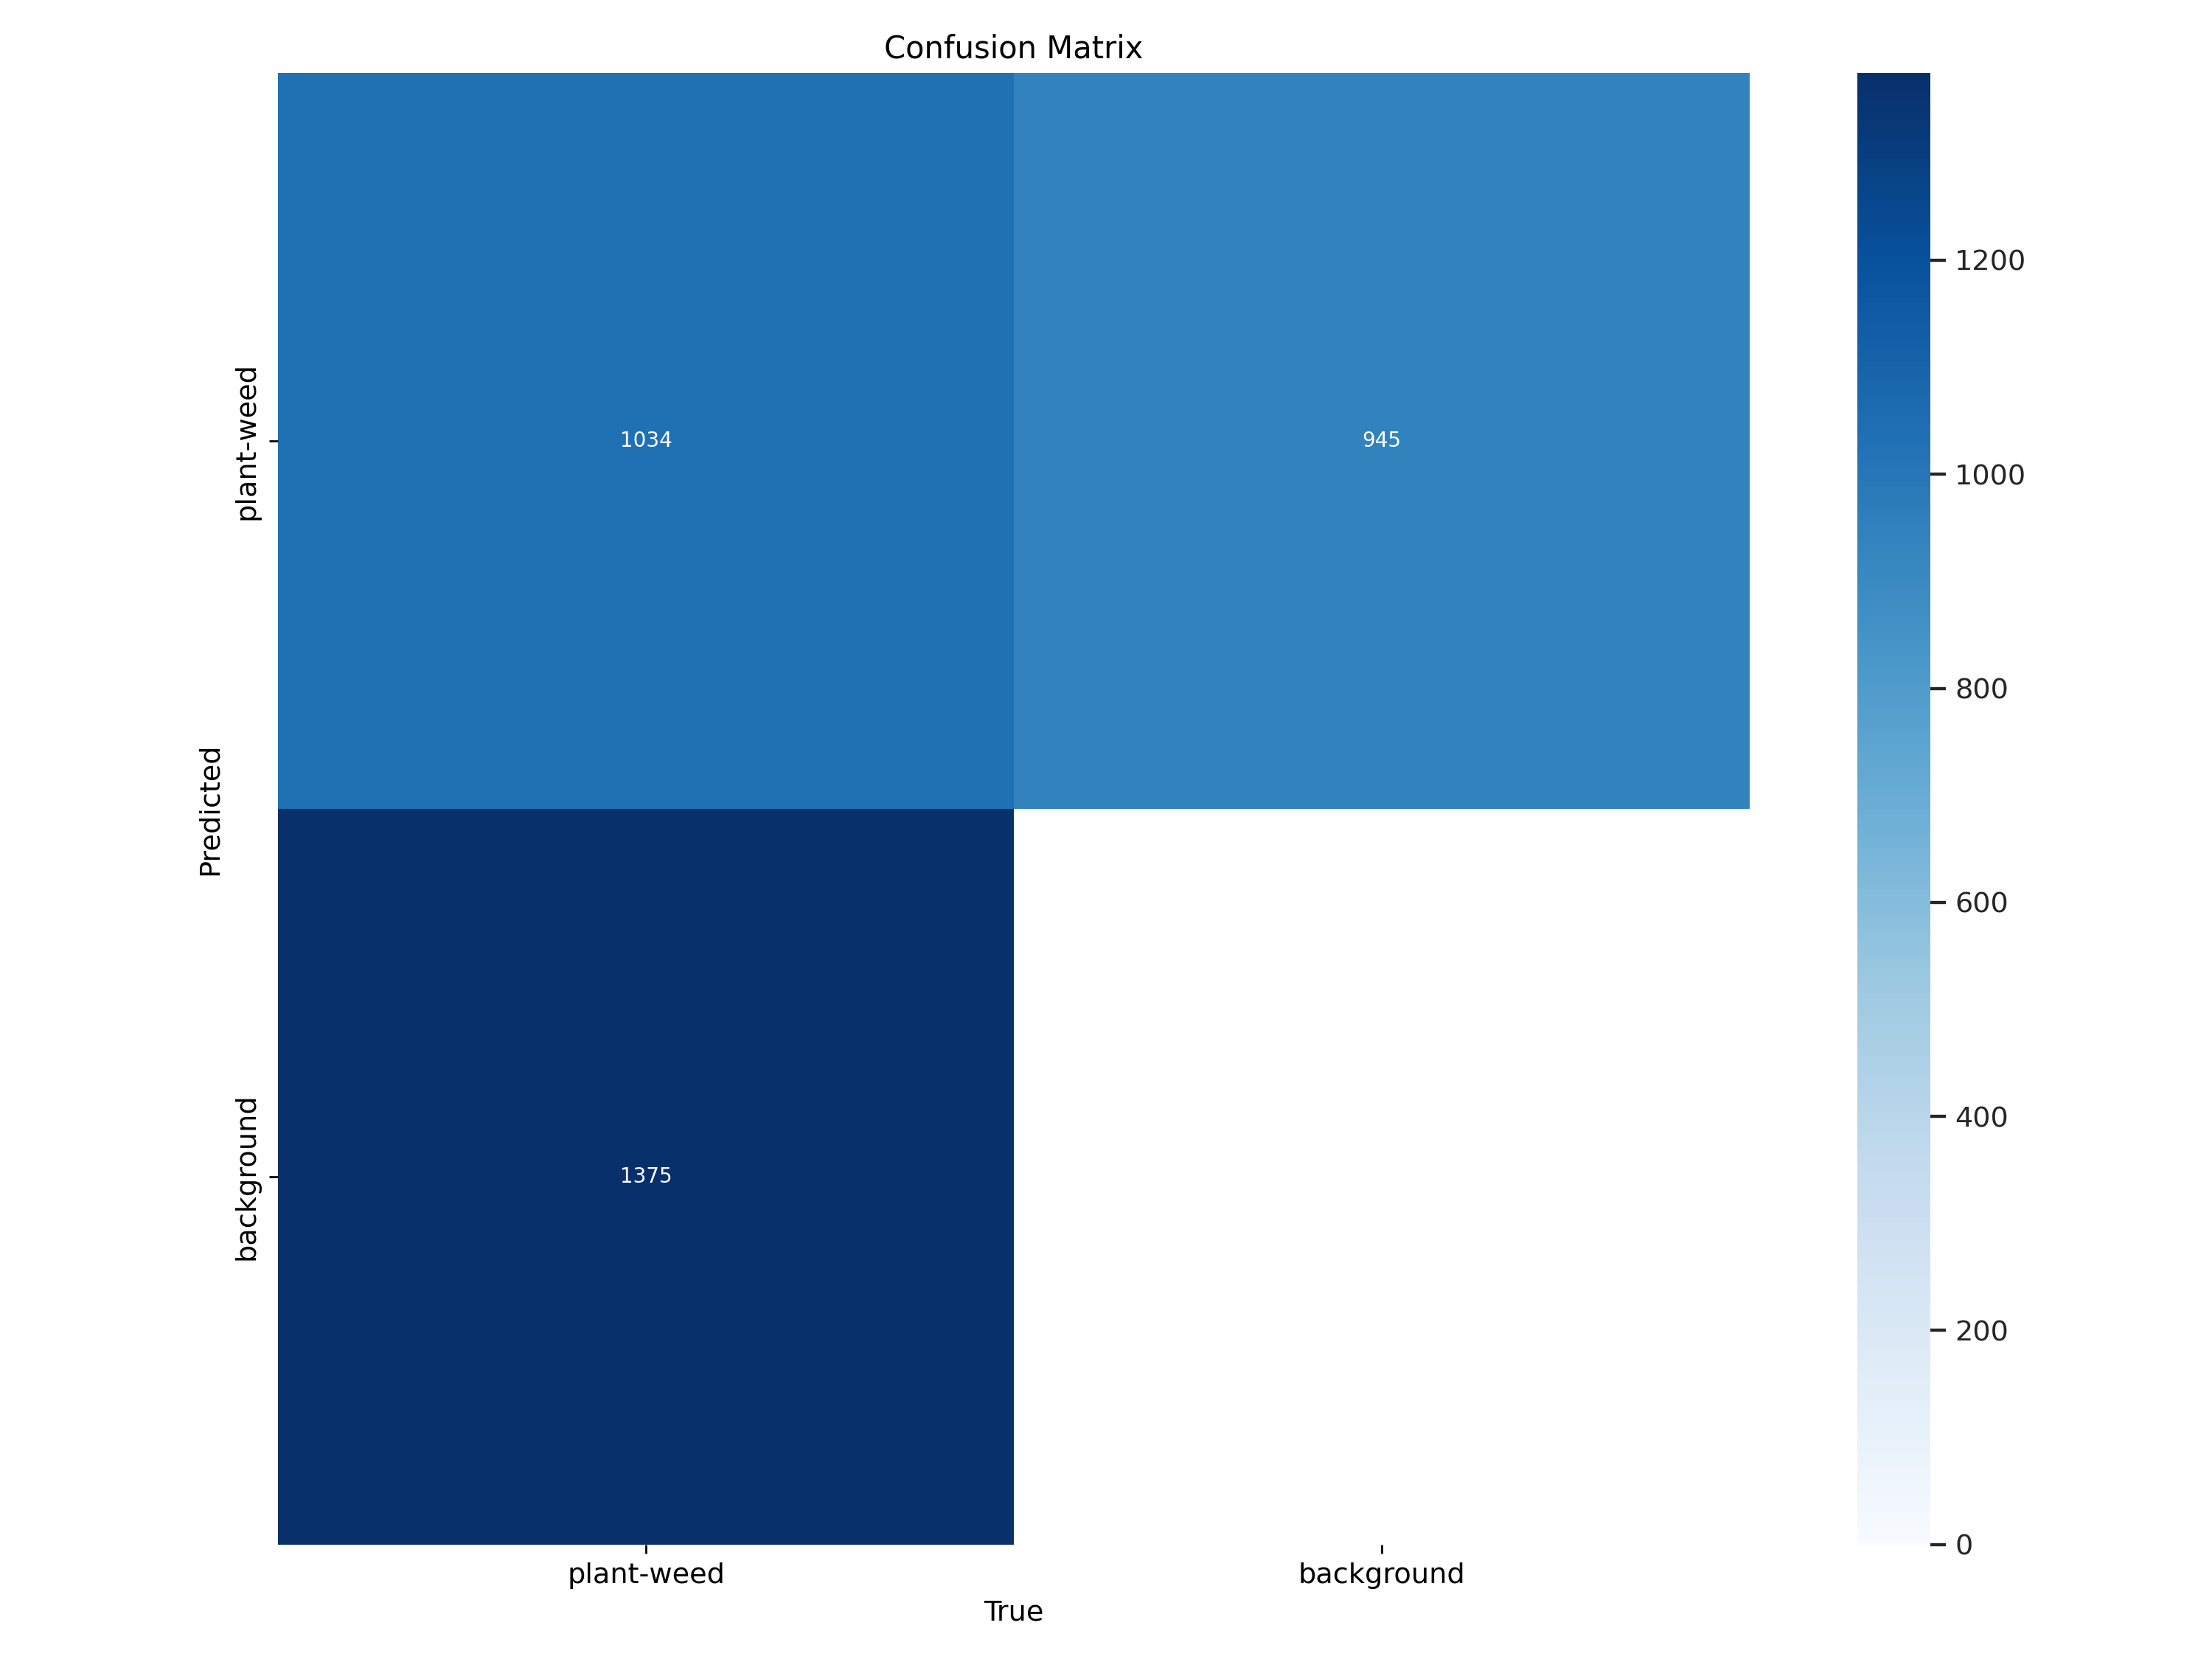

In [55]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

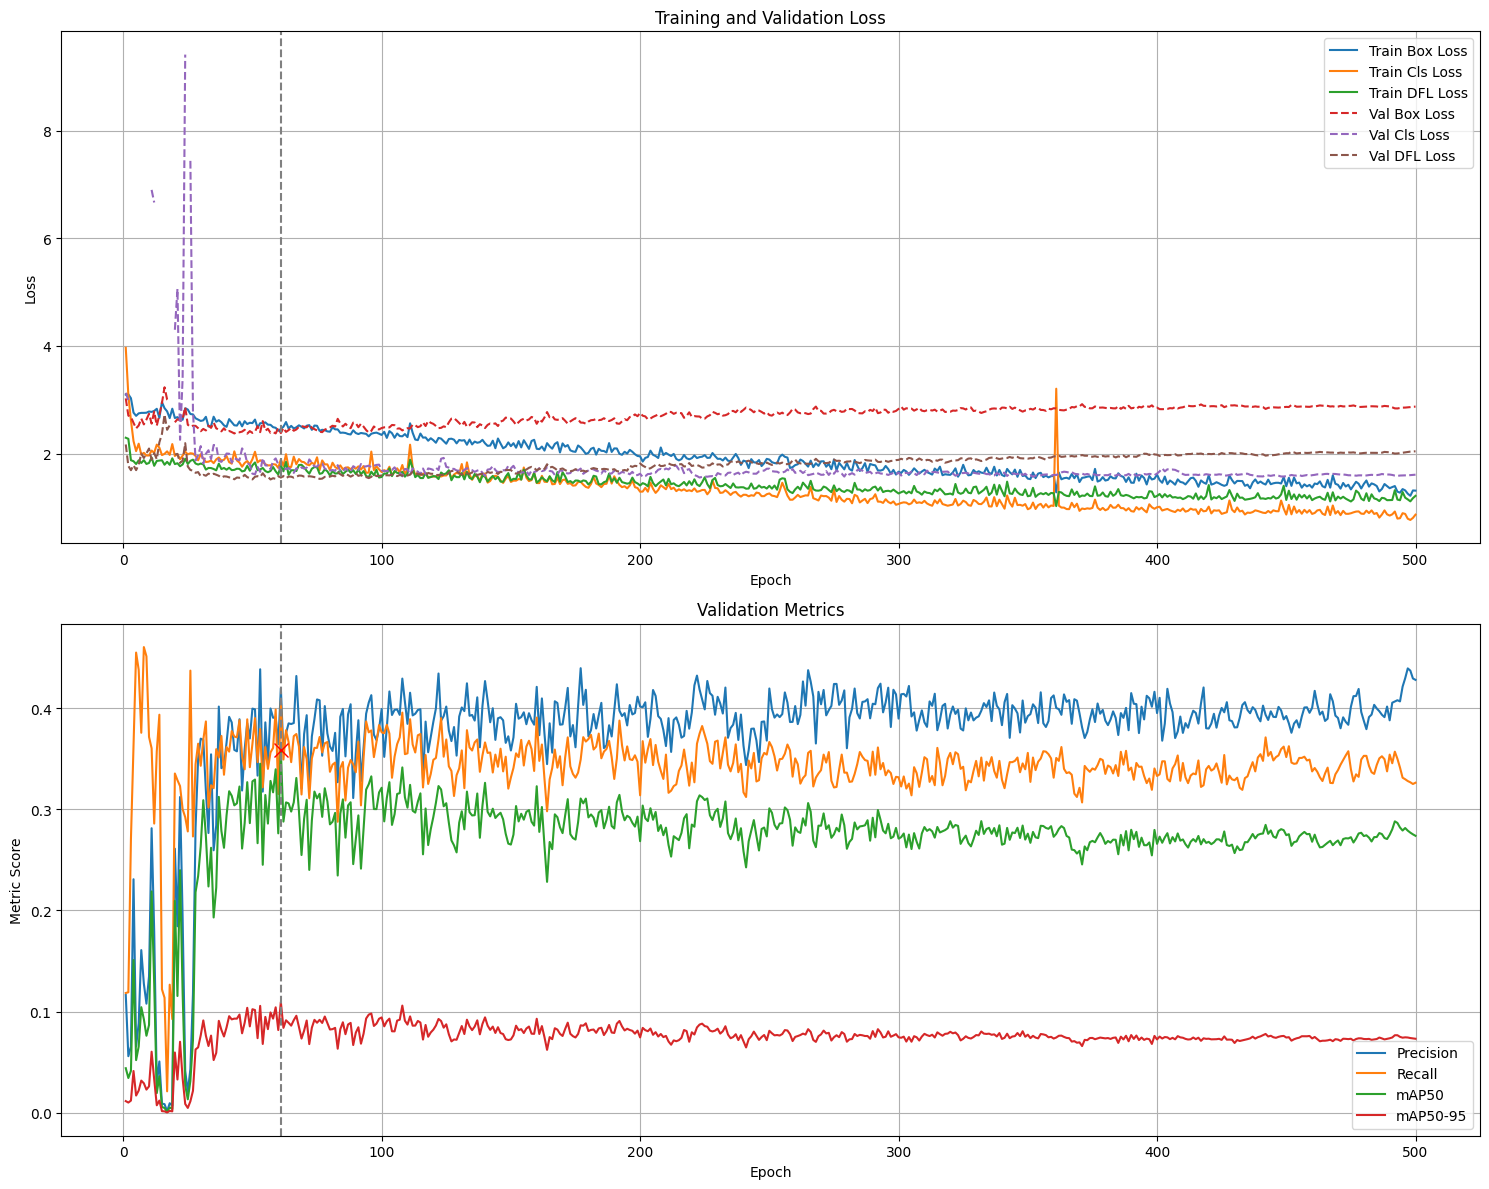

In [56]:
graph_training_metrics(df, epoch, graph="full")


_**NOTA:** `patience`=100 para EarlyStop_

In [57]:
graph_LrLoss_3D(df)

Validation set


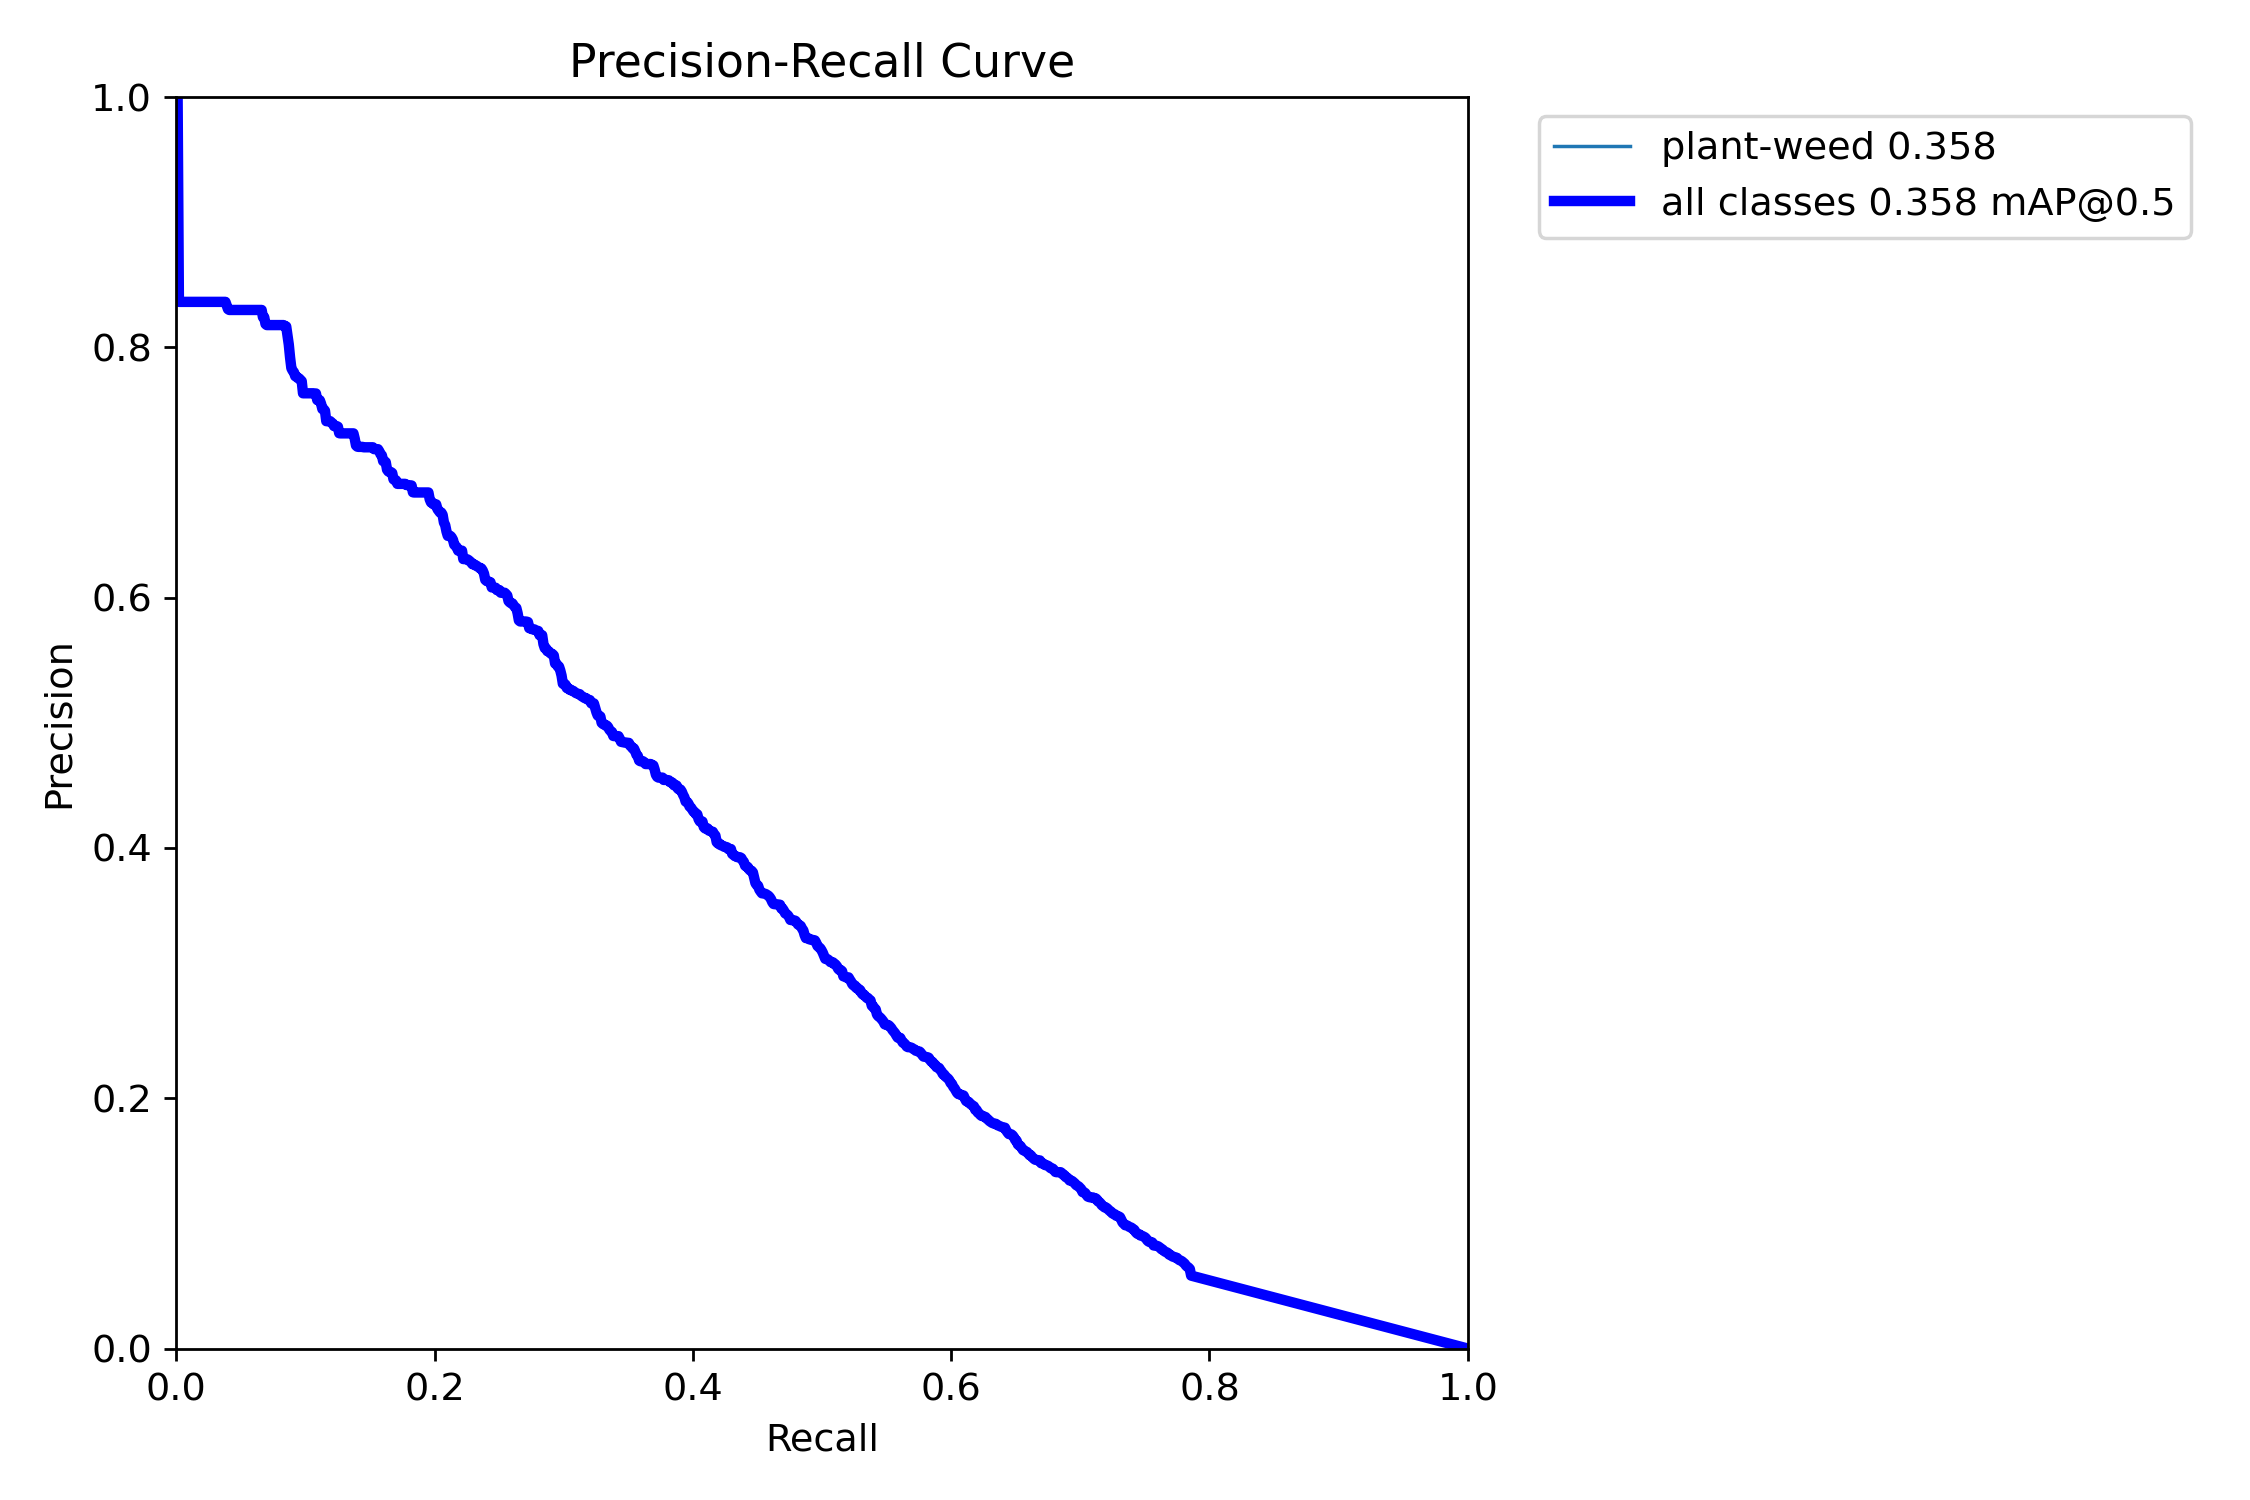

In [58]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

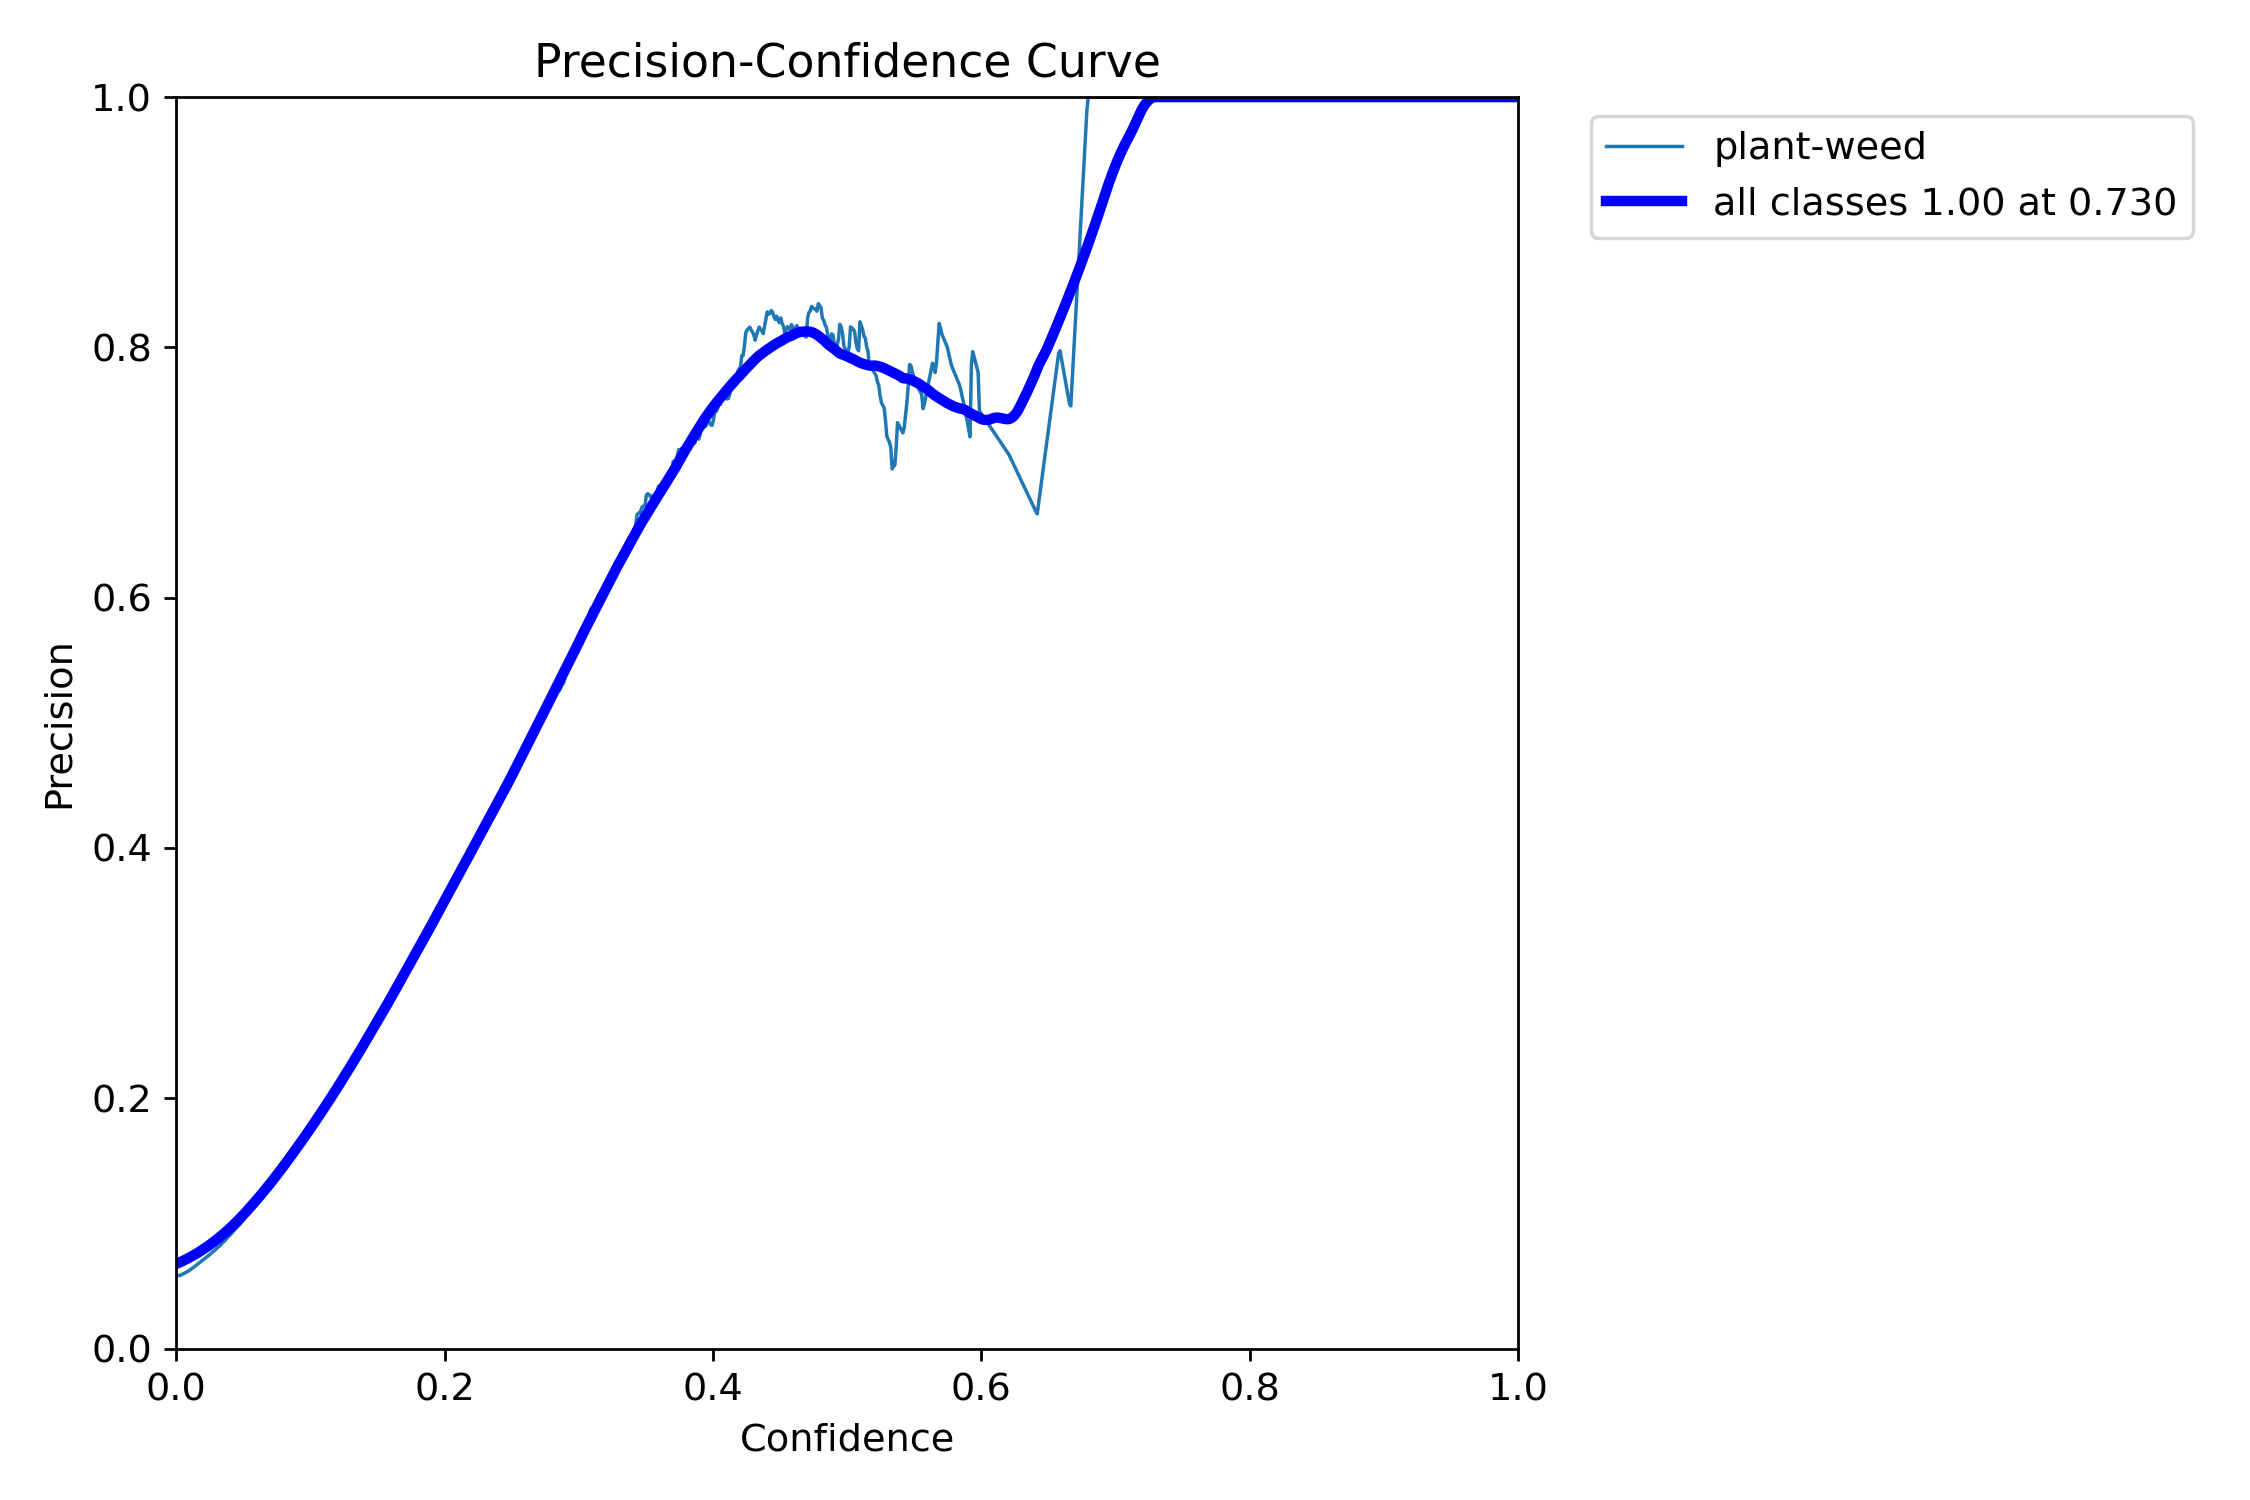

In [59]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

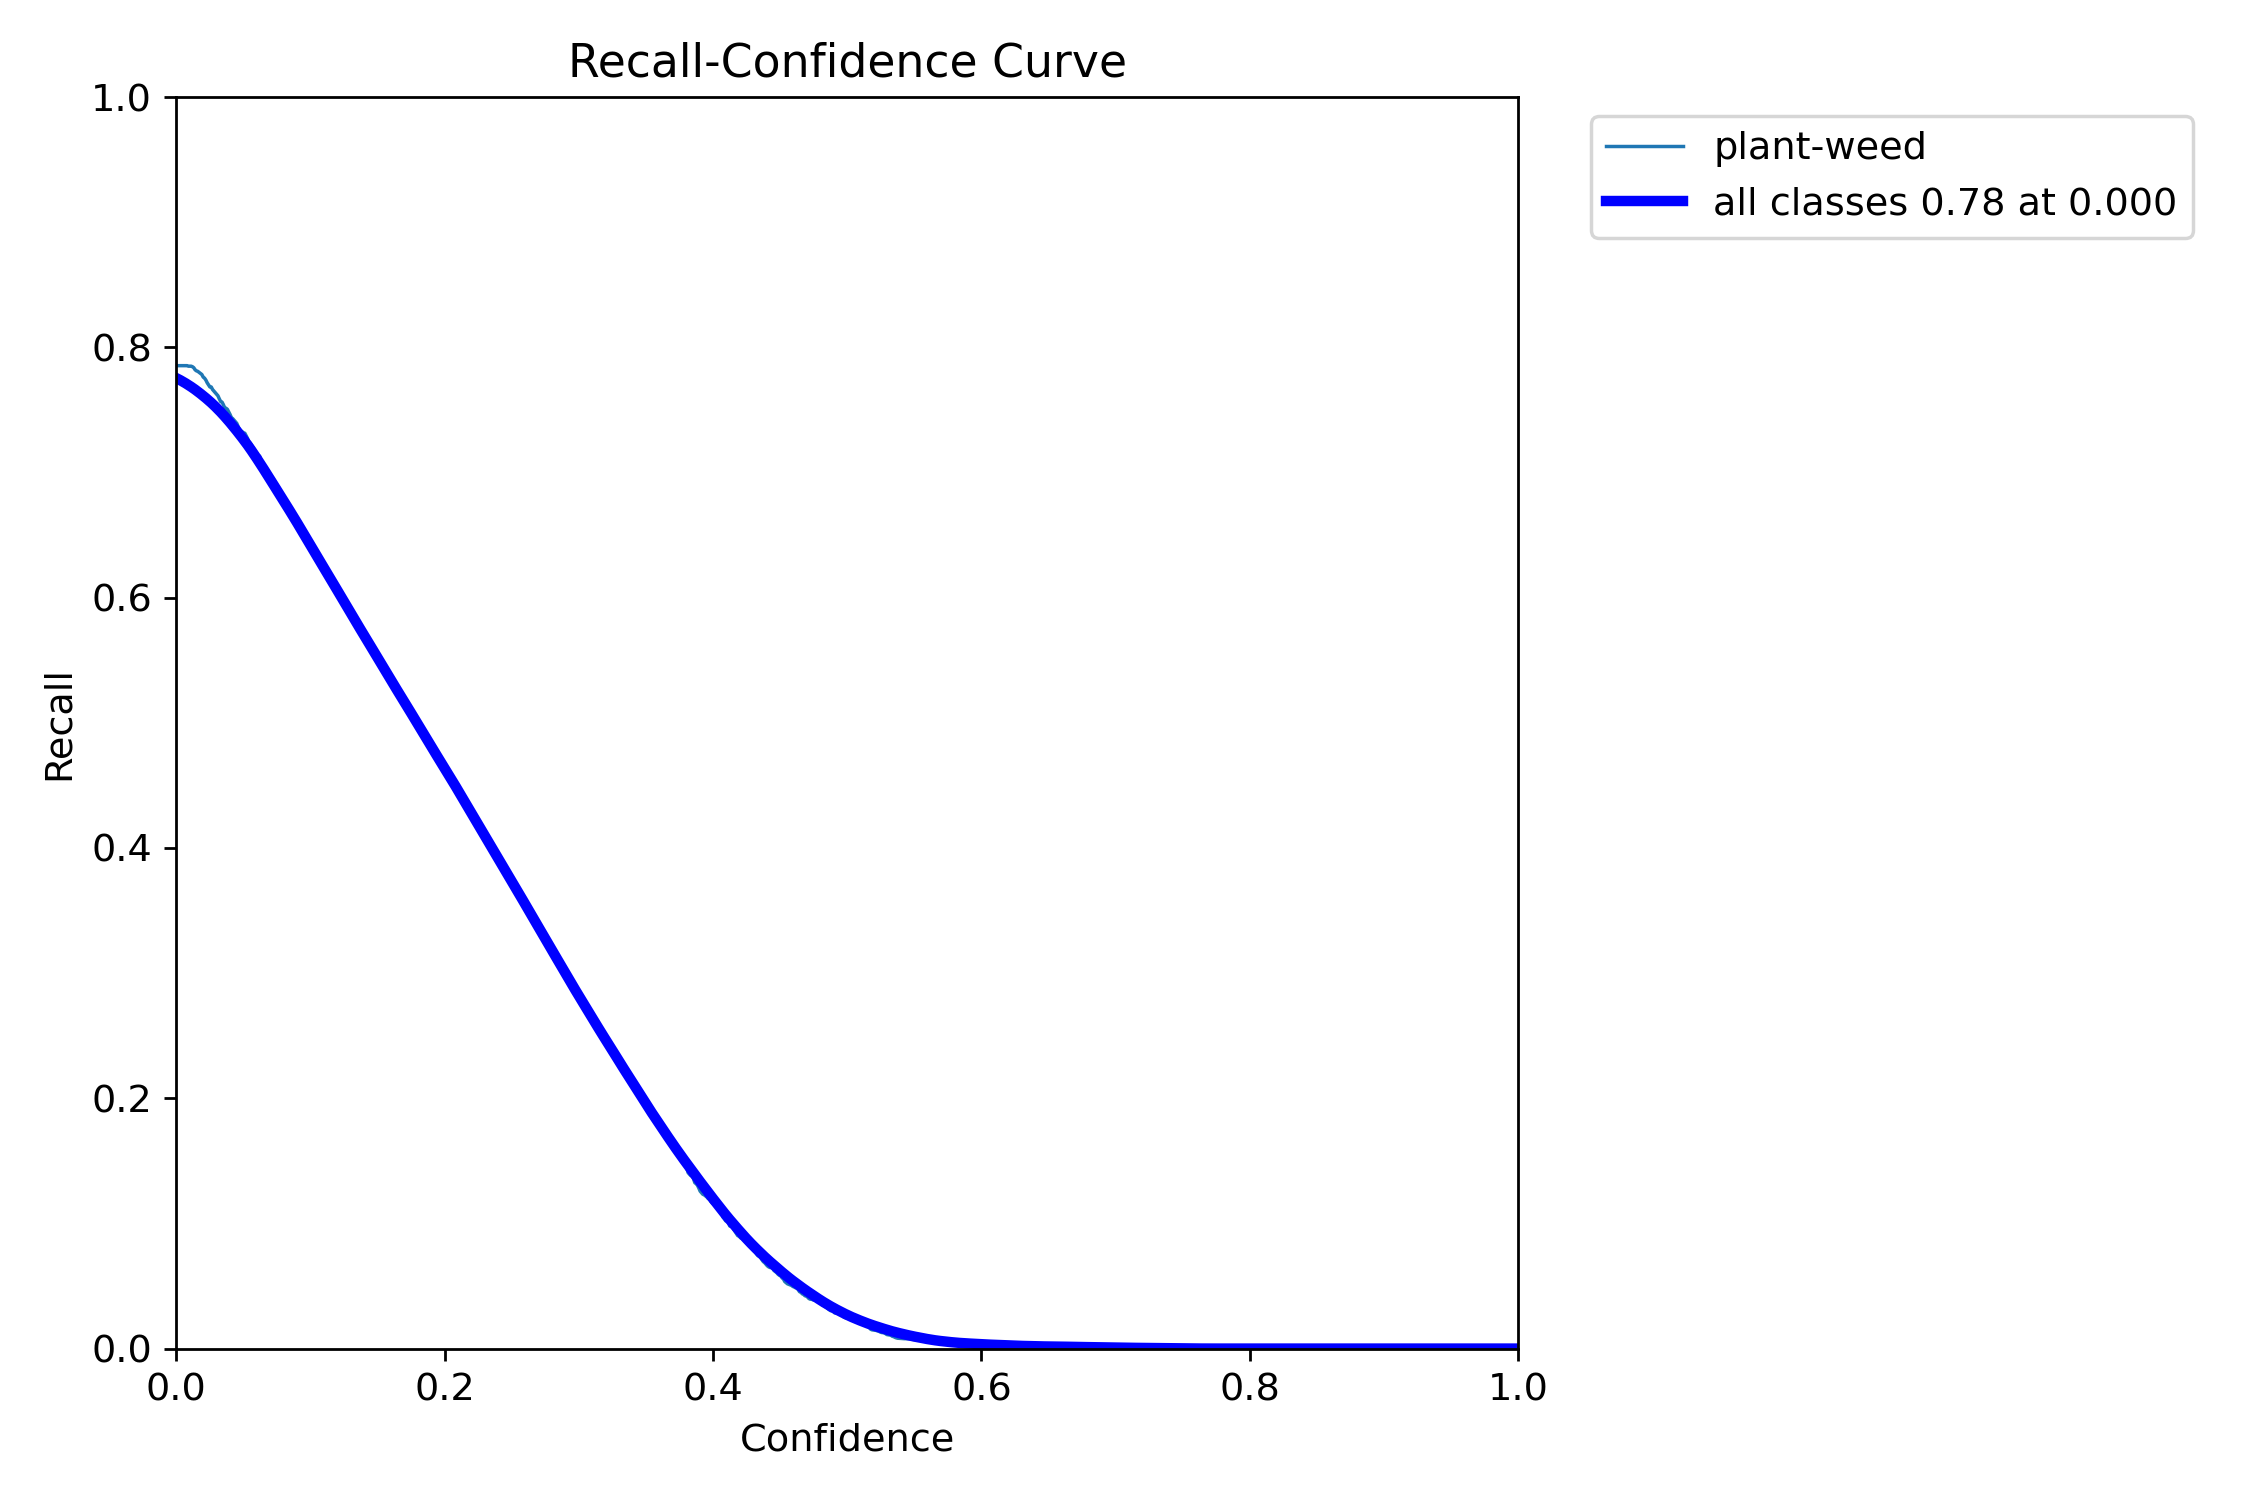

In [60]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

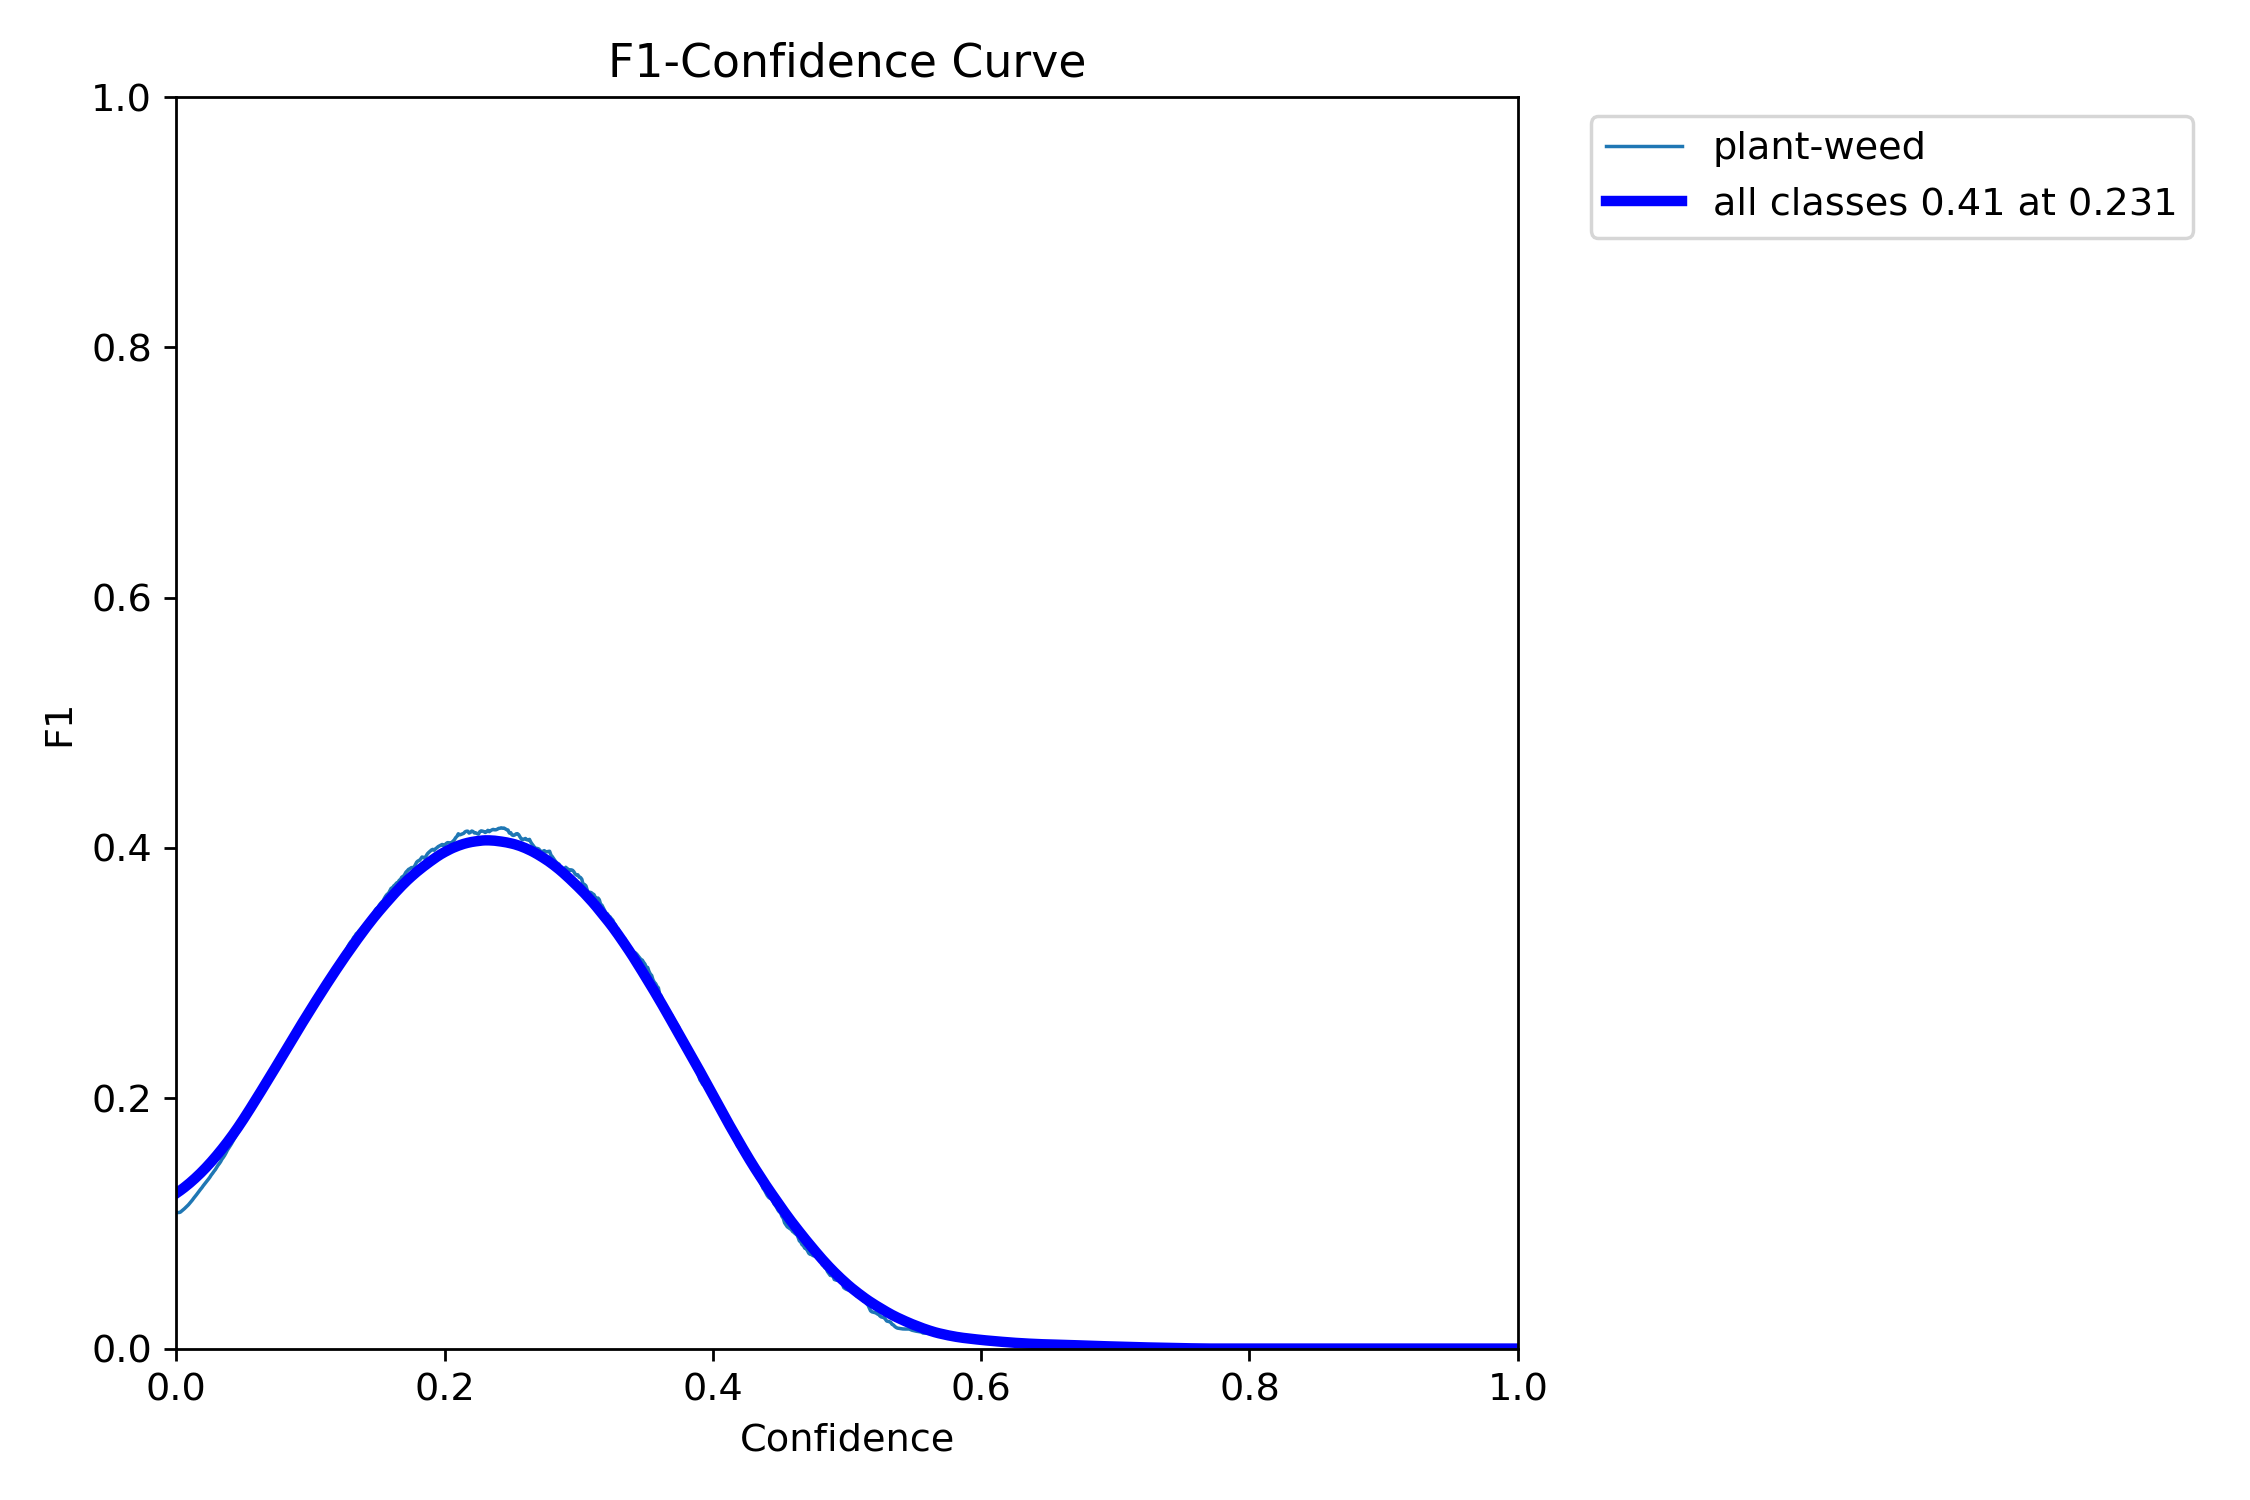

In [61]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

## Experiment 43
### *YOLOv8 Mid | False color images*
False color images are created by applying:
1. Excess Green to a grayscale image.
1. A 2-component PCA (to reduce dimensionality).
1. Combining these images as RGB channels.
1. Applying a Burn Blend between the resulting image and the original.

In [62]:
target_folder = f"docs/Experimentos/8 exGreen/1 set/"
change_directory(target_folder)

Current working directory: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Trabajo Final/Desarrollo/docs/Experimentos/8 exGreen/1 set
Project root updated to: ../../../../


In [63]:
folder = "runs/detect/train2/"

In [64]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df4 = pd.read_csv(file_path)
df = df4.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
495,496,3592.31,0.91752,0.50961,0.96853,0.53225,0.45039,0.40824,0.13097,2.53027,1.48107,1.87429,0.000040,0.000040,0.000040
496,497,3600.03,0.86566,0.49453,0.94233,0.53102,0.45330,0.40904,0.13063,2.53219,1.48580,1.87544,0.000036,0.000036,0.000036
497,498,3606.66,0.85317,0.48329,0.92920,0.52783,0.45477,0.40810,0.13087,2.53106,1.48297,1.87517,0.000032,0.000032,0.000032
498,499,3614.24,0.95018,0.51381,0.98645,0.52978,0.45621,0.41045,0.13101,2.53141,1.48606,1.87813,0.000028,0.000028,0.000028
499,500,3620.90,0.97067,0.55663,1.02539,0.52760,0.45496,0.40874,0.13100,2.53102,1.49032,1.87983,0.000024,0.000024,0.000024


In [65]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 60.348 min


#### Best epoch

In [66]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
53,54,398.282,1.99676,1.25836,1.45897,0.51745,0.47406,0.44565,0.14513,2.32588,1.75765,1.53881,0.00179,0.00179,0.00179,60.348333


In [67]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print("Proceso de entrenamiento:")
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Proceso de entrenamiento:
Mejor época de entrenamiento 54 con mAP50 de 0.446


In [68]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [12]:
# Setting values from CM graph
TP = 1642
FP = 3034
FN = 767

In [11]:
# Confusion matrix
show_metrics(TP, FP, FN)

Total objects detected: 5443

Confusion matrix:
[ 30.17% , 55.74% ]
[ 14.09% , 0.00% ]

Metrics:
- Accuracy: 0.302
- Precision: 0.351
- Recall: 0.682
- F1 Score: 0.464
- F½ Score: 0.389
- G-mean: 0.489


### Graphs

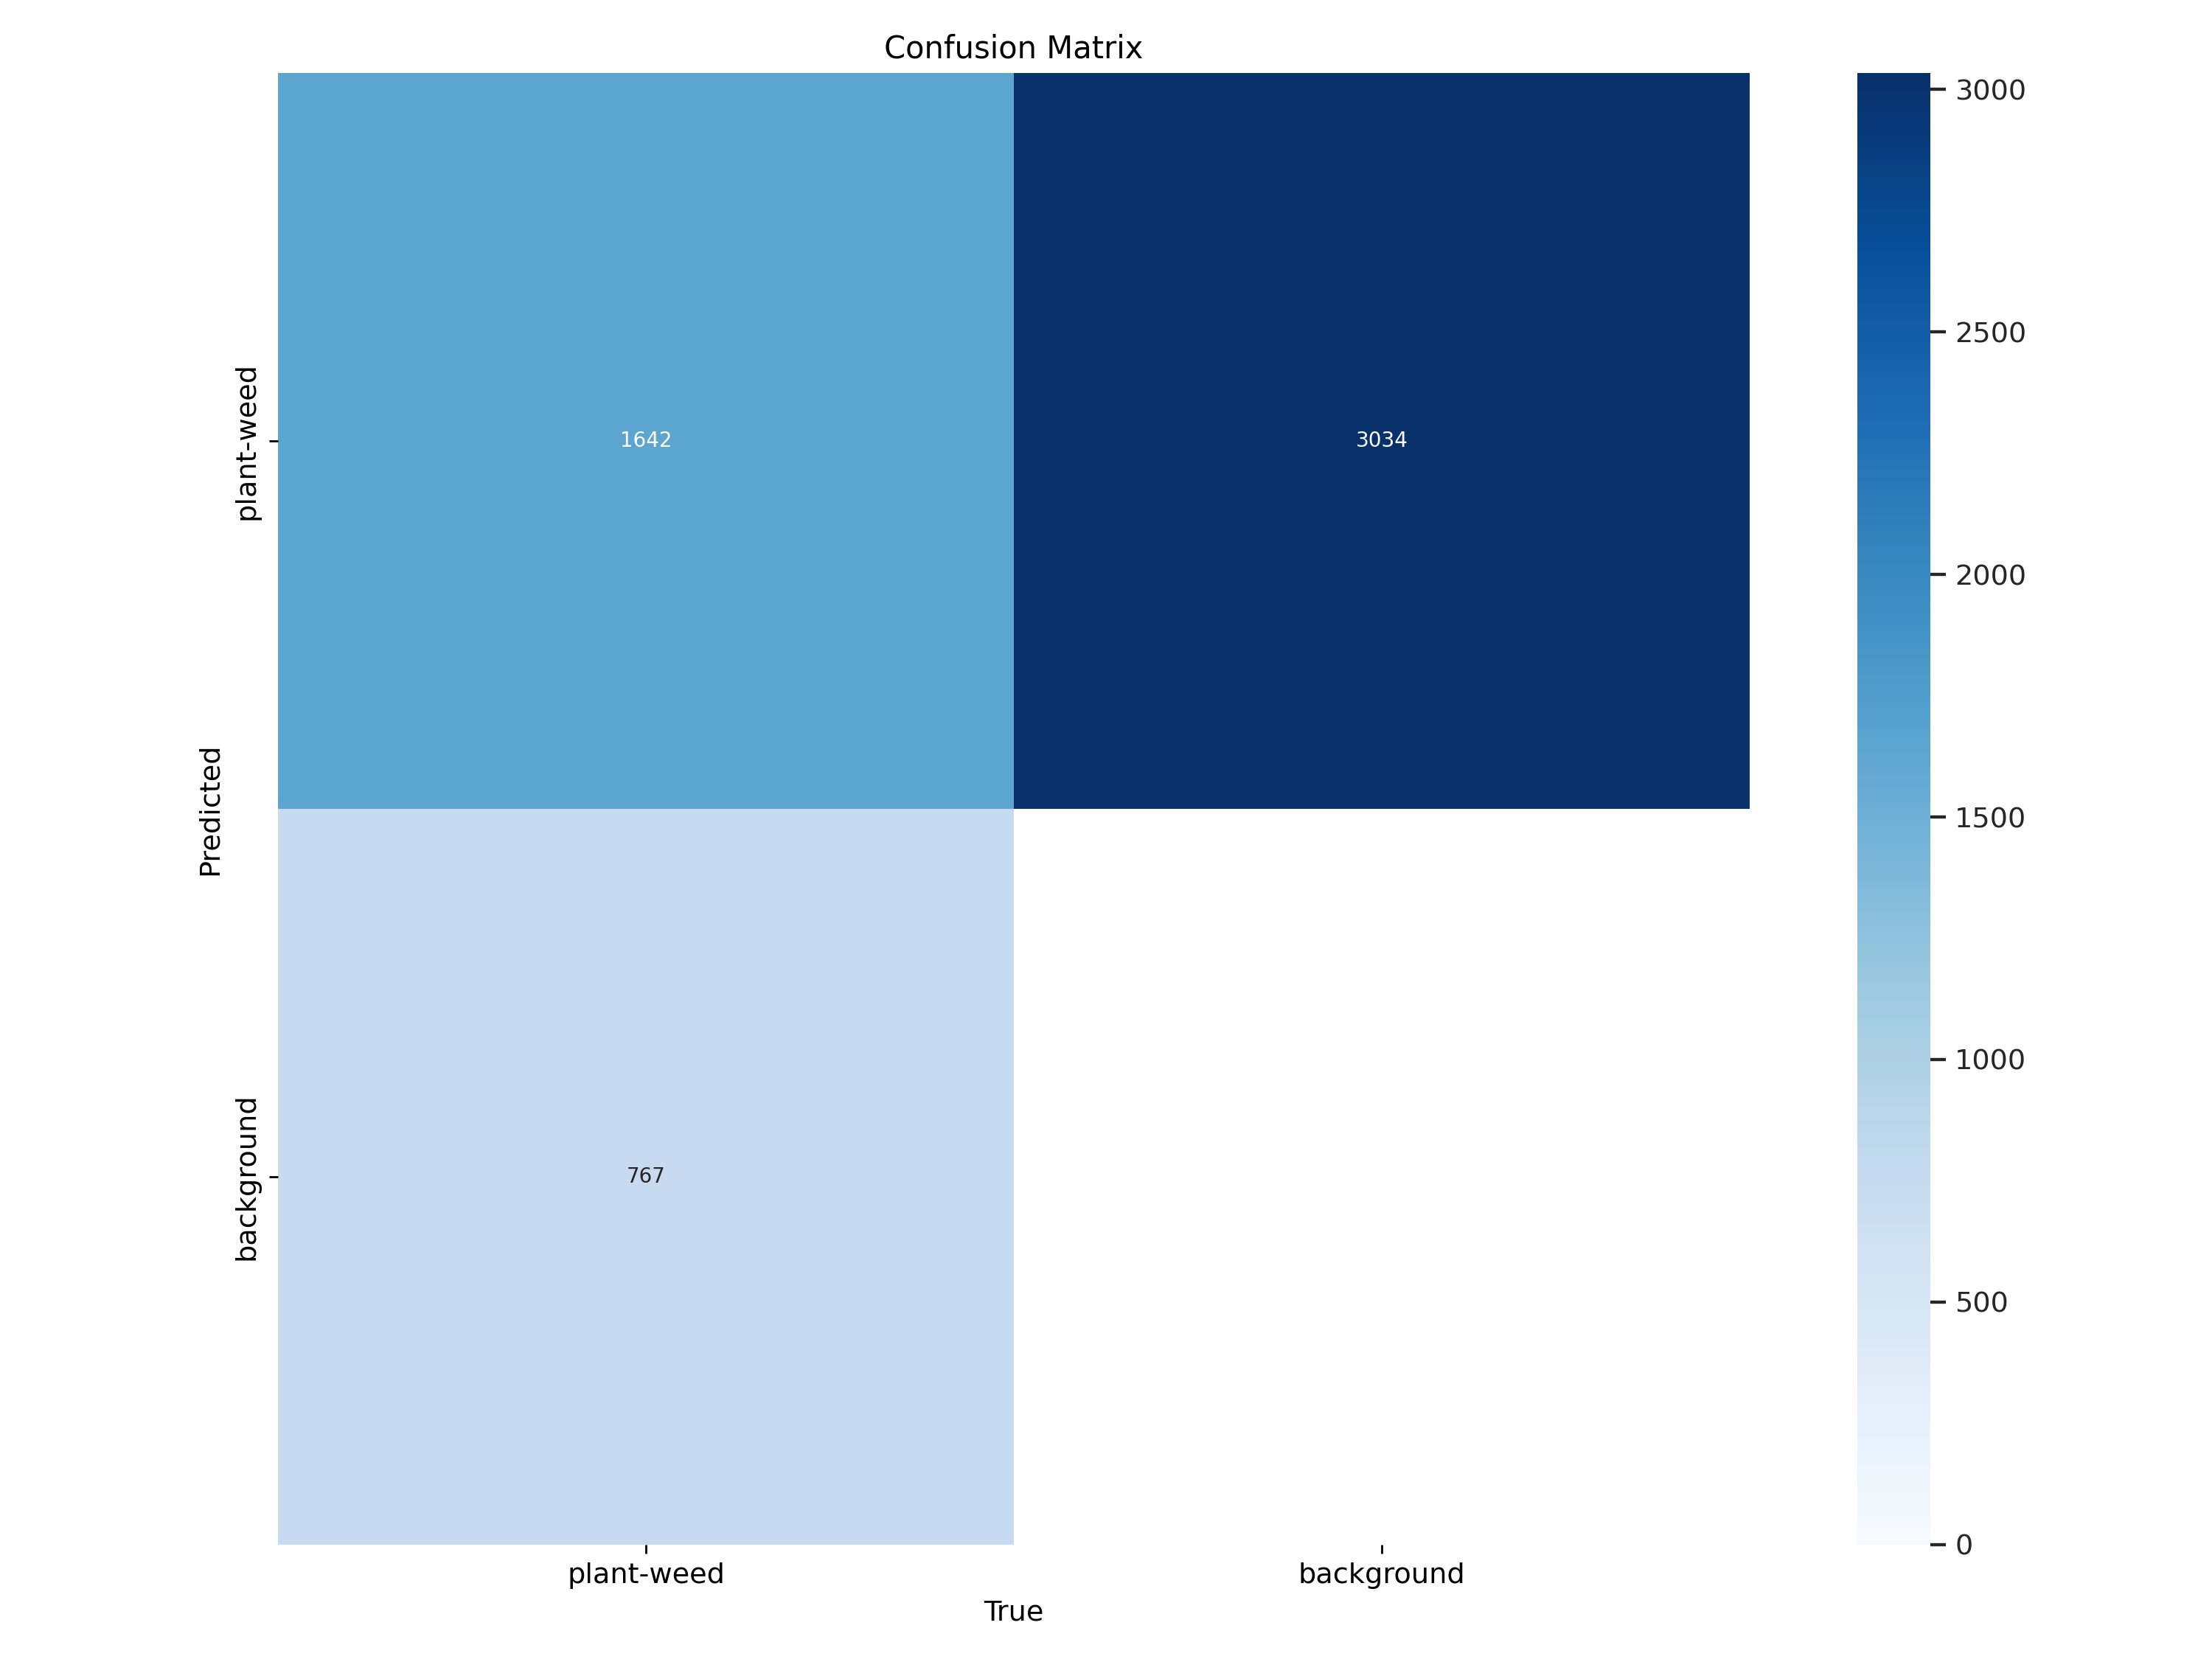

In [72]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

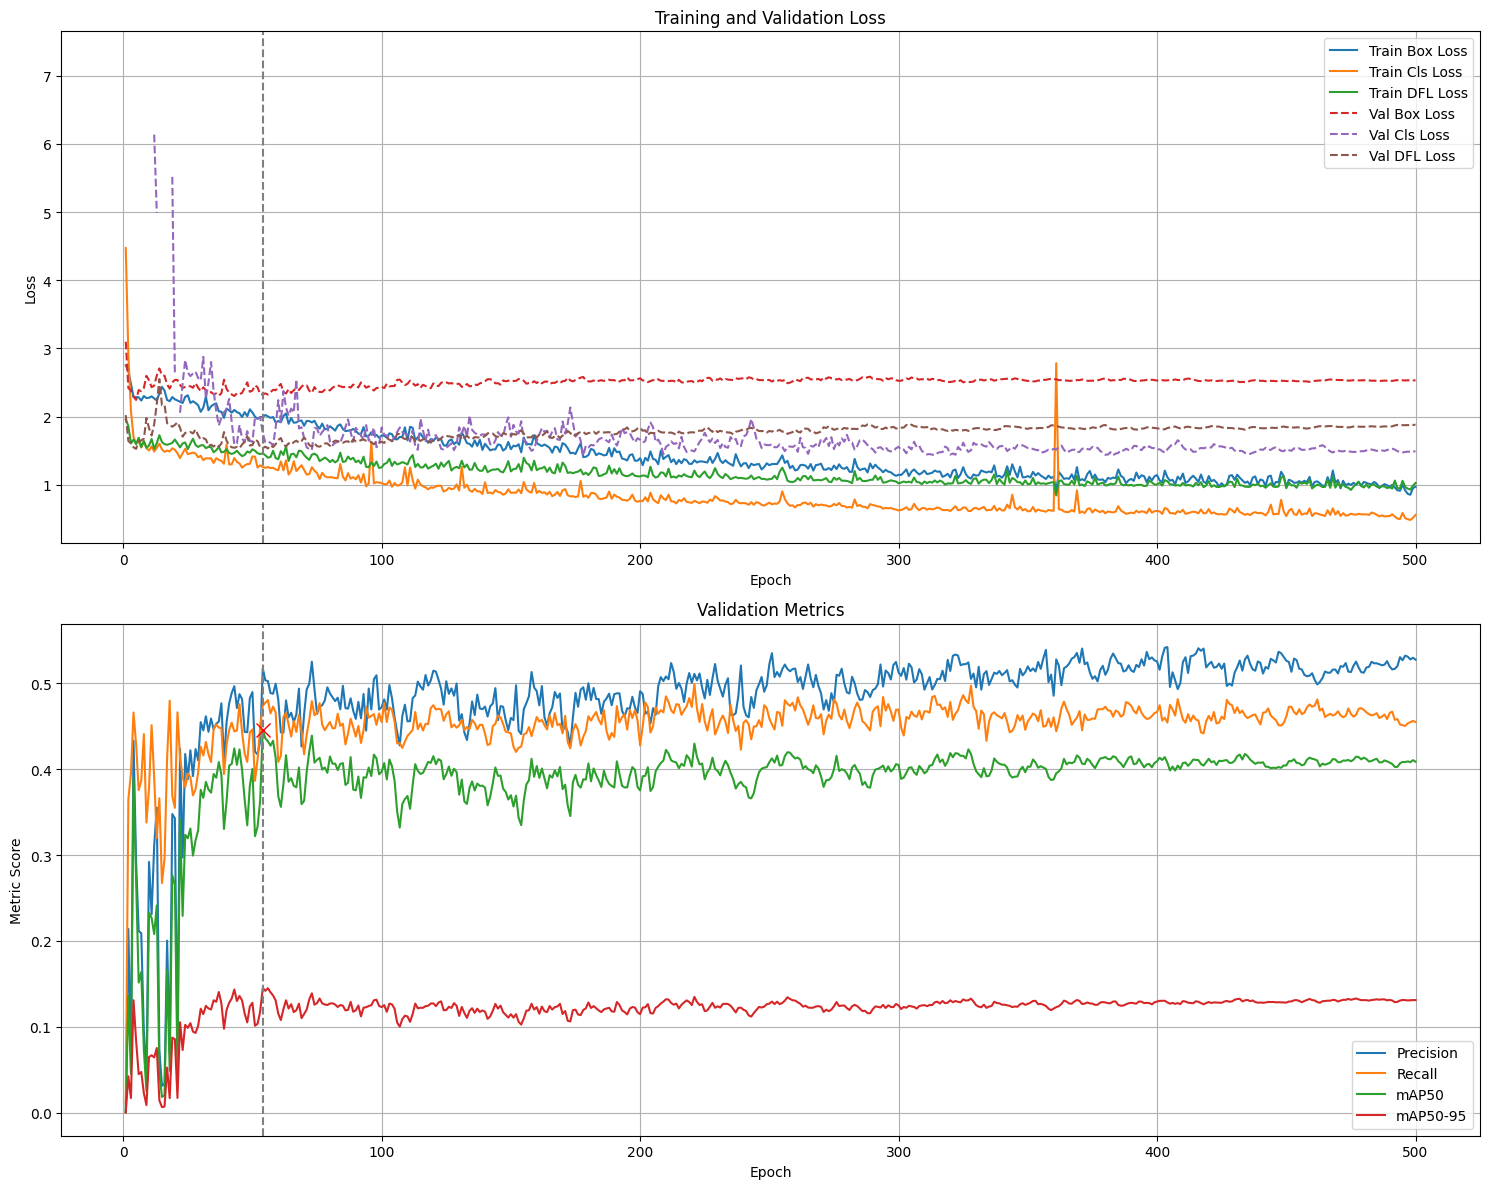

In [73]:
graph_training_metrics(df, epoch, graph="full")


_**NOTA:** `patience`=100 para EarlyStop_

In [74]:
graph_LrLoss_3D(df)

Validation set


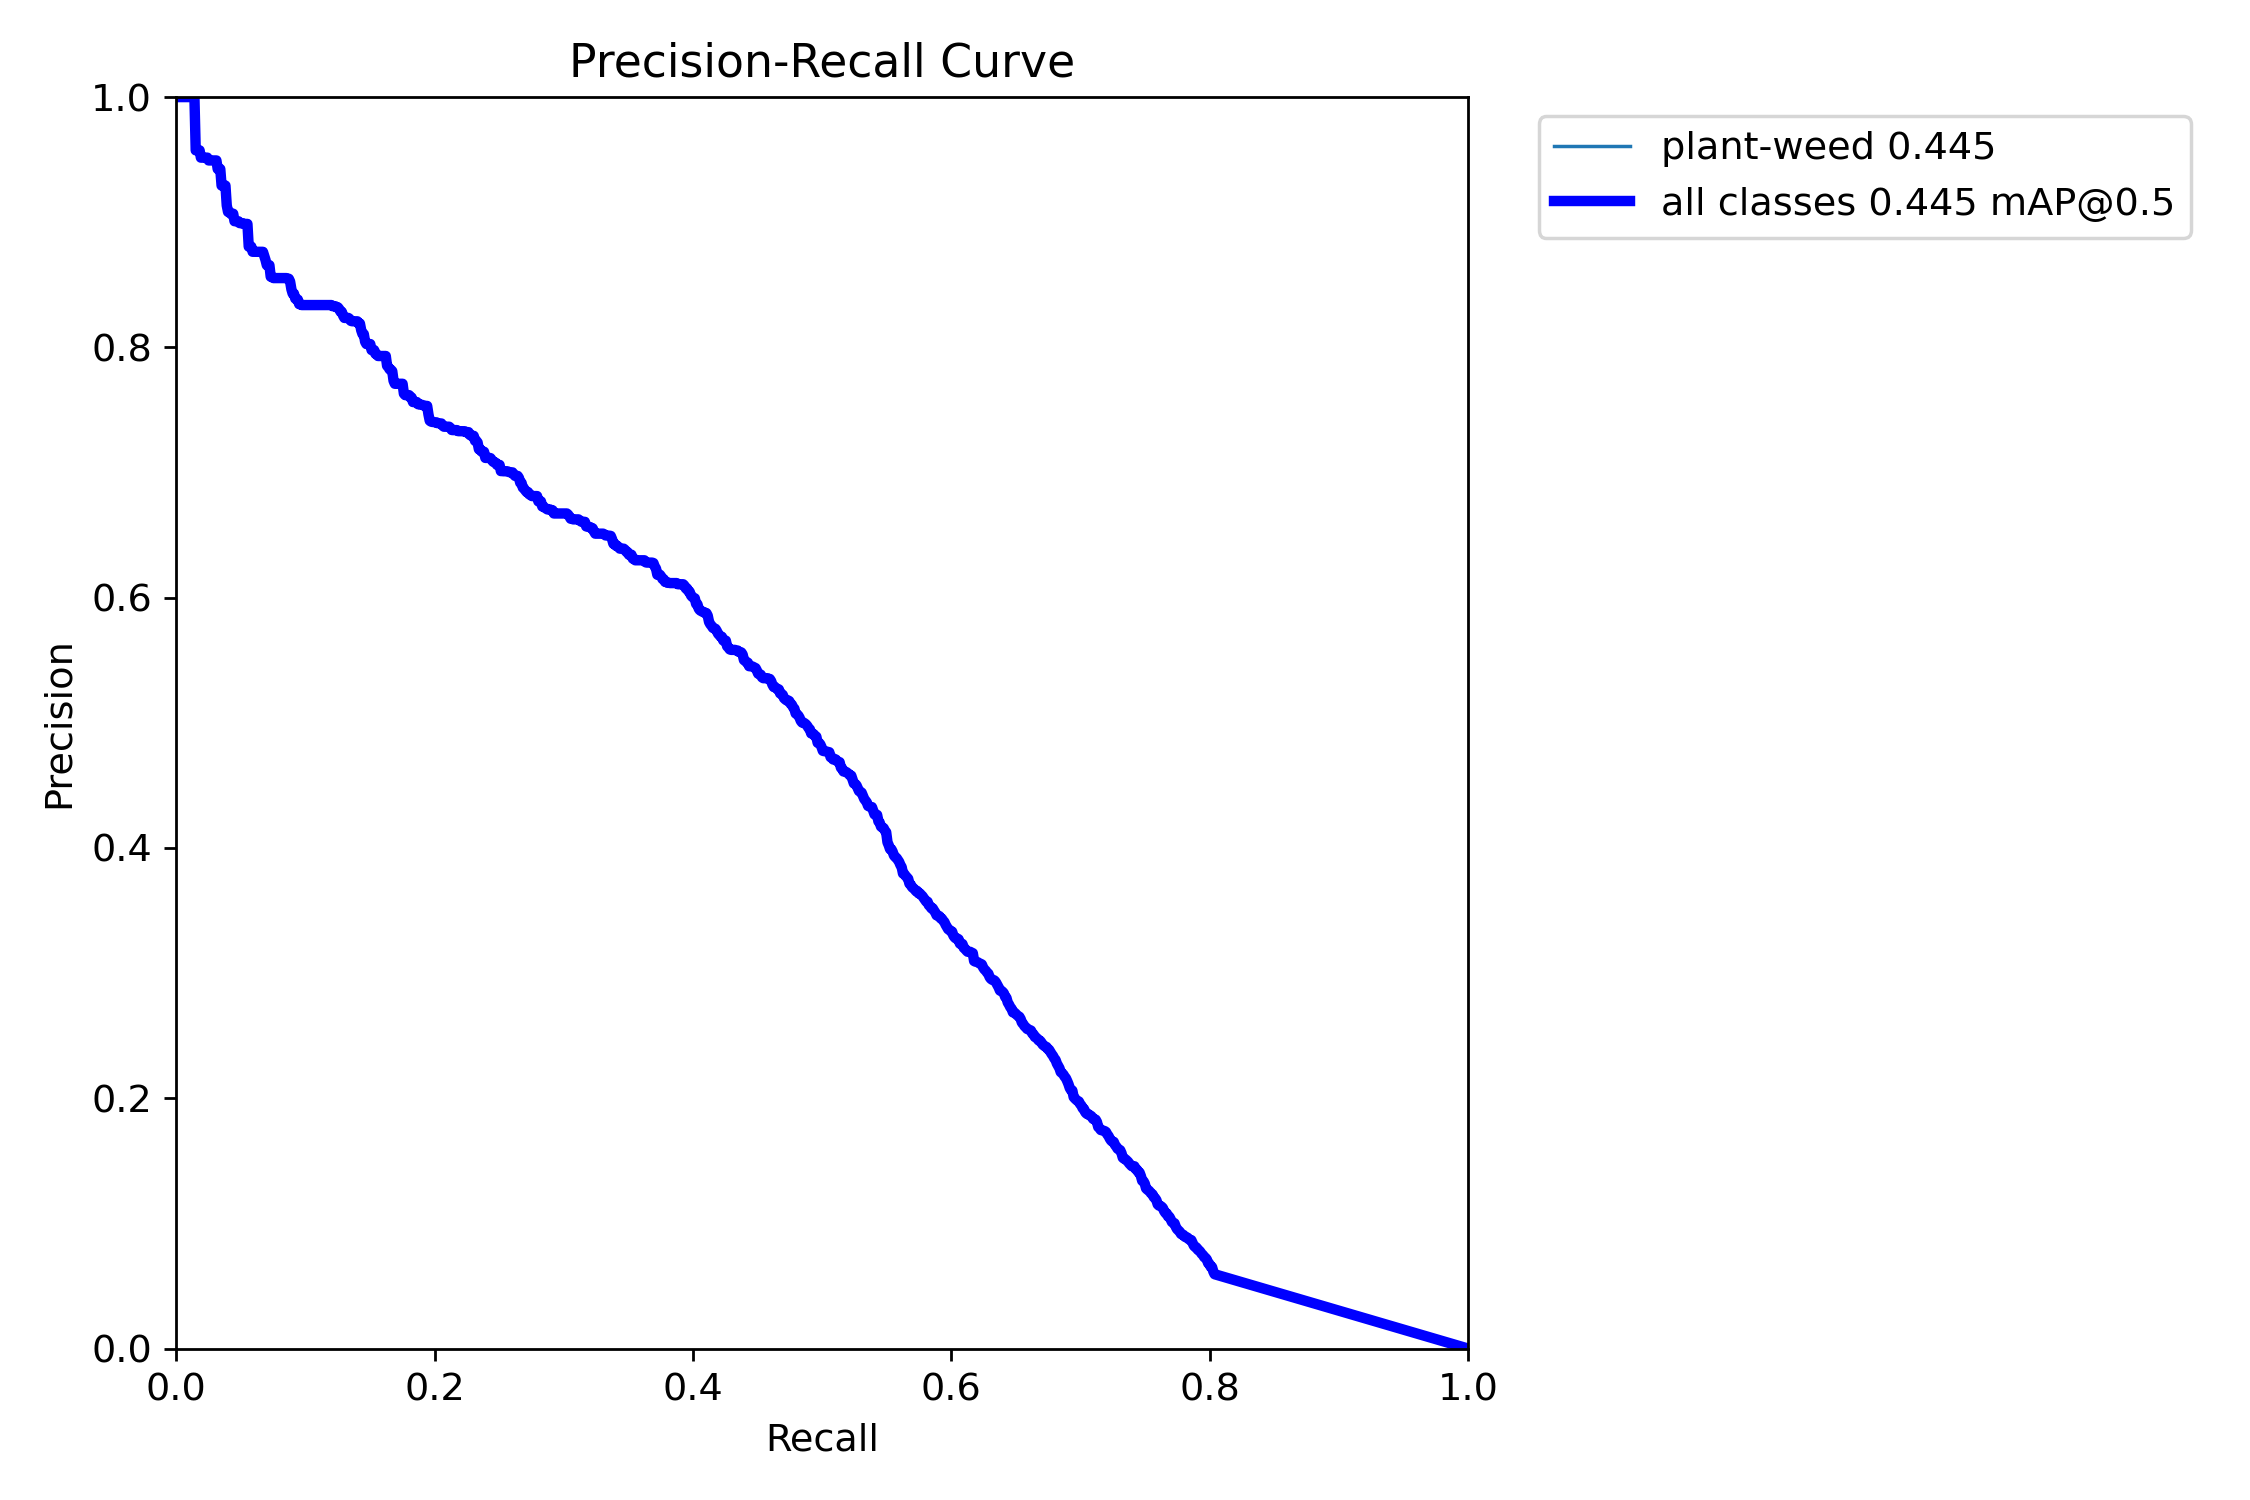

In [75]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

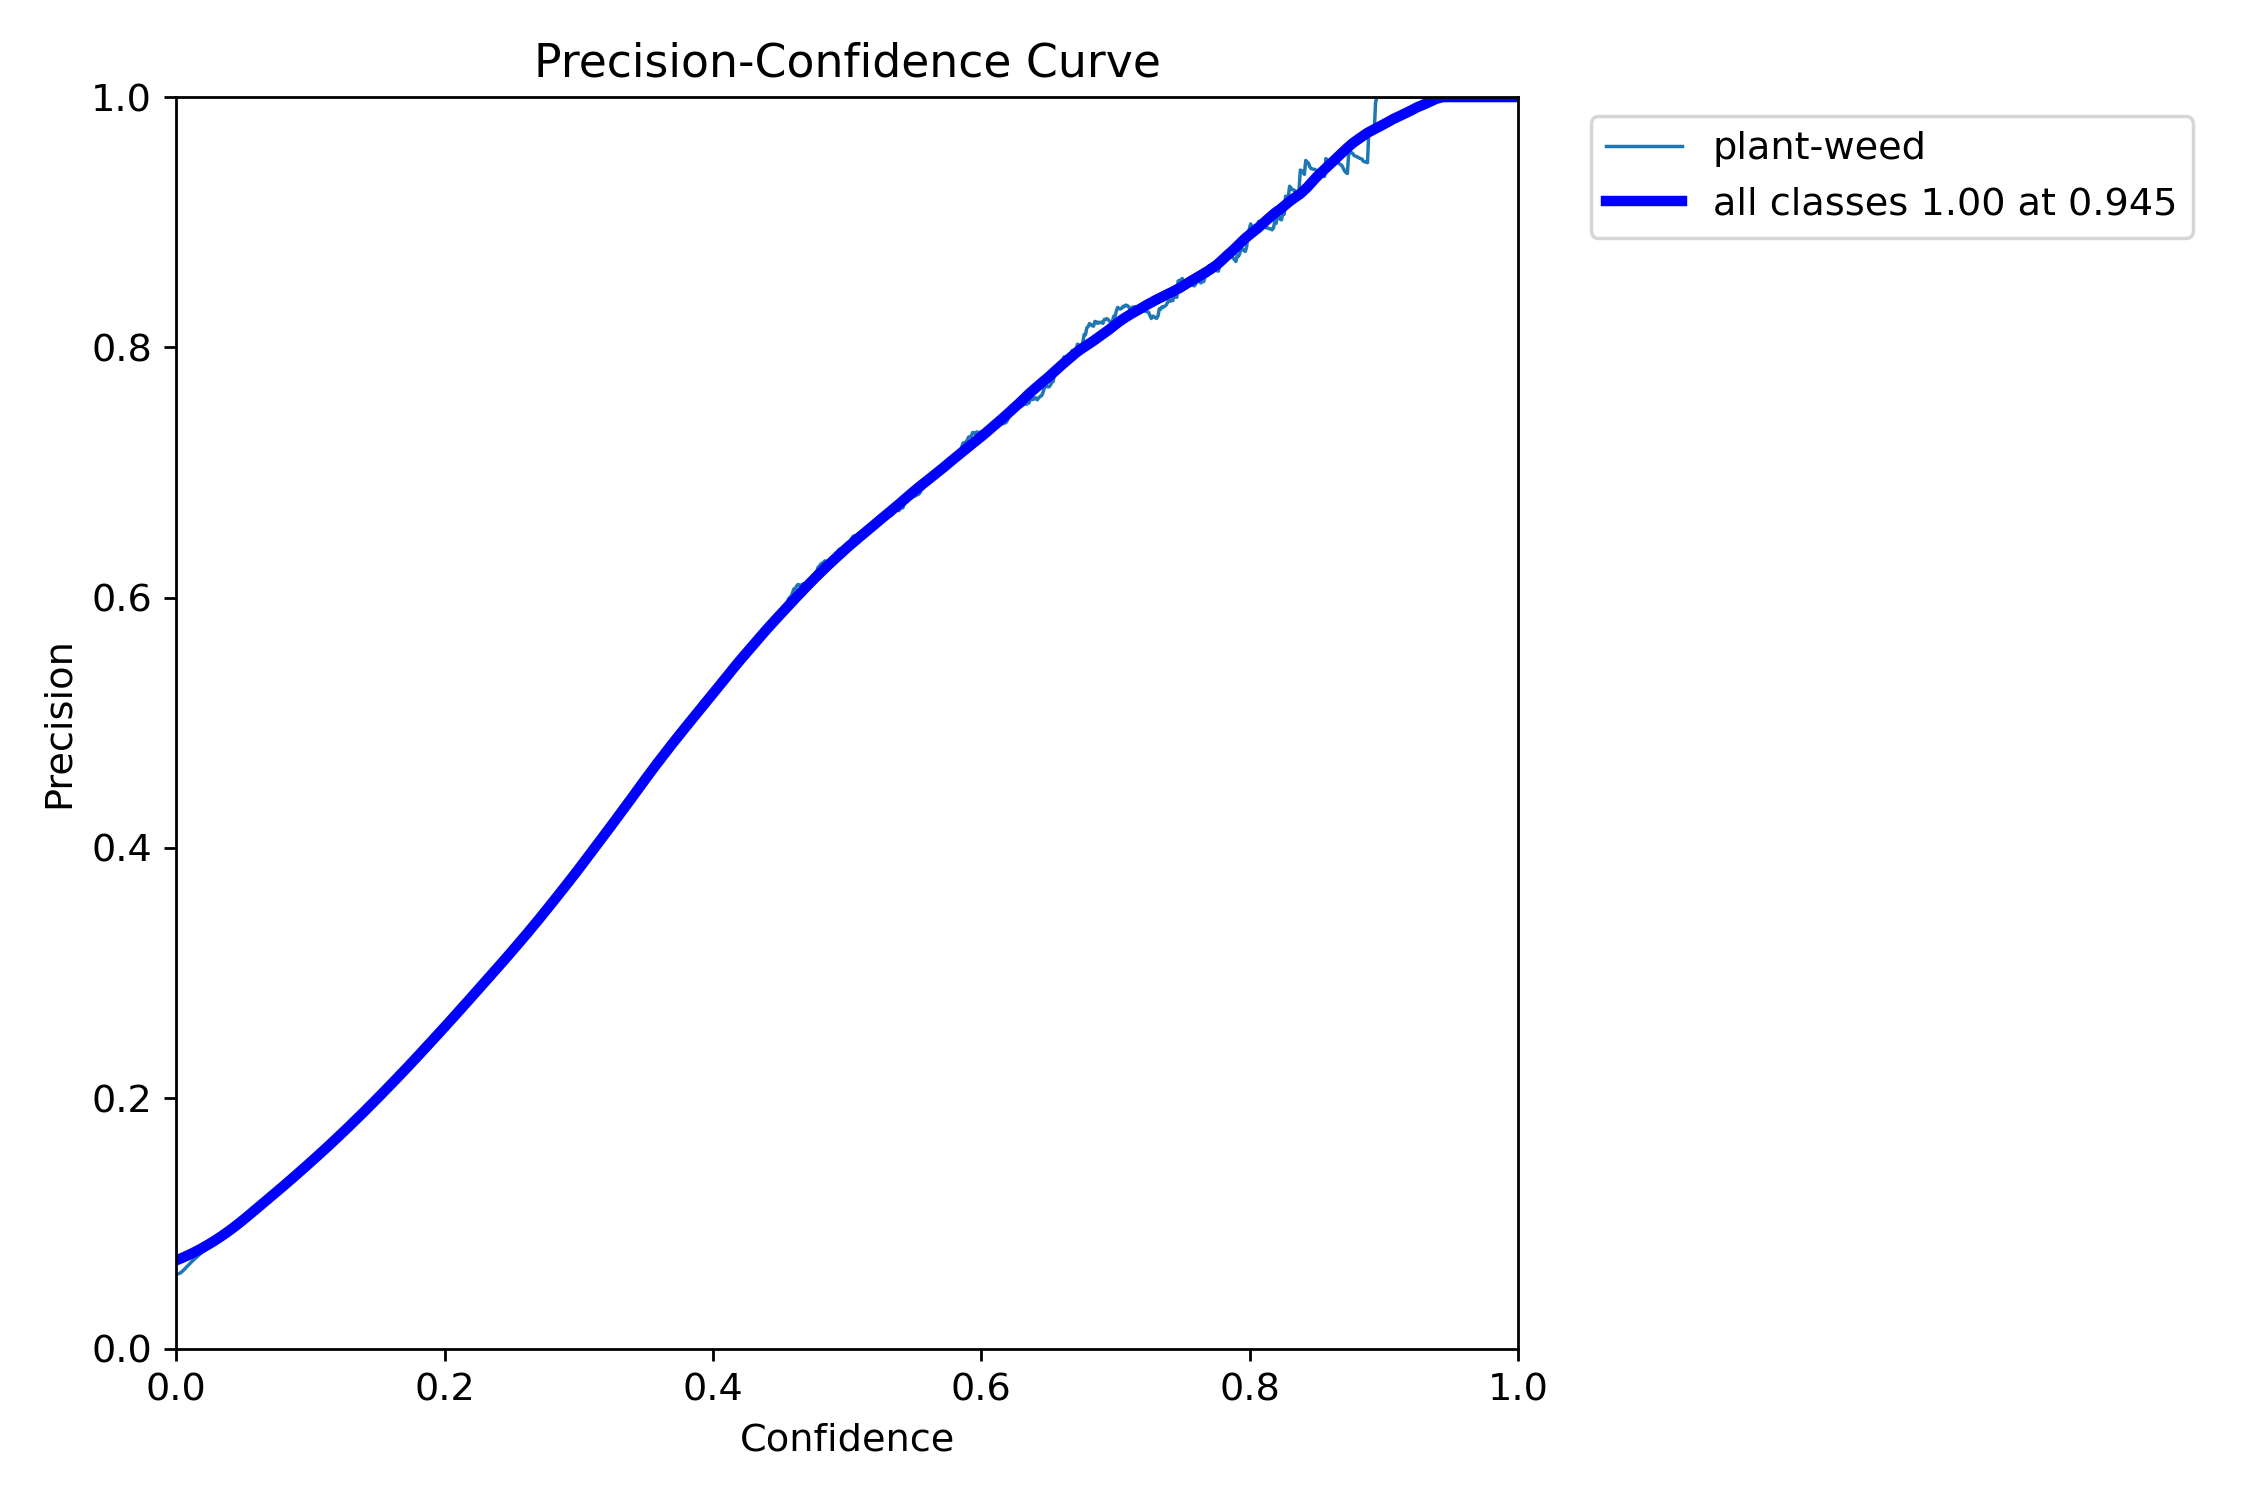

In [76]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

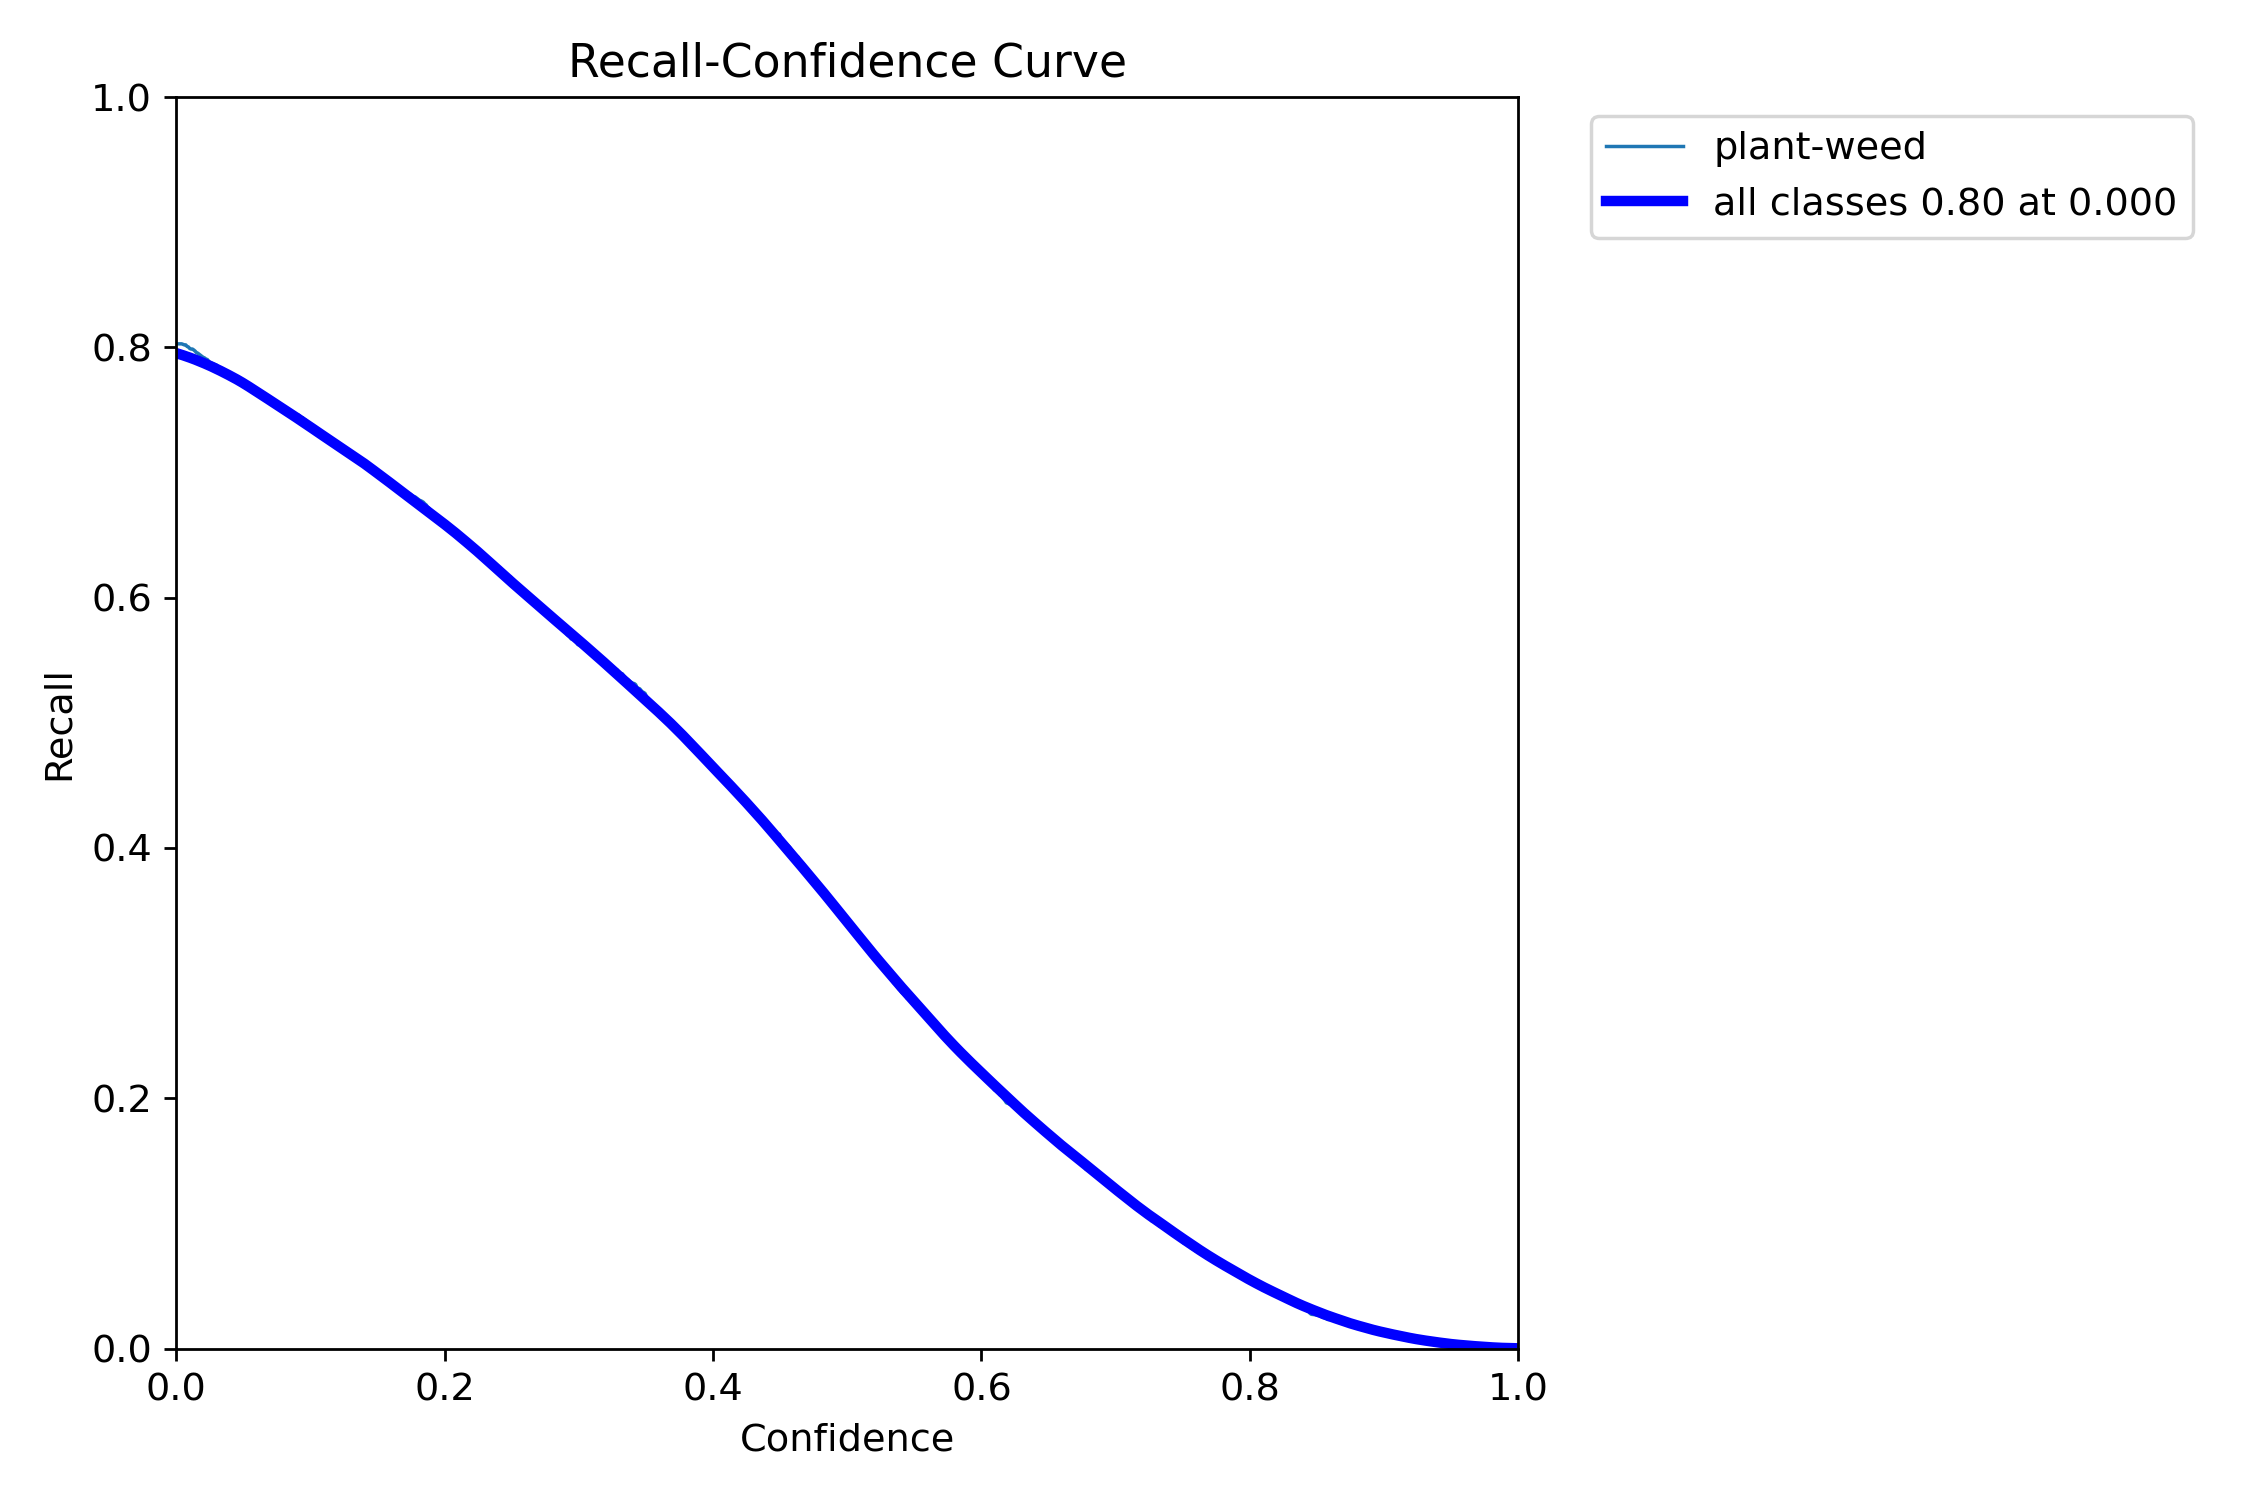

In [77]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

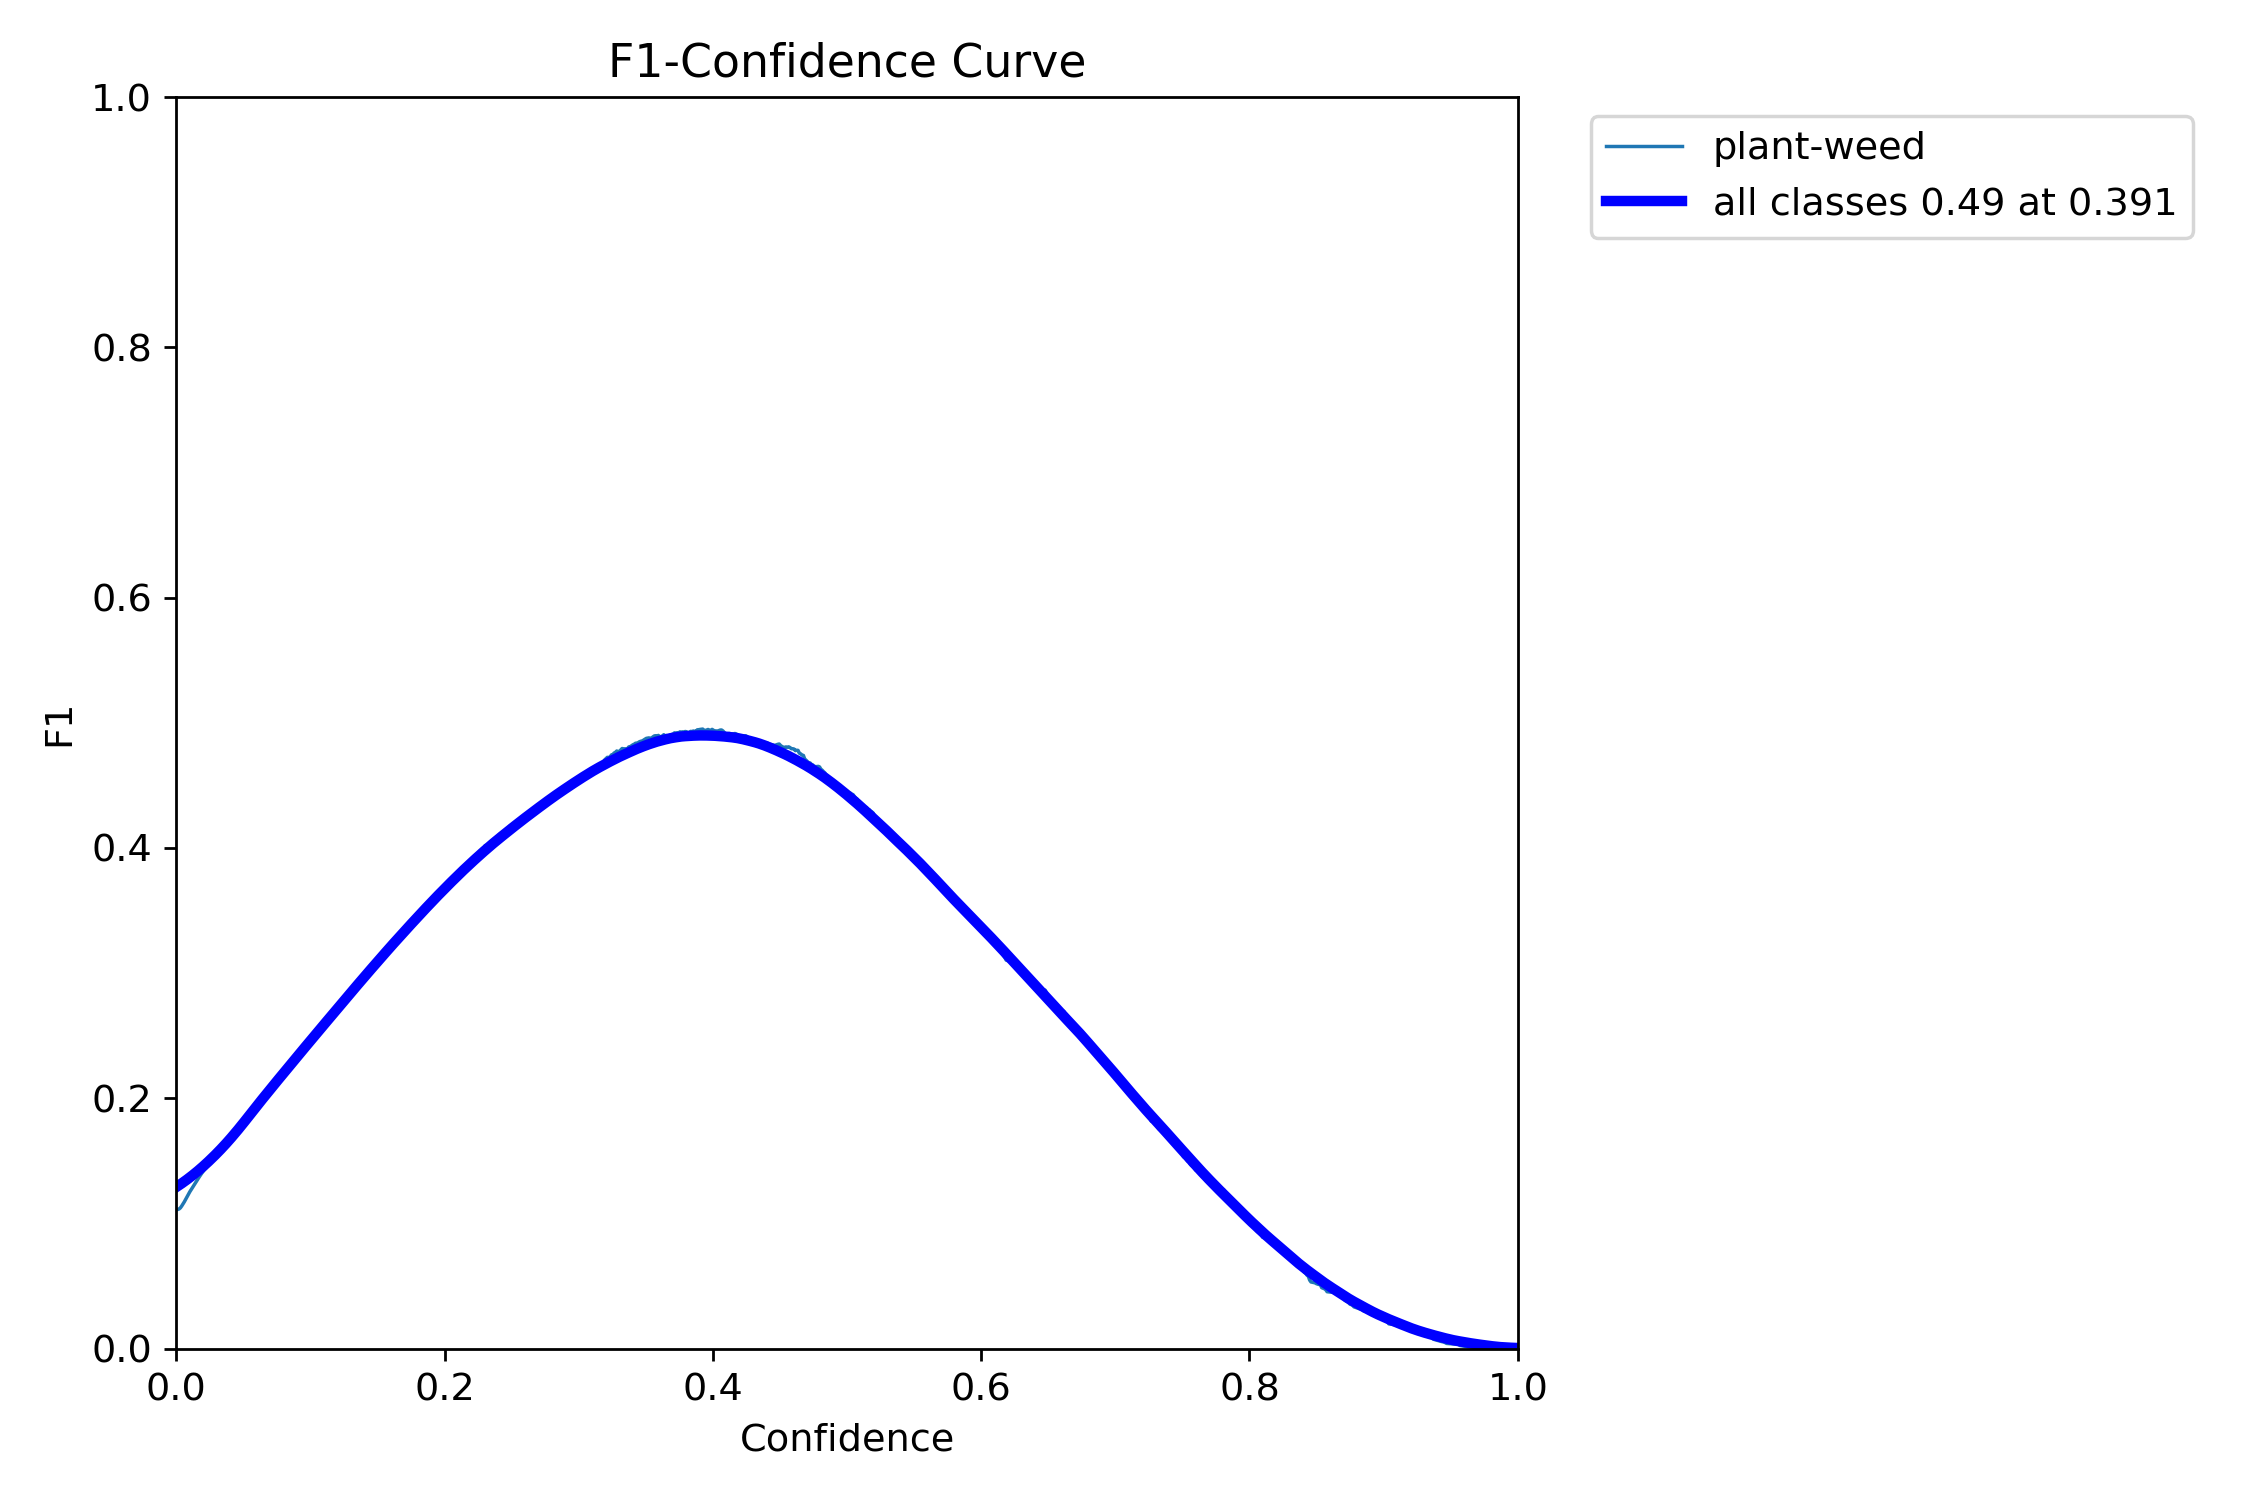

In [78]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

----

# Métricas generales

In [79]:
# best_models.index = [f"{i}º TRAIN" for i in range(1, len(best_models)+1)]

In [80]:
experiment_number = [f"{i}º TRAIN" for i in range(1, len(best_models)-1)]
experiment_number.append('REF1')
experiment_number.append('REF2')
best_models.index = experiment_number

In [81]:
best_models.sort_values(by='metrics/mAP50(B)', ascending=True)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
REF1,61,456.640,2.45698,1.89124,1.77849,0.41957,0.40722,0.35821,0.10947,2.38044,1.66311,1.55345,0.001762,0.001762,0.001762,61.749500
1º TRAIN,100,690.225,1.58127,0.89252,1.20808,0.47810,0.42059,0.37555,0.10552,2.67065,1.40114,1.79053,0.001608,0.001608,0.001608,27.777333
REF2,54,398.282,1.99676,1.25836,1.45897,0.51745,0.47406,0.44565,0.14513,2.32588,1.75765,1.53881,0.001790,0.001790,0.001790,60.348333
2º TRAIN,40,291.001,2.10250,1.58523,1.51643,0.51472,0.47323,0.44668,0.14790,2.27246,1.66960,1.50983,0.001846,0.001846,0.001846,40.302500


## History Graphs

In [82]:
# Define function to plot metrics
def plot_metric(metric, ylabel, title):
    plt.figure(figsize=(15, 5))
    if len(best_models) < 1: print('ALERTA: No hay datos para realizar las gráficas.')
    if len(best_models) >= 1: plt.plot(df1["epoch"], df1[metric], label="Training 1", linestyle="--", marker="o", markersize=4)
    if len(best_models) >= 2: plt.plot(df2["epoch"], df2[metric], label="Training 2", linestyle="--", marker="s", markersize=4)
    if len(best_models) >= 3: plt.plot(df3["epoch"], df3[metric], label="Training 3", linestyle="--", marker="d", markersize=4)
    if len(best_models) >= 4: plt.plot(df4["epoch"], df4[metric], label="Training 4", linestyle="--", marker="^", markersize=4)
    if len(best_models) >= 5: plt.plot(df5["epoch"], df5[metric], label="Training 5", linestyle="--", marker="v", markersize=4)
    if len(best_models) >= 6: plt.plot(df6["epoch"], df6[metric], label="Training 6", linestyle="--", marker="p", markersize=4)
    if len(best_models) >= 7: print("La cantidad de modelos entrenados supera la configuración del gráfico, por favor ajustar la función 'plot_metric()'")
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Training and Validation Losses

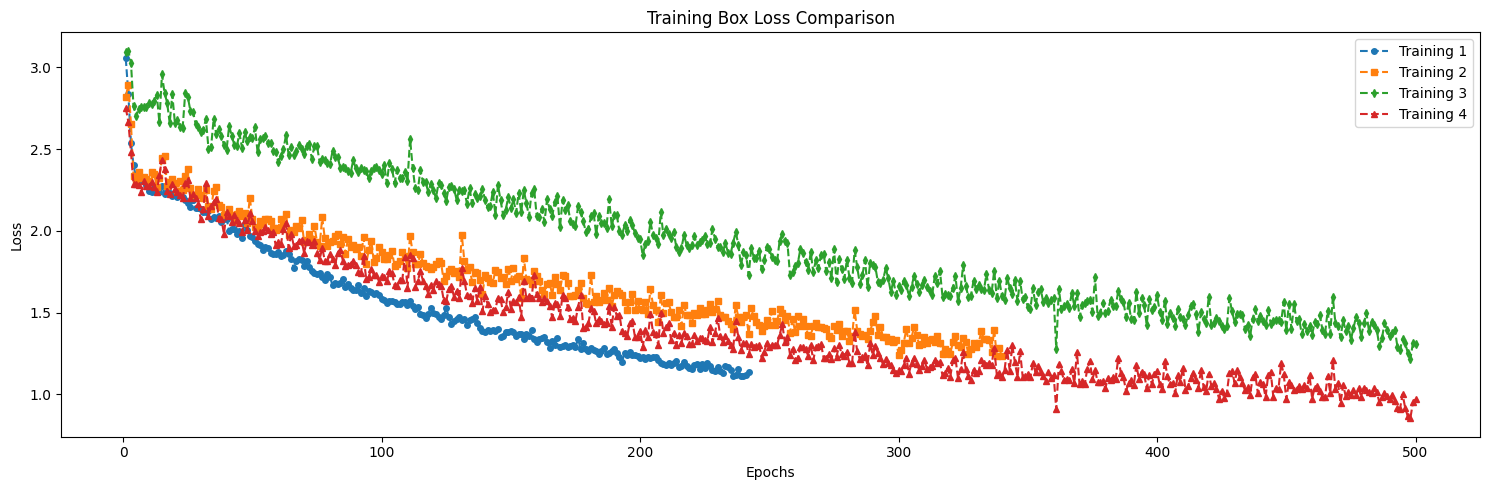

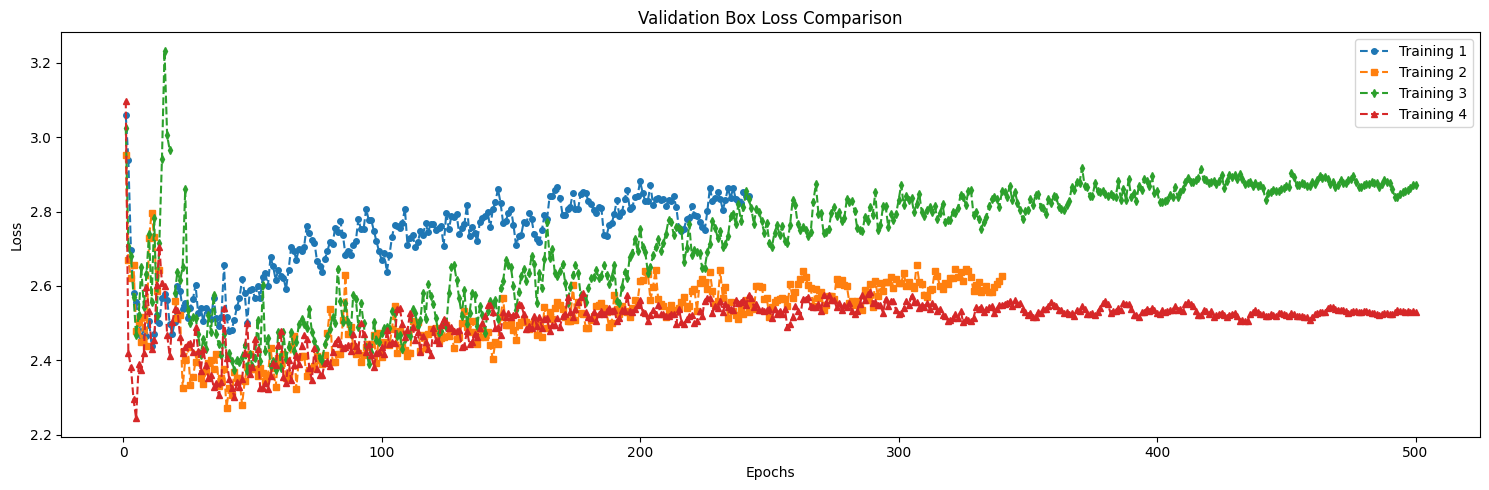

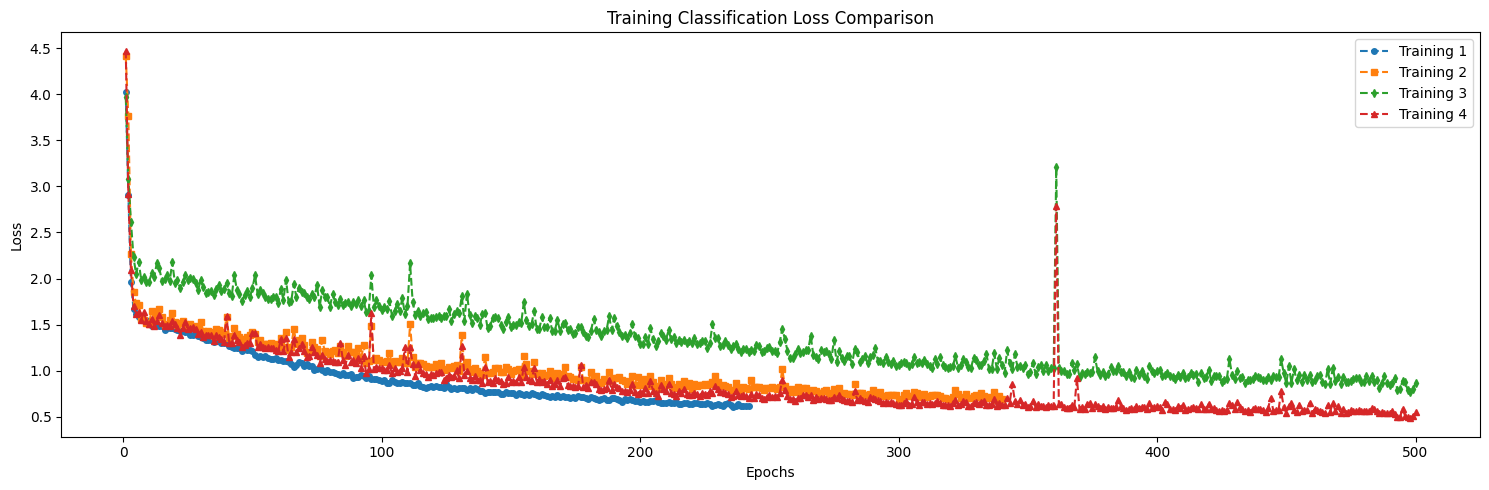

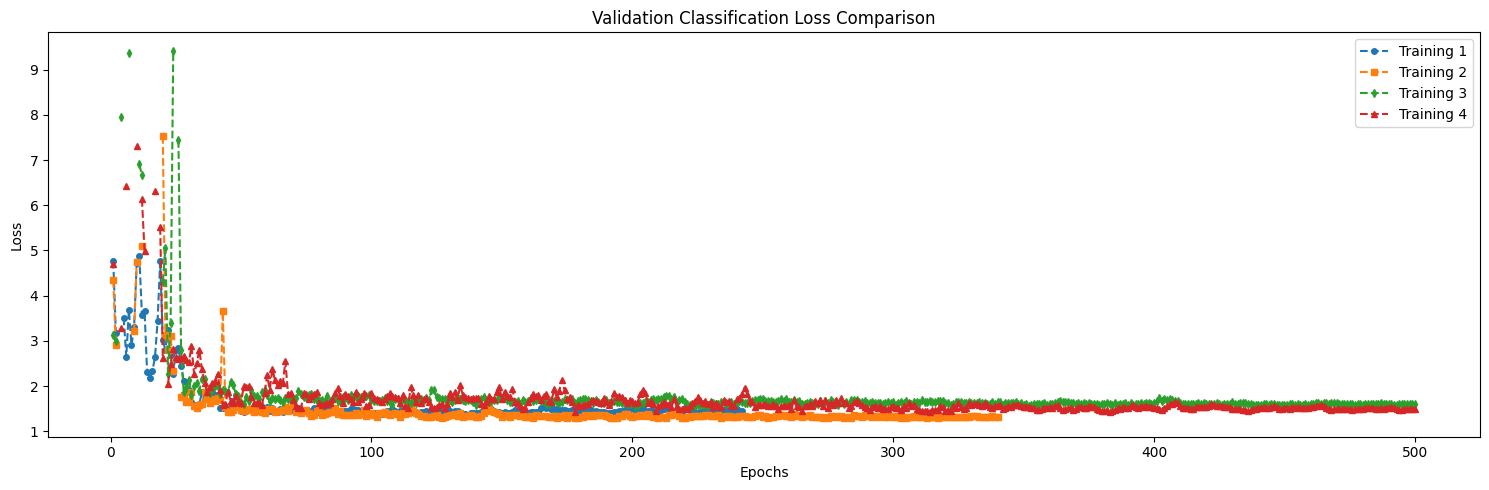

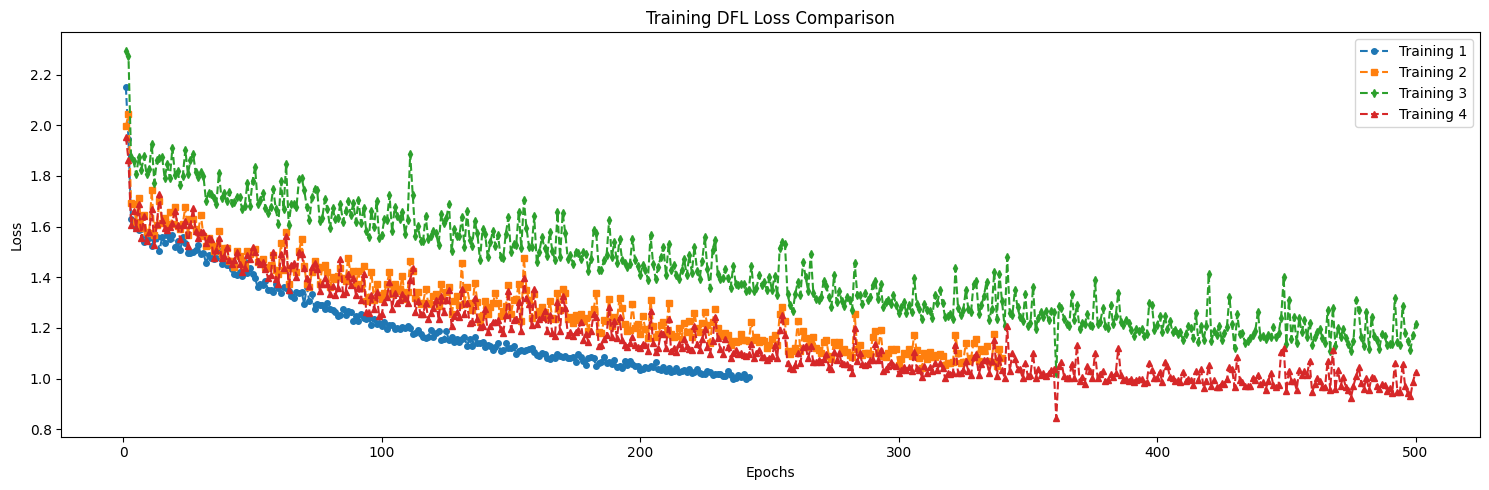

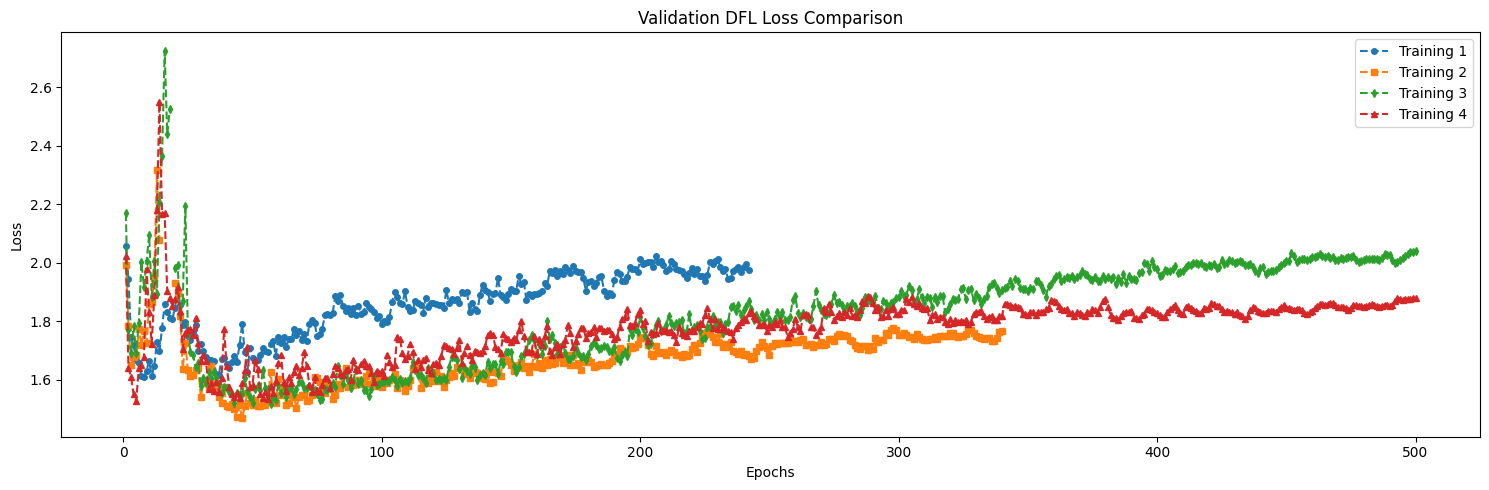

In [83]:
# Plot Training and Validation Losses
plot_metric("train/box_loss", "Loss", "Training Box Loss Comparison")
plot_metric("val/box_loss", "Loss", "Validation Box Loss Comparison")

plot_metric("train/cls_loss", "Loss", "Training Classification Loss Comparison")
plot_metric("val/cls_loss", "Loss", "Validation Classification Loss Comparison")

plot_metric("train/dfl_loss", "Loss", "Training DFL Loss Comparison")
plot_metric("val/dfl_loss", "Loss", "Validation DFL Loss Comparison")

### Performance Metrics

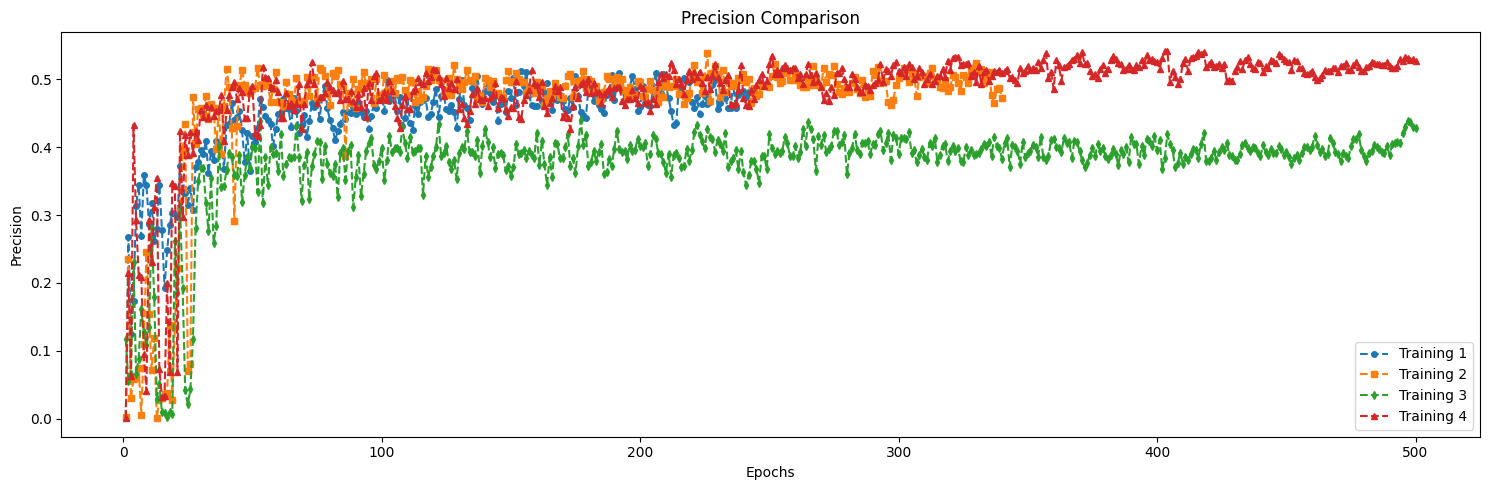

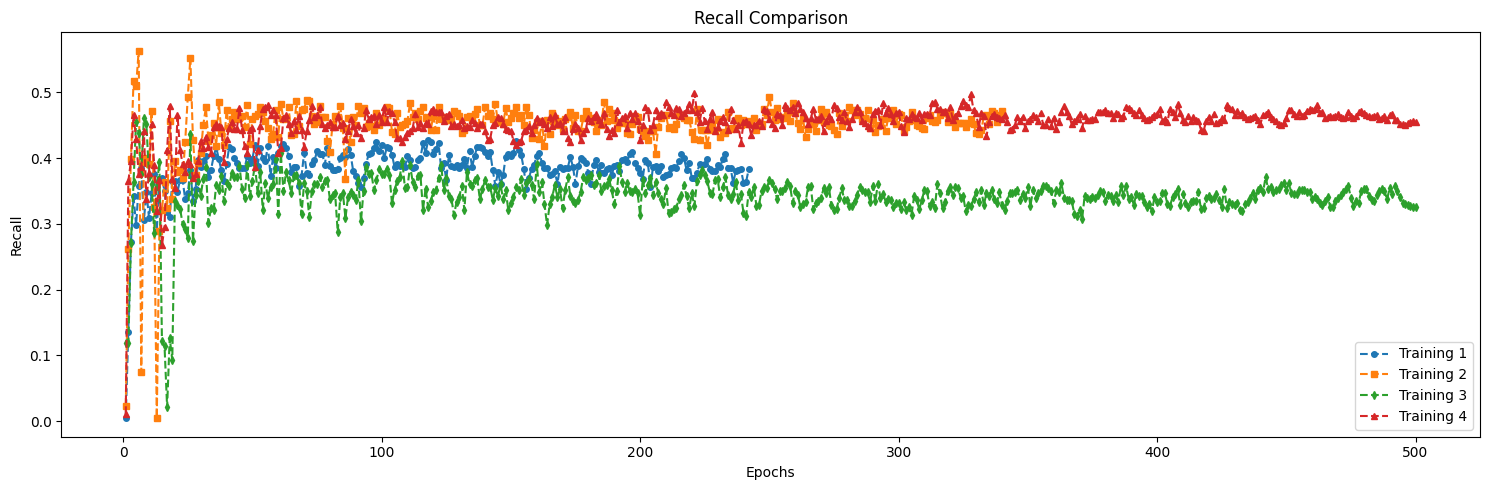

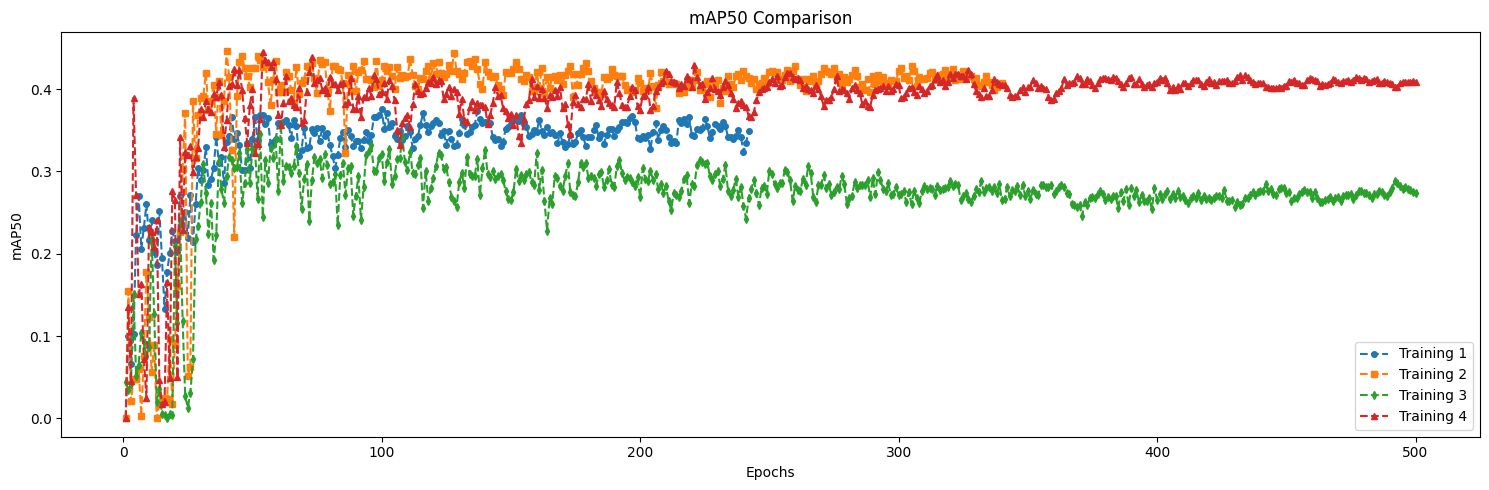

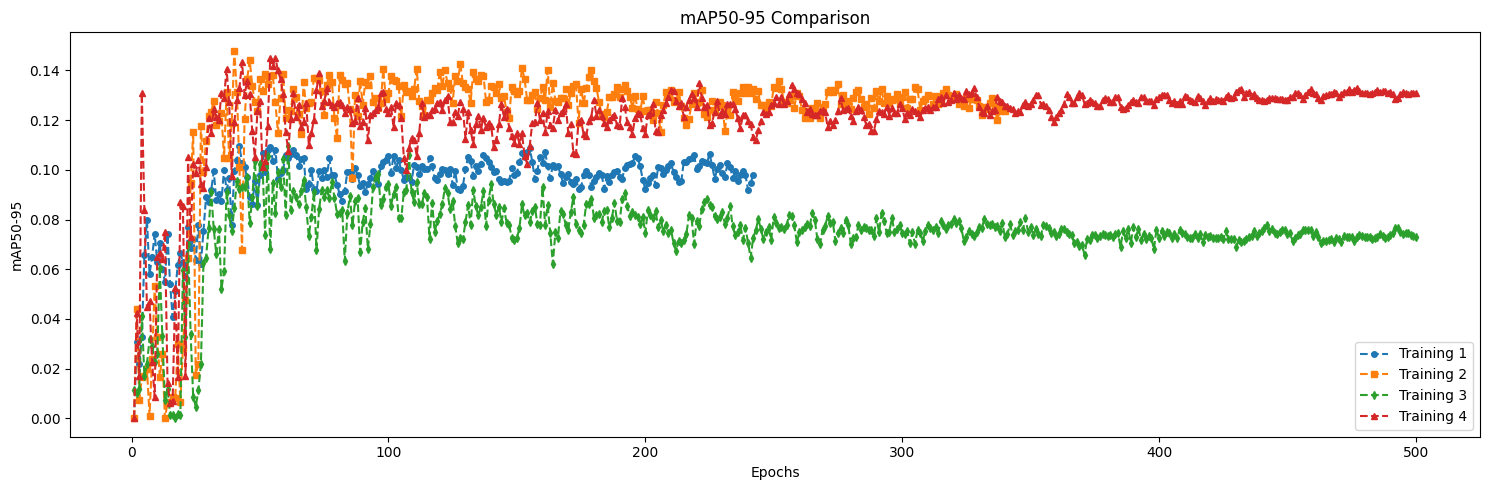

In [84]:
# Plot Performance Metrics
plot_metric("metrics/precision(B)", "Precision", "Precision Comparison")
plot_metric("metrics/recall(B)", "Recall", "Recall Comparison")
plot_metric("metrics/mAP50(B)", "mAP50", "mAP50 Comparison")
plot_metric("metrics/mAP50-95(B)", "mAP50-95", "mAP50-95 Comparison")

### Learning Rate

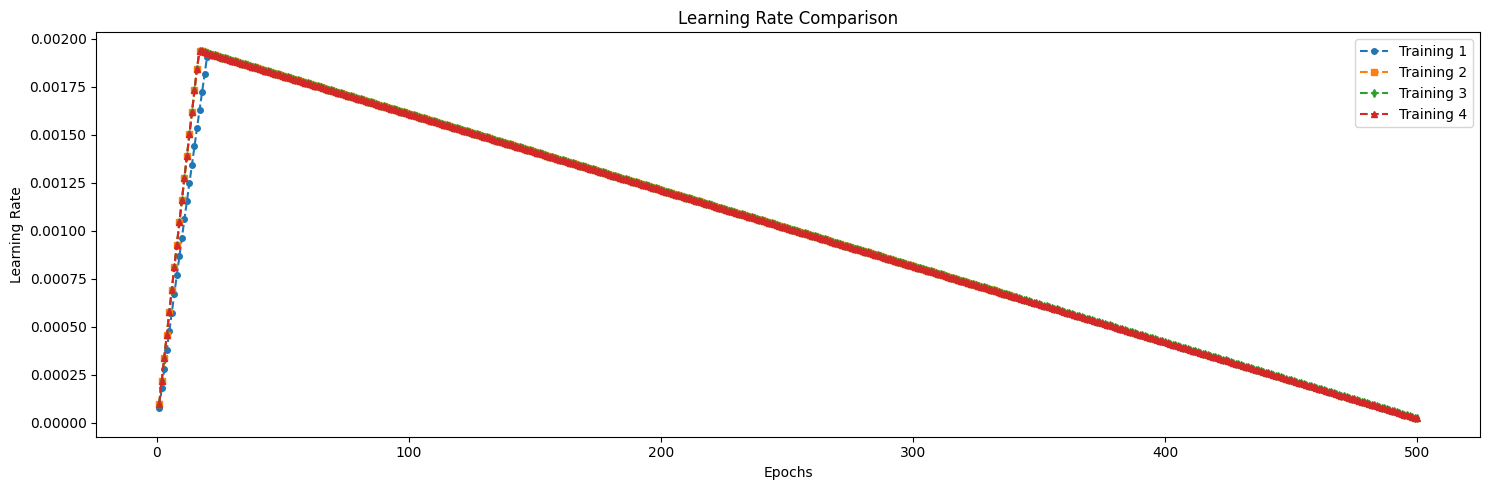

In [85]:
# Plot Learning Rate
plot_metric("lr/pg0", "Learning Rate", "Learning Rate Comparison")

## Comparative Graphs

In [86]:
#SETUP:
log_scale = False # Apply log scale to the y-axis

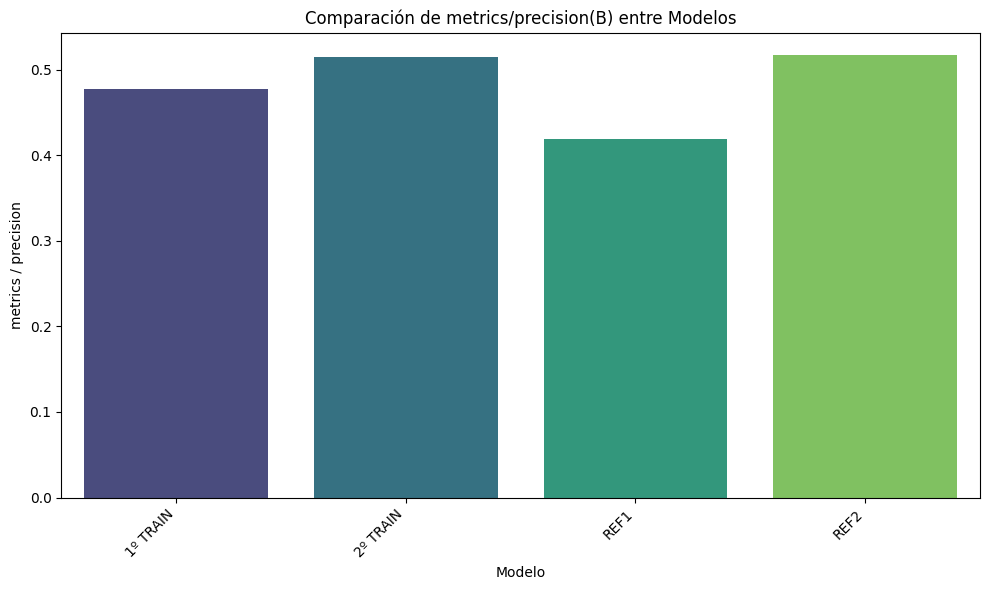

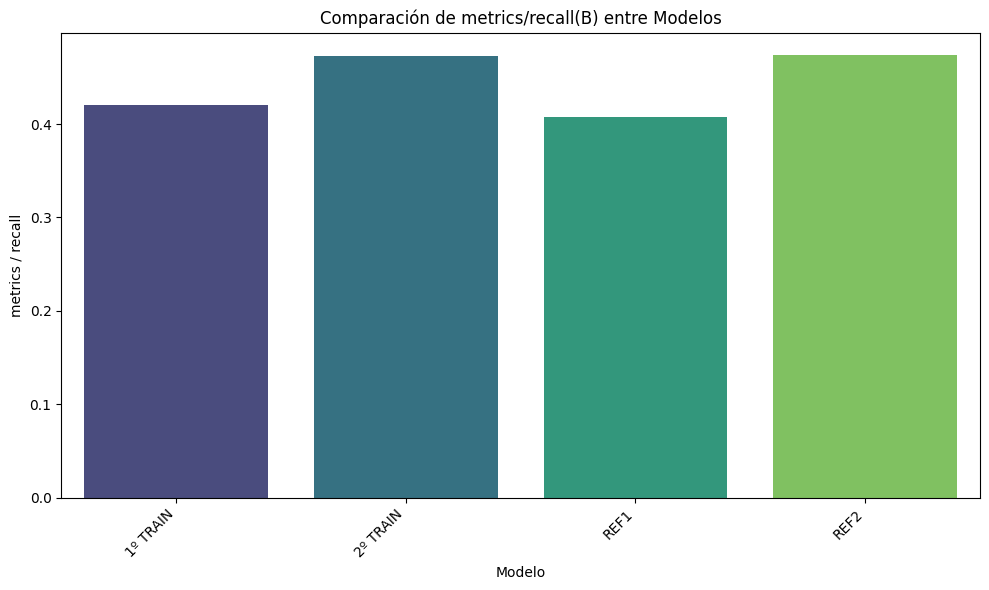

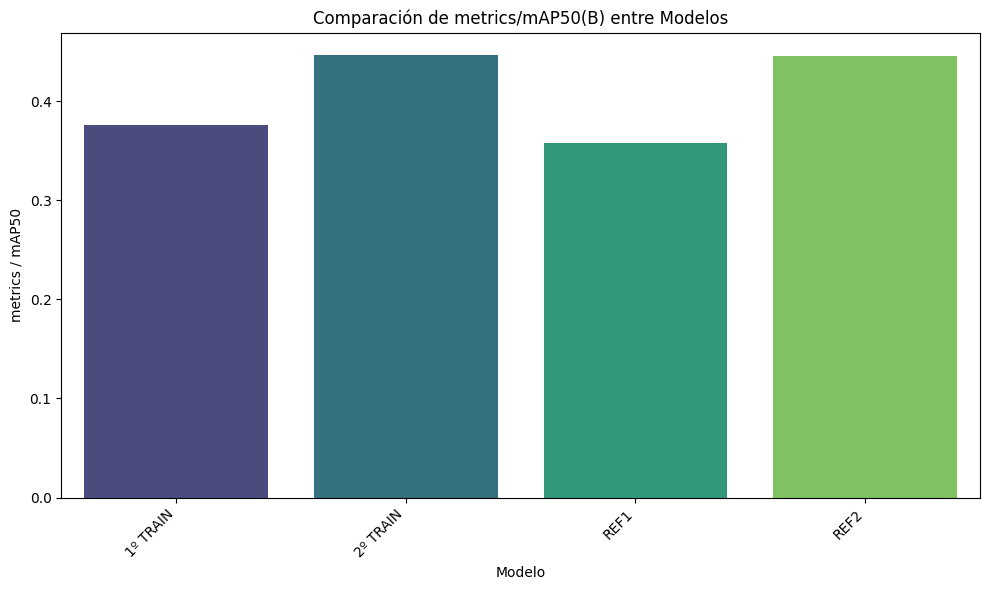

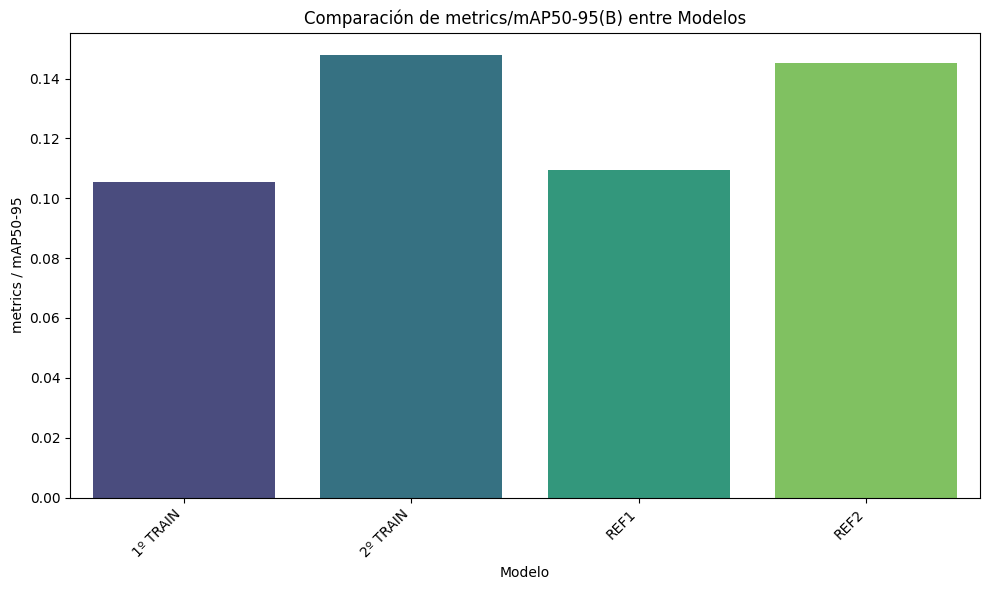

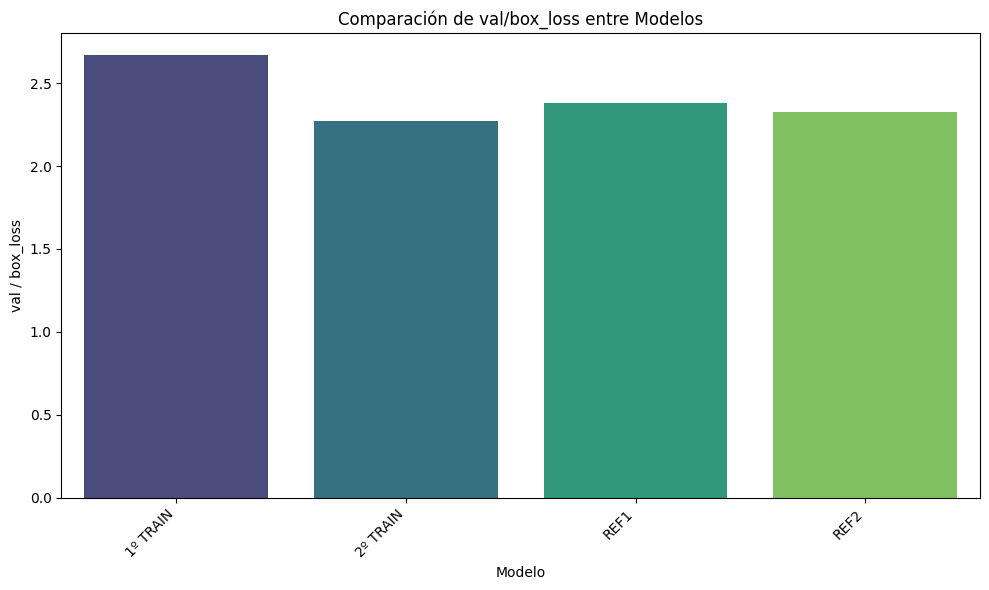

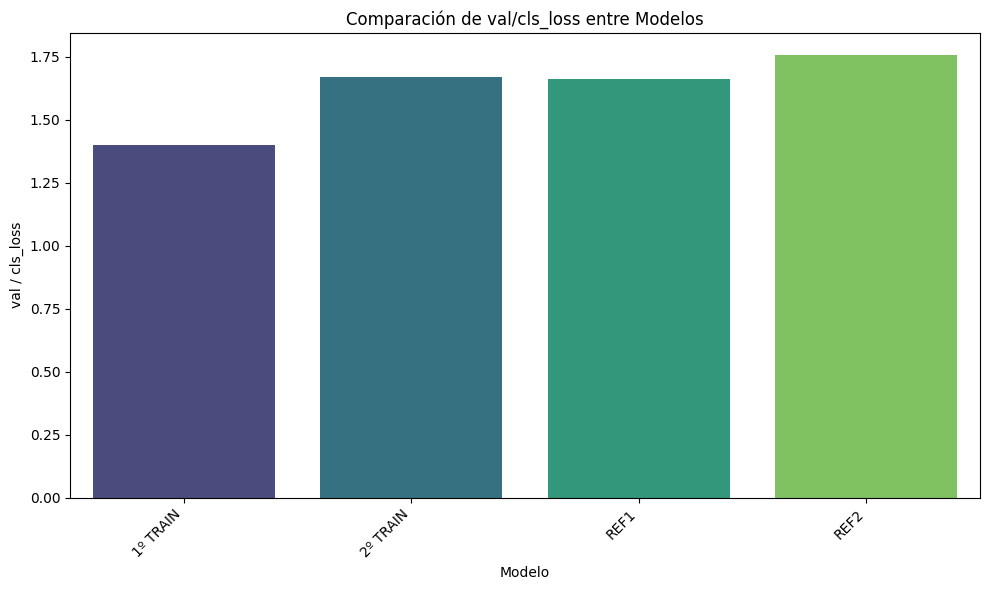

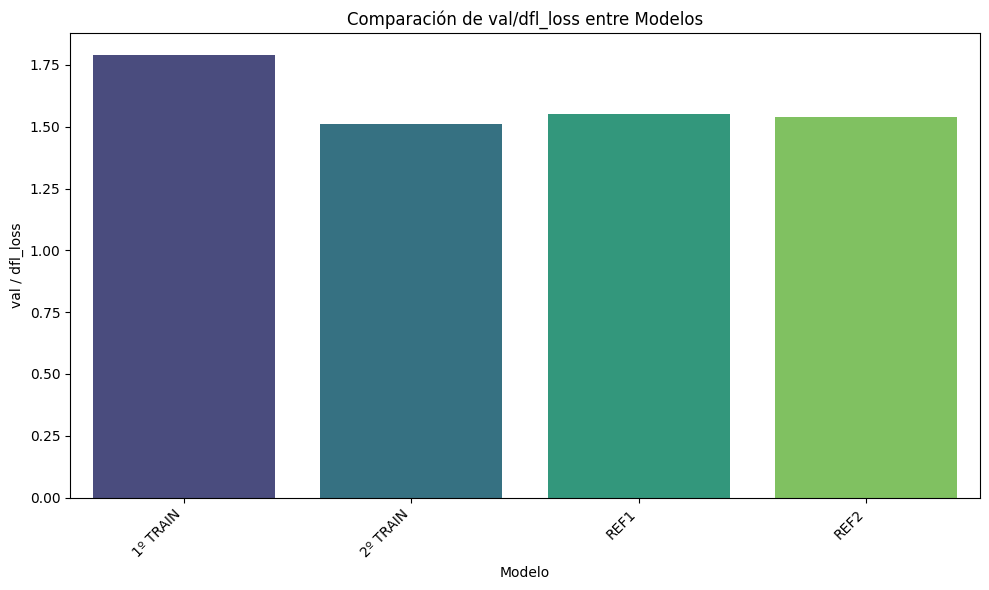

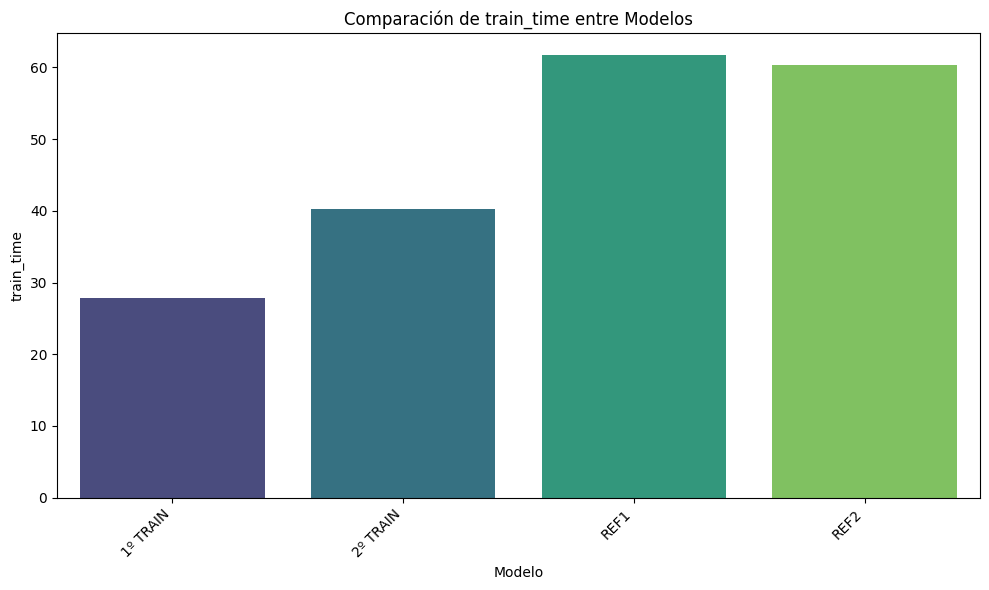

In [87]:
import seaborn as sns

metrics_to_plot = [
    'metrics/precision(B)',
    'metrics/recall(B)',
    'metrics/mAP50(B)',
    'metrics/mAP50-95(B)',
    'val/box_loss',
    'val/cls_loss',
    'val/dfl_loss',
    'train_time' # Tiempo de entrenamiento también puede ser interesante
]

# Filtramos las métricas que realmente existen en el DataFrame y no tienen todos los valores NaN
metrics_to_plot = [m for m in metrics_to_plot if m in best_models.columns and not best_models[m].isnull().all()]

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Preparamos el DataFrame para seaborn (opcional pero a veces útil)
# Usaremos el índice directamente en este caso.
df_plot = best_models.copy()
df_plot['Model'] = df_plot.index # Crea una columna 'Model' a partir del índice

# --- 3. Genera un gráfico de barras para cada métrica ---
# print(f"Generando gráficos para las métricas: {metrics_to_plot}")

for metric in metrics_to_plot:

    # Verificamos si la métrica tiene todos los valores NaN o cero
    if df_plot[metric].isnull().all() or (df_plot[metric] == 0).all():
        print(f"(*) Omitiendo gráfico para '{metric}' (todos los valores son NaN o cero).") # Warnings
        continue

    # Filtramos los modelos que tienen NaN o cero en la métrica actual
    omitted_rows = best_models[best_models[metric].isnull() | (best_models[metric] == 0)].index.tolist()
    df_plot = best_models[~best_models.index.isin(omitted_rows)].copy()
    df_plot['Model'] = df_plot.index  # Ensure the 'Model' column is preserved

    plt.figure(figsize=(10, 6))  # Adjust the figure size as needed
    sns.barplot(x='Model', y=metric, data=df_plot, hue='Model', palette='viridis', dodge=False, legend=False)

    plt.yscale('log') if log_scale else None 
    plt.title(f'Comparación de {metric} entre Modelos')
    plt.xlabel('Modelo')
    plt.ylabel(metric.replace('(B)', '').replace('/', ' / '))  # Clean up the y-axis label
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if they are long
    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()

    if omitted_rows:
        print(f"- El modelo {', '.join(omitted_rows)} fue omitido para la métrica '{metric}' (tiene valores NaN o 0).")  # Warnings
    print("\n")

## Lollipop Graphs

In [88]:
#SETUP:
horizontal = False # Set to True for horizontal lollipop chart
log_scale = False # Apply log scale to the y-axis
sort = True # Sort values for better visual flow
sort_type = 'ascending' # Options: 'ascending', 'descending'

Orenamiento: ascending


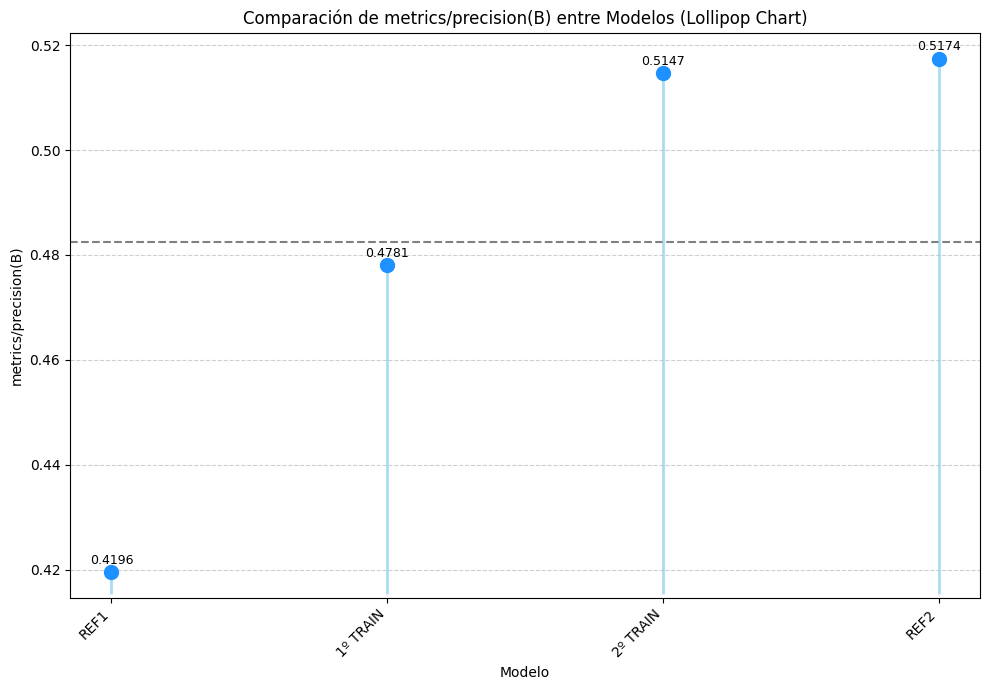

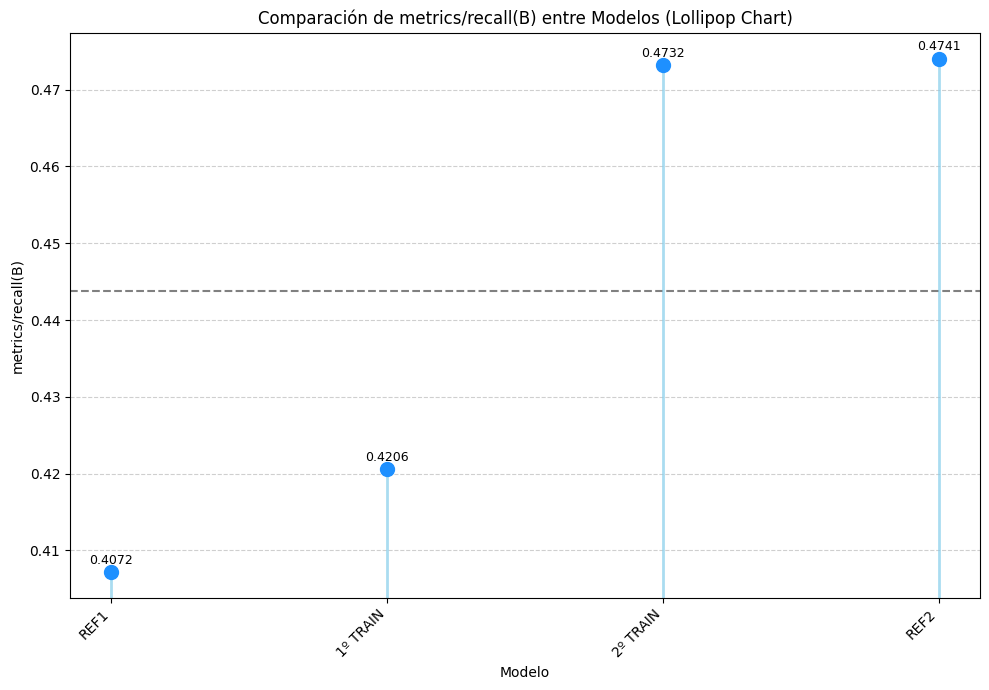

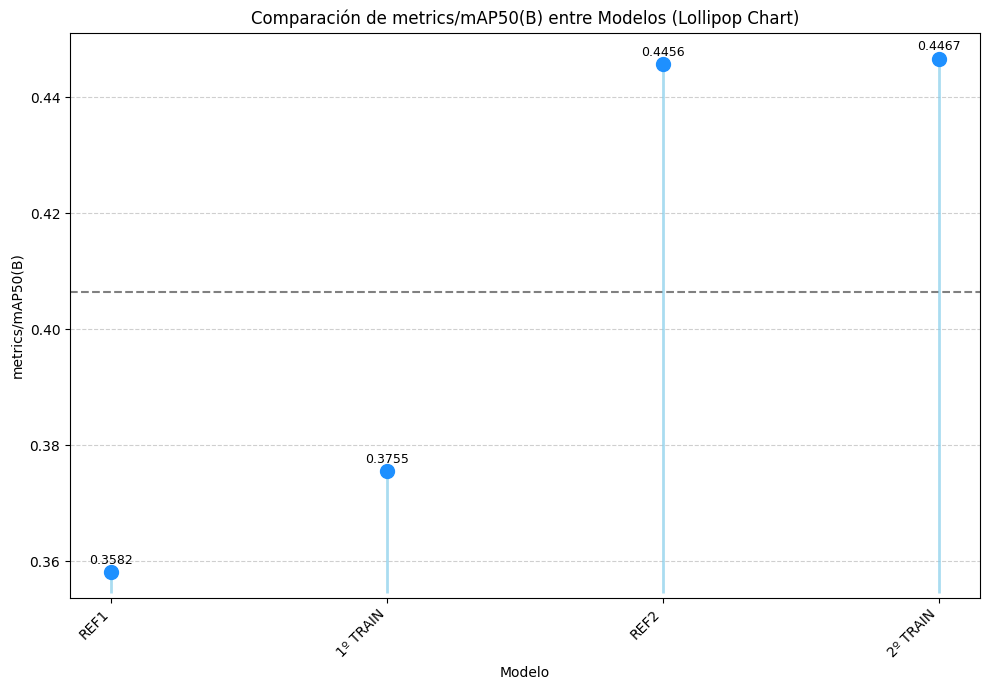

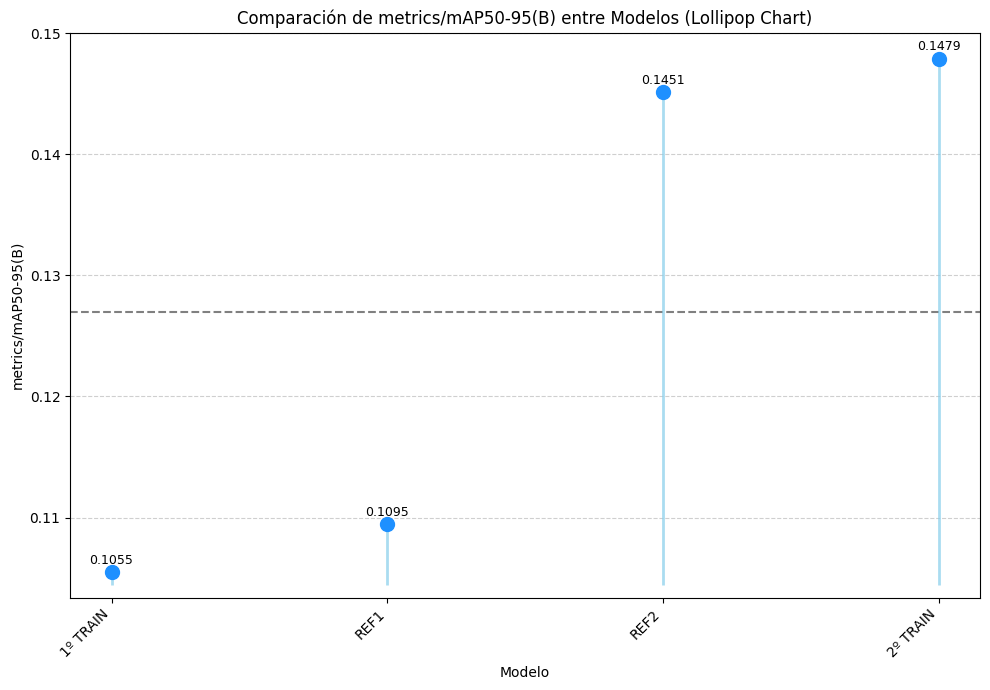

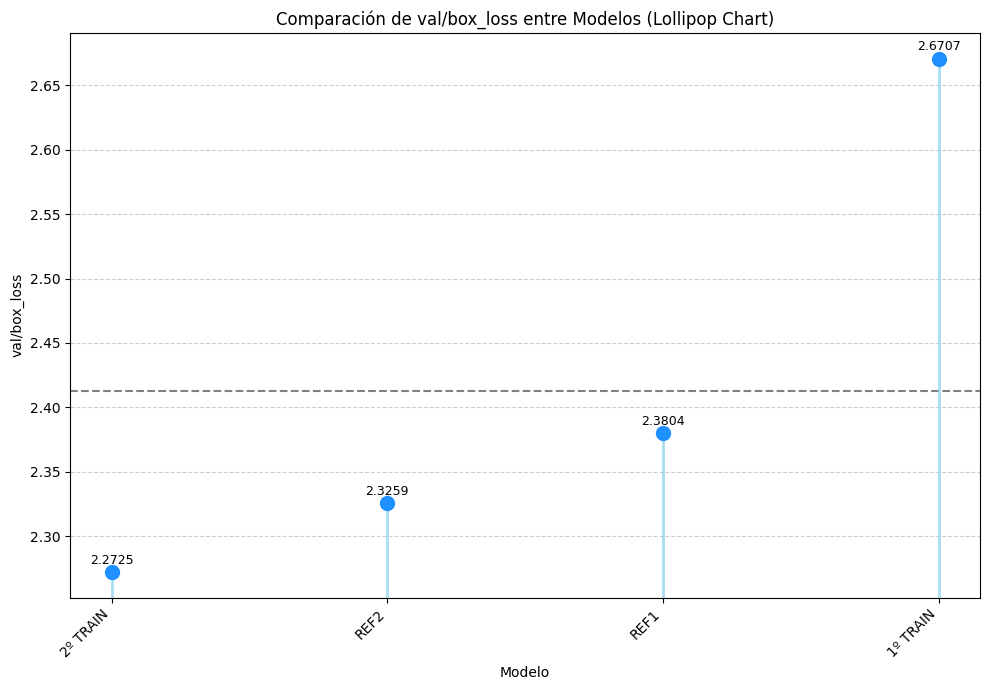

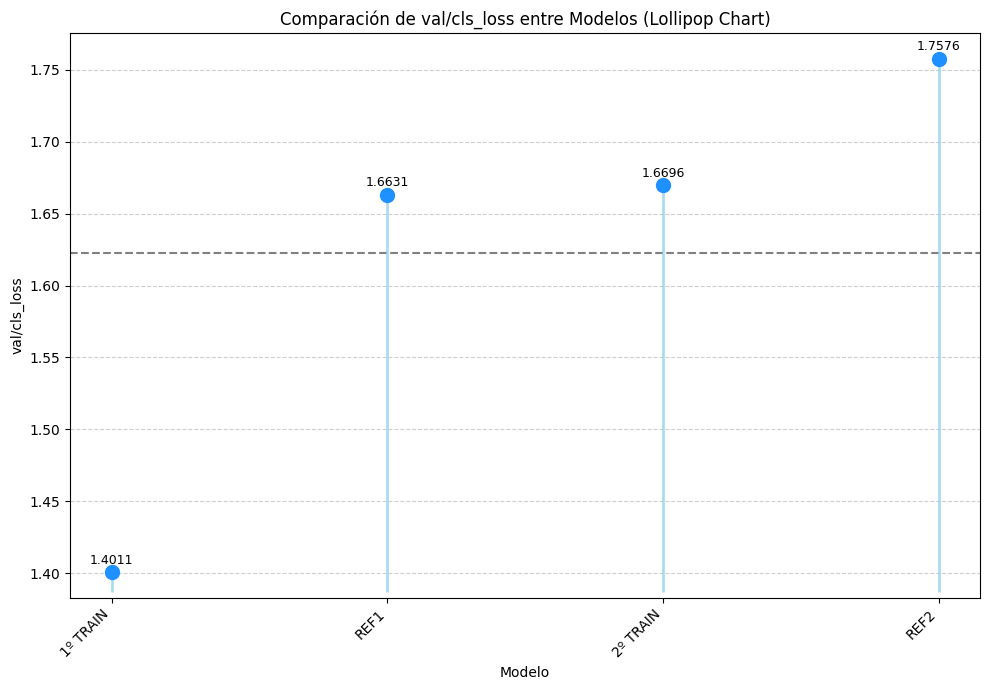

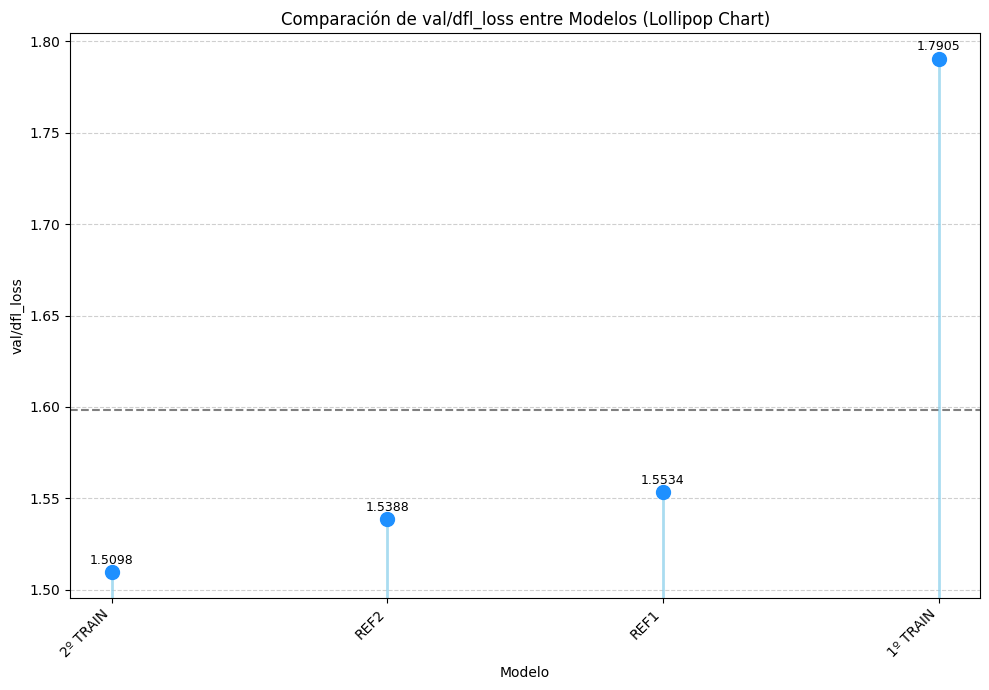

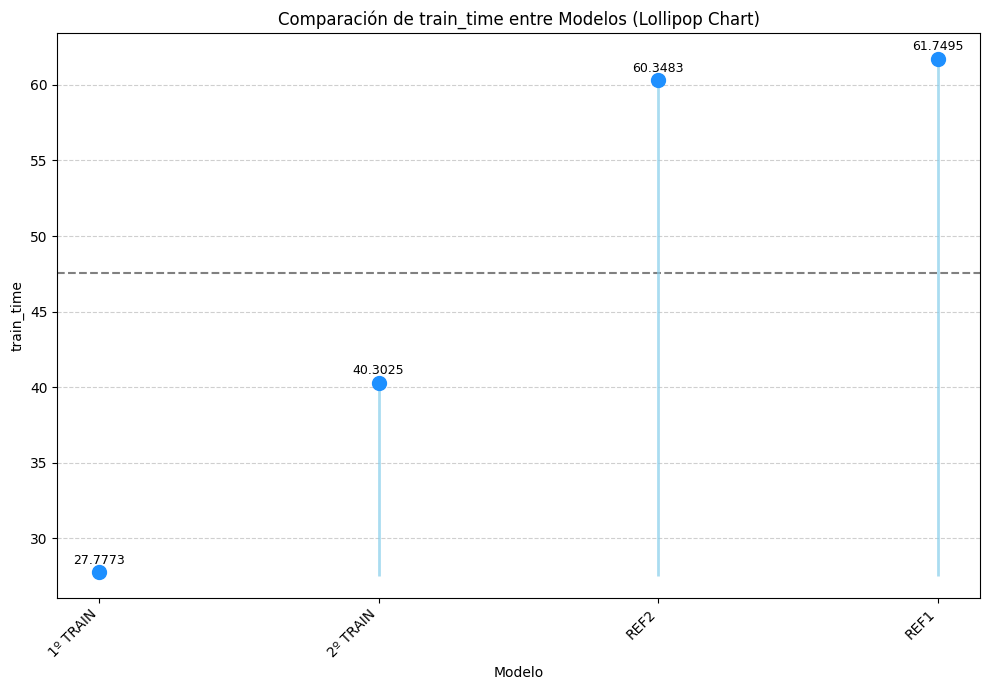

In [89]:
metrics_to_plot = [
    'metrics/precision(B)',
    'metrics/recall(B)',
    'metrics/mAP50(B)',
    'metrics/mAP50-95(B)',
    'val/box_loss',
    'val/cls_loss',
    'val/dfl_loss',
    'train_time' # Tiempo de entrenamiento también puede ser interesante
]

# Filtramos las métricas que realmente existen en el DataFrame y no tienen todos los valores NaN
metrics_to_plot = [m for m in metrics_to_plot if m in best_models.columns and not best_models[m].isnull().all()]

# Preparamos el DataFrame para seaborn (opcional pero a veces útil)
# Usaremos el índice directamente en este caso.
df_plot = best_models.copy()
df_plot['Model'] = df_plot.index # Crea una columna 'Model' a partir del índice

# --- 3. Genera un gráfico de barras para cada métrica ---
#print(f"Generando gráficos para las métricas: {metrics_to_plot}")
print(f"Orenamiento: {sort_type}") if sort else None

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

for  metric in metrics_to_plot:

    # Preparamos el DataFrame para seaborn (opcional pero a veces útil)
    # Usaremos el índice directamente en este caso.
    df_plot = best_models.dropna(subset=[metric]).copy()
    df_plot['Model'] = df_plot.index

    # Verificamos si la métrica tiene todos los valores NaN o cero
    if df_plot[metric].isnull().all() or (df_plot[metric] == 0).all():
        print(f"(*) Omitiendo gráfico para '{metric}' (todos los valores son NaN o cero).") # Warnings
        continue

    # Filtramos los modelos que tienen NaN o cero en la métrica actual
    omitted_rows = best_models[best_models[metric].isnull() | (best_models[metric] == 0)].index.tolist()
    df_plot = best_models[~best_models.index.isin(omitted_rows)].copy()
    df_plot['Model'] = df_plot.index  # Ensure the 'Model' column is preserved

    # Calculate the average value
    average_value = df_plot[metric].mean()

    # Sort values for potentially better visual flow (optional)
    if sort:
        match sort_type:
            case 'ascending':
                df_plot = df_plot.sort_values(by=metric, ascending=True)
            case 'descending':
                df_plot = df_plot.sort_values(by=metric, ascending=False)
            case _:
                print(f"Invalid sort type '{sort_type}'. No sorting applied.")

    plt.figure(figsize=(10, 7)) # Slightly taller figure might be nice

    # Define the y-values (the metric) and x-values (numerical index for models)
    values = df_plot[metric]
    axis = np.arange(len(df_plot)) # 0, 1, 2, ...

    # Determine the baseline for the stems (lines)
    # Start from slightly below the minimum value to emphasize differences
    plot_min_val = values.min()
    plot_max_val = values.max()
    stem_baseline = plot_min_val * 0.99 # Start stems just below the minimum point
    margin = (plot_max_val - plot_min_val) * 0.05 # Adjust y-axis limits for zoom, adding a margin

    if not horizontal:
        # --- Create the Lollipop Plot ---
        plt.yscale('log') if log_scale else None # Apply log scale to y-axis for vertical plot
        plt.ylim(max(0, plot_min_val - margin), plot_max_val + margin) # Ensure y_min not negative if data positive
    
        # Add average line
        plt.axhline(y=average_value, color='gray', linestyle='--', label=f'Promedio: {average_value:.4f}')

        # Create the 'stems' (vertical lines)
        plt.vlines(x=axis, ymin=stem_baseline, ymax=values, color='skyblue', alpha=0.7, linewidth=2)

        # Create the 'lollipops' (the dots at the top)
        plt.scatter(x=axis, y=values, color='dodgerblue', s=100, alpha=1, zorder=3) # zorder=3 makes dots appear on top

        # Add value labels next to the dots
        for i, txt in enumerate(values):
            plt.text(axis[i], values.iloc[i] + (plot_max_val - plot_min_val) * 0.01, # Position label slightly above dot
                    f'{txt:.4f}', # Format the number
                    ha='center', # Horizontal alignment
                    va='bottom', # Vertical alignment
                    fontsize=9)

        # Customize the plot
        plt.xlabel('Modelo')
        plt.ylabel(metric)

        # Set the x-axis ticks to be the model names
        plt.xticks(axis, df_plot['Model'], rotation=45, ha='right')

        # Add a light grid for easier comparison
        plt.grid(axis='y', linestyle='--', alpha=0.6)


    if horizontal:
        # --- Horizontal Lollipop (Alternative) ---
        plt.xscale('log') if log_scale else None # Apply log scale to x-axis for horizontal plot
        plt.xlim(max(0, plot_min_val - margin), plot_max_val + margin)

        # Add average line
        plt.axvline(x=average_value, color='gray', linestyle='--', label=f'Promedio: {average_value:.4f}')

        # Create horizontal lines (stems)
        plt.hlines(y=axis, xmin=stem_baseline, xmax=values, color='lightcoral', alpha=0.7, linewidth=2)

        # Create the dots
        plt.scatter(x=values, y=axis, color='firebrick', s=100, alpha=1, zorder=3)

        # Add value labels next to dots
        for i, txt in enumerate(values):
            plt.text(values.iloc[i] + (plot_max_val - plot_min_val) * 0.01, # Position label slightly right of dot
                    axis[i],
                    f'{txt:.4f}',
                    ha='left',
                    va='center',
                    fontsize=9)

        # Customize
        plt.xlabel(metric)
        plt.ylabel('Modelo')

        # Set the y-axis ticks to be the model names
        plt.yticks(axis, df_plot['Model']) # Set model names on y-axis ticks
        # Add a light grid for easier comparison
        plt.grid(axis='x', linestyle='--', alpha=0.6) # Grid on x-axis now
        

    plt.title(f'Comparación de {metric} entre Modelos (Lollipop Chart)')
    plt.tight_layout()
    plt.show()

    if omitted_rows:
        print(f"- El modelo {', '.join(omitted_rows)} fue omitido para la métrica '{metric}' (tiene valores NaN o 0).")  # Warnings
    print("\n")
    

# Resumen de los Experimentos


| Experiment | Dataset (Size) | Tiles | Tags | Epochs | Train Time (min)  | Inf Time (ms) | Total detections | True Positives | False Positives | False Negatives | Precision | mAP@0.5 | F1 | F½ |
|------------|------|--------------|---------|------|------|---------------|-----|---------------|---------------|---------------|--------|--------|--------|--------|
| **1º TRAIN (46)** | Small & Mid | 324 | 7669 | 100/242 | 28 | **0** | 3535 | 32.98% | 31.85% | **35.16%** | 0.509 | **0.376** | 0.496 | 0.504 |
| **2º TRAIN (47)** | Small & Mid | 324 | 7669 | 40/340 | 40 | **0** | 5564 | 29.31% | **56.88%** | 13.8% | 0.340 | **0.447** | 0.453 | 0.378 |
| |
| **3º TRAIN (42)** | Small & Mid | 324 | 7669| 61/500 | 62 | **0** | 3354 | 30.83% | 28.18% | **41%** | 0.522 | **0.358** | 0.471 | 0.501 |
| **4º TRAIN (43)** | Small & Mid | 324 | 7669| 54/500 | 60 | **0** | 5443 | 30.17% | **55.74%** | 14.09% | 0.351 | **0.446** | 0.464 | 0.389 |
| |
| **5º TRAIN (19)** | Small & Mid | 324 | 7669 | 361/389 | *50* | **25,7** | 3593 | **38,24%** | 32,95% | 28,81% | 0.537 | **0.451** | 0.553 | 0.543 |

1. exGreen
1. 2 PCA + exGreen
1. exGreen masked ***(Reference)***
1. 2 PCA + exGreen + BurnBlend ***(Reference)***
1. YOLO default, Albumentations **(Reference)**


# Conclusiones

Completando los entrenamientos restantes para toda la cadena de proceso, se obsera que es en el proceso de `PCA + exGreen` que se genera el aumento de FP. Estos experimentos fueron realizados con modelos pesos preentrenados de YOLO, para datasets de imágenes RGB. Es probable que el modelo no esté performando bien por el "false color" del PCA. Se realizará un nuevo entrenamiento sin preentrenamiento, partiendo de una inicialización aleatoria.